# PPO Portfolio Optimization: Multiple Synthetic Models vs Real Data

This experiment isolates the effect of the **training data source**:

- One control policy trains on the real 2024 price path.
- One experimental policy trains on each generated model under
  `data/synthetic/<model_name>/path_*.csv`.
- Every policy selects its checkpoint using the same real 2024 validation period.
- Every policy is evaluated once on untouched real 2025 data.
- The final backtest compares all PPO policies with the Demo notebook's uniform
  buy-and-hold baseline.

The notebook reads every dataset from CSV. It does not download or generate market
data, and it does not use the older 2011–2022 split.


## Experimental protocol

The default date boundaries use half-open intervals `[start, end)`:

| Block | Default period | Purpose |
|---|---|---|
| Train | 2024-01-01 to 2024-10-01 | Fit each policy and source-specific scaler |
| Validation | 2024-10-01 to 2025-01-01 | Select every checkpoint on real data |
| Test | 2025-01-01 to 2026-01-01 | Final real out-of-sample comparison |

With `M` generation models, the formal matrix contains
`(1 real control + M synthetic models) × 2 commission settings × 3 seeds`.
`RUN_MODE="smoke"` is the safe default; switch to `"full"` only after checking the
discovered-model, data, and scaling summaries.


In [1]:
from __future__ import annotations

import glob
import hashlib
import json
import os
import random
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stable_baselines3 as sb3
import torch as th
import torch.nn as nn
from IPython.display import display
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "finrl").is_dir() and (candidate / "examples").is_dir():
            return candidate
    raise RuntimeError("Could not locate the FinRL project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from finrl.meta.env_portfolio_optimization.env_portfolio_multipath import MultiPathEnv
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization_gymnasium import (
    PortfolioOptimizationGymnasiumEnv,
)

warnings.filterwarnings("once")
DEVICE = "cpu"
th.set_num_threads(1)
print("project root:", PROJECT_ROOT)
print("device:", DEVICE)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


project root: /home/cwei1213/FinRL_Exp
device: cpu


## 1. Configuration

Adjust paths and date boundaries only in this cell. Environment variables with the
`FINRL_` prefix can override paths and run mode for automated smoke tests.


In [2]:
REAL_DATA_GLOB = os.getenv(
    "FINRL_REAL_DATA_GLOB", "data/real/*.csv"
)
SYNTHETIC_ROOT = os.getenv(
    "FINRL_SYNTHETIC_ROOT", "data/synthetic"
)
ARTIFACT_DIR = os.getenv(
    "FINRL_ARTIFACT_DIR", "results/ppo_synthetic_vs_real"
)

# All intervals are [start, end): start is included and end is excluded.
TRAIN_START = "2024-01-01"
TRAIN_END = "2024-10-01"
VAL_START = "2024-10-01"
VAL_END = "2025-01-01"
TEST_START = "2025-01-01"
TEST_END = "2026-01-01"

EXPECTED_TICKERS = ["AAPL", "AMZN", "GOOGL", "MSFT", "NVDA"]
PRICE_COLUMNS = ["close", "high", "low"]
REQUIRED_COLUMNS = ["date", "tic", *PRICE_COLUMNS]
TIME_WINDOW = 50
INITIAL_AMOUNT = 100_000
REWARD_SCALING = 100

# RUN_MODE = os.getenv("FINRL_RUN_MODE", "smoke").lower()
RUN_MODE = 'full'
RUN_SETTINGS = {
    "smoke": {
        "seeds": [0, 1],
        "total_timesteps": 4_096,
        "eval_freq": 2_048,
    },
    "full": {
        "seeds": [0, 1, 2],
        "total_timesteps": 200_000,
        "eval_freq": 20_000,
    },
}
if RUN_MODE not in RUN_SETTINGS:
    raise ValueError(f"RUN_MODE must be one of {sorted(RUN_SETTINGS)}, got {RUN_MODE!r}")

SEEDS = RUN_SETTINGS[RUN_MODE]["seeds"]
TOTAL_TIMESTEPS = RUN_SETTINGS[RUN_MODE]["total_timesteps"]
EVAL_FREQ = RUN_SETTINGS[RUN_MODE]["eval_freq"]
COMMISSION_CONFIGS = {
    "no_fee": 0.0,
    "with_fee": 0.0025,
}
MAX_TRAIN_EVALUATION_PATHS = 3
MAX_SYNTH_VALIDATION_PATHS = 3


def env_flag(name: str, default: bool) -> bool:
    raw = os.getenv(name)
    if raw is None:
        return default
    if raw.lower() in {"1", "true", "yes", "on"}:
        return True
    if raw.lower() in {"0", "false", "no", "off"}:
        return False
    raise ValueError(f"{name} must be a boolean flag, got {raw!r}")


USE_TRAIN_CACHE = env_flag("FINRL_USE_TRAIN_CACHE", True)
FORCE_RETRAIN = env_flag("FINRL_FORCE_RETRAIN", False)


def resolve_project_path(value: str) -> Path:
    path = Path(value).expanduser()
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()


REAL_DATA_PATTERN = str(resolve_project_path(REAL_DATA_GLOB))
SYNTHETIC_ROOT_PATH = resolve_project_path(SYNTHETIC_ROOT)
ARTIFACT_ROOT = resolve_project_path(ARTIFACT_DIR)
OUTPUT_ROOT = ARTIFACT_ROOT / RUN_MODE
TRAIN_CACHE_ROOT = ARTIFACT_ROOT / "train_cache"
BASE_EXPERIMENT_CONFIG = {
    "train": [TRAIN_START, TRAIN_END],
    "validation": [VAL_START, VAL_END],
    "test": [TEST_START, TEST_END],
    "tickers": EXPECTED_TICKERS,
    "time_window": TIME_WINDOW,
    "run_mode": RUN_MODE,
    "seeds": SEEDS,
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_freq": EVAL_FREQ,
    "commissions": COMMISSION_CONFIGS,
    "notebook_revision": "demo_sections_7_8_9_v1",
}
print("run mode:", RUN_MODE)
print("seeds:", SEEDS)
print("timesteps per run:", f"{TOTAL_TIMESTEPS:,}")
print("real per-ticker pattern:", REAL_DATA_PATTERN)
print("synthetic model root:", SYNTHETIC_ROOT_PATH)
print("output base:", OUTPUT_ROOT)
print("training cache:", "enabled" if USE_TRAIN_CACHE else "disabled")
print("force retrain:", FORCE_RETRAIN)
print("training cache root:", TRAIN_CACHE_ROOT)


run mode: full
seeds: [0, 1, 2]
timesteps per run: 200,000
real per-ticker pattern: /home/cwei1213/FinRL_Exp/data/real/*.csv
synthetic model root: /home/cwei1213/FinRL_Exp/data/synthetic
output base: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/full
training cache: enabled
force retrain: False
training cache root: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache


## 2. Load and validate CSV data

Real data is stored as one adjusted OHLCV CSV per ticker under `data/real/`. The
ticker is read from the filename (`AAPL.csv`, `AMZN.csv`, ...). The loader validates
OHLCV, renames columns to lowercase, adds `tic`, and combines the files into FinRL's
long format. The current policy uses `close,high,low`; adjusted open and volume are
validated but not used as observation features.

Synthetic data is grouped by generation model:

```text
data/synthetic/
├── diffusion/path_000.csv
├── diffusion/path_001.csv
└── gan/path_000.csv
```

Each `path_*.csv` is one complete generated market path in
`date,tic,close,high,low` format. The immediate parent directory is the model name.


In [3]:
def validate_boundaries() -> None:
    points = {
        "TRAIN_START": pd.Timestamp(TRAIN_START),
        "TRAIN_END": pd.Timestamp(TRAIN_END),
        "VAL_START": pd.Timestamp(VAL_START),
        "VAL_END": pd.Timestamp(VAL_END),
        "TEST_START": pd.Timestamp(TEST_START),
        "TEST_END": pd.Timestamp(TEST_END),
    }
    if not (
        points["TRAIN_START"]
        < points["TRAIN_END"]
        <= points["VAL_START"]
        < points["VAL_END"]
        <= points["TEST_START"]
        < points["TEST_END"]
    ):
        raise ValueError(
            "Date boundaries must be chronological and non-overlapping: "
            "TRAIN_START < TRAIN_END <= VAL_START < VAL_END "
            "<= TEST_START < TEST_END."
        )


REAL_OHLCV_COLUMNS = ["Date", "Open", "High", "Low", "Close", "Volume"]


def validate_market_frame(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    if missing:
        raise ValueError(f"{label}: missing normalized columns {missing}")
    frame = frame[REQUIRED_COLUMNS].copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="raise").dt.normalize()
    frame["tic"] = frame["tic"].astype(str).str.upper()
    for column in PRICE_COLUMNS:
        frame[column] = pd.to_numeric(frame[column], errors="raise")

    actual_tickers = sorted(frame["tic"].unique())
    if actual_tickers != EXPECTED_TICKERS:
        raise ValueError(
            f"{label}: expected tickers {EXPECTED_TICKERS}, got {actual_tickers}"
        )
    if frame.duplicated(["date", "tic"]).any():
        examples = frame.loc[
            frame.duplicated(["date", "tic"], keep=False), ["date", "tic"]
        ].head()
        raise ValueError(f"{label}: duplicate date/tic rows:\n{examples}")

    numbers = frame[PRICE_COLUMNS].to_numpy(dtype=float)
    if not np.isfinite(numbers).all():
        raise ValueError(f"{label}: prices contain NaN or infinite values")
    if (numbers <= 0).any():
        raise ValueError(f"{label}: all prices must be strictly positive")

    invalid_ohlc = (frame["low"] > frame["close"]) | (
        frame["close"] > frame["high"]
    )
    if invalid_ohlc.any():
        raise ValueError(
            f"{label}: {int(invalid_ohlc.sum())} rows violate "
            "low <= close <= high"
        )

    date_sets = frame.groupby("tic", sort=True)["date"].apply(
        lambda values: frozenset(values)
    )
    if date_sets.nunique() != 1:
        counts = frame.groupby("tic")["date"].nunique().to_dict()
        raise ValueError(f"{label}: ticker date sets differ: {counts}")

    return frame.sort_values(["date", "tic"], ignore_index=True)


def read_market_csv(path: Path, label: str) -> pd.DataFrame:
    """Read one synthetic market path already in FinRL long format."""
    if not path.is_file():
        raise FileNotFoundError(f"{label}: CSV not found: {path}")
    return validate_market_frame(pd.read_csv(path), label)


def read_real_ticker_csv(path: Path) -> pd.DataFrame:
    """Read one ticker's adjusted OHLCV CSV and convert column names."""
    ticker = path.stem.upper()
    if ticker not in EXPECTED_TICKERS:
        raise ValueError(
            f"Unexpected real-data file {path.name}; ticker must be in "
            f"{EXPECTED_TICKERS}"
        )
    raw = pd.read_csv(path)
    missing = sorted(set(REAL_OHLCV_COLUMNS) - set(raw.columns))
    if missing:
        raise ValueError(f"real {ticker}: missing columns {missing}")

    raw = raw[REAL_OHLCV_COLUMNS].copy()
    raw["Date"] = pd.to_datetime(raw["Date"], errors="raise").dt.normalize()
    for column in ["Open", "High", "Low", "Close", "Volume"]:
        raw[column] = pd.to_numeric(raw[column], errors="raise")
    values = raw[["Open", "High", "Low", "Close", "Volume"]].to_numpy(
        dtype=float
    )
    if not np.isfinite(values).all():
        raise ValueError(f"real {ticker}: OHLCV contains NaN or infinity")
    if (raw[["Open", "High", "Low", "Close"]] <= 0).any().any():
        raise ValueError(f"real {ticker}: adjusted OHLC must be positive")
    if (raw["Volume"] < 0).any():
        raise ValueError(f"real {ticker}: volume must be non-negative")

    row_scale = raw[["Open", "High", "Low", "Close"]].max(axis=1).clip(lower=1)
    tolerance = row_scale * 1e-10
    lower_body = raw[["Open", "Close"]].min(axis=1)
    upper_body = raw[["Open", "Close"]].max(axis=1)
    materially_invalid = (raw["Low"] > lower_body + tolerance) | (
        raw["High"] < upper_body - tolerance
    )
    if materially_invalid.any():
        raise ValueError(
            f"real {ticker}: {int(materially_invalid.sum())} adjusted bars violate "
            "Low <= min(Open, Close) <= max(Open, Close) <= High"
        )

    # Reconcile only floating-point roundoff before the strict common validator.
    raw["Low"] = raw[["Low", "Open", "Close"]].min(axis=1)
    raw["High"] = raw[["High", "Open", "Close"]].max(axis=1)
    converted = raw.rename(
        columns={
            "Date": "date",
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Volume": "volume",
        }
    )
    converted["tic"] = ticker
    return converted[["date", "tic", "close", "high", "low"]]


def read_real_market_csvs(paths: list[Path]) -> pd.DataFrame:
    if not paths:
        raise FileNotFoundError(
            f"No per-ticker real CSV files matched {REAL_DATA_PATTERN!r}"
        )
    tickers = [path.stem.upper() for path in paths]
    if len(tickers) != len(set(tickers)):
        raise ValueError(f"Duplicate real-data ticker files: {tickers}")
    if sorted(tickers) != EXPECTED_TICKERS:
        raise ValueError(
            f"Real-data filenames must identify {EXPECTED_TICKERS}, got "
            f"{sorted(tickers)}"
        )
    combined = pd.concat(
        [read_real_ticker_csv(path) for path in paths], ignore_index=True
    )
    return validate_market_frame(combined, "real data")


def check_calendar_coverage(
    frame: pd.DataFrame, start: str, end: str, label: str
) -> None:
    dates = pd.Index(frame["date"].unique()).sort_values()
    selected = dates[(dates >= pd.Timestamp(start)) & (dates < pd.Timestamp(end))]
    if selected.empty:
        raise ValueError(f"{label}: no dates in [{start}, {end})")
    tolerance = pd.Timedelta(days=7)
    if selected.min() > pd.Timestamp(start) + tolerance:
        raise ValueError(
            f"{label}: first date {selected.min().date()} is too far after {start}"
        )
    if selected.max() < pd.Timestamp(end) - tolerance:
        raise ValueError(
            f"{label}: last date {selected.max().date()} is too far before {end}"
        )


def slice_train(
    frame: pd.DataFrame, start: str, end: str, label: str
) -> pd.DataFrame:
    selected = frame[
        (frame["date"] >= pd.Timestamp(start))
        & (frame["date"] < pd.Timestamp(end))
    ].copy()
    n_dates = selected["date"].nunique()
    if n_dates <= TIME_WINDOW:
        raise ValueError(
            f"{label}: {n_dates} dates are insufficient for TIME_WINDOW={TIME_WINDOW}"
        )
    return selected.reset_index(drop=True)


def slice_evaluation_with_lookback(
    frame: pd.DataFrame, start: str, end: str, label: str
) -> pd.DataFrame:
    all_dates = pd.Index(frame["date"].unique()).sort_values()
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    period_dates = all_dates[(all_dates >= start_ts) & (all_dates < end_ts)]
    lookback_dates = all_dates[all_dates < start_ts][-TIME_WINDOW:]
    if len(lookback_dates) != TIME_WINDOW:
        raise ValueError(
            f"{label}: needs {TIME_WINDOW} dates before {start} for lookback, "
            f"found {len(lookback_dates)}"
        )
    if len(period_dates) < 2:
        raise ValueError(f"{label}: evaluation period has fewer than two dates")
    selected_dates = lookback_dates.append(period_dates)
    return (
        frame[frame["date"].isin(selected_dates)]
        .copy()
        .sort_values(["date", "tic"], ignore_index=True)
    )


validate_boundaries()


In [4]:
real_files = [Path(path) for path in sorted(glob.glob(REAL_DATA_PATTERN))]
real_raw = read_real_market_csvs(real_files)
check_calendar_coverage(real_raw, TRAIN_START, VAL_END, "real train+validation")
check_calendar_coverage(real_raw, TEST_START, TEST_END, "real test")


def discover_synthetic_models(root: Path) -> dict[str, list[Path]]:
    if not root.is_dir():
        raise FileNotFoundError(f"Synthetic model root not found: {root}")
    discovered = {}
    for model_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        paths = sorted(model_dir.glob("path_*.csv"))
        if paths:
            discovered[model_dir.name] = paths
    if not discovered:
        raise FileNotFoundError(
            "No generated model paths found. Expected "
            f"{root}/<model_name>/path_*.csv"
        )
    return discovered


synthetic_files_by_model = discover_synthetic_models(SYNTHETIC_ROOT_PATH)
SYNTHETIC_MODEL_NAMES = sorted(synthetic_files_by_model)
print("synthetic models:", SYNTHETIC_MODEL_NAMES)
print(
    "paths per model:",
    {name: len(paths) for name, paths in synthetic_files_by_model.items()},
)

synthetic_raw_by_model: dict[str, list[pd.DataFrame]] = {}
for model_name, paths in synthetic_files_by_model.items():
    model_paths = []
    for path in paths:
        frame = read_market_csv(path, f"synthetic {model_name}/{path.name}")
        if frame["date"].max() >= pd.Timestamp(TEST_START):
            raise ValueError(
                f"{model_name}/{path.name}: synthetic data reaches "
                f"{frame['date'].max().date()}, but it must end before "
                f"TEST_START={TEST_START}"
            )
        check_calendar_coverage(
            frame,
            TRAIN_START,
            VAL_END,
            f"synthetic {model_name}/{path.name}",
        )
        model_paths.append(frame)
    synthetic_raw_by_model[model_name] = model_paths


def fingerprint_files(paths: list[Path]) -> str:
    digest = hashlib.sha256()
    for path in sorted(paths):
        try:
            identity = str(path.relative_to(PROJECT_ROOT))
        except ValueError:
            identity = path.name
        digest.update(identity.encode())
        with path.open("rb") as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(chunk)
    return digest.hexdigest()


all_synthetic_files = [
    path
    for paths in synthetic_files_by_model.values()
    for path in paths
]
DATA_FINGERPRINT = fingerprint_files([*real_files, *all_synthetic_files])
EXPERIMENT_CONFIG = {
    **BASE_EXPERIMENT_CONFIG,
    "synthetic_models": SYNTHETIC_MODEL_NAMES,
    "data_fingerprint": DATA_FINGERPRINT,
}
EXPERIMENT_ID = hashlib.sha256(
    json.dumps(EXPERIMENT_CONFIG, sort_keys=True).encode()
).hexdigest()[:12]
EXPERIMENT_ROOT = OUTPUT_ROOT / EXPERIMENT_ID
print("data fingerprint:", DATA_FINGERPRINT[:12])
print("experiment id:", EXPERIMENT_ID)
print("output:", EXPERIMENT_ROOT)

real_train_raw = slice_train(
    real_raw, TRAIN_START, TRAIN_END, "real train"
)
real_valid_raw = slice_evaluation_with_lookback(
    real_raw, VAL_START, VAL_END, "real validation"
)
real_test_raw = slice_evaluation_with_lookback(
    real_raw, TEST_START, TEST_END, "real test"
)

synthetic_train_raw_by_model = {}
synthetic_valid_raw_by_model = {}
for model_name, frames in synthetic_raw_by_model.items():
    synthetic_train_raw_by_model[model_name] = [
        slice_train(
            frame,
            TRAIN_START,
            TRAIN_END,
            f"synthetic {model_name} train path {index}",
        )
        for index, frame in enumerate(frames)
    ]
    synthetic_valid_raw_by_model[model_name] = [
        slice_evaluation_with_lookback(
            frame,
            VAL_START,
            VAL_END,
            f"synthetic {model_name} validation path {index}",
        )
        for index, frame in enumerate(frames)
    ]


def fingerprint_named_frames(
    named_frames: list[tuple[str, pd.DataFrame]],
) -> str:
    digest = hashlib.sha256()
    for label, frame in named_frames:
        digest.update(label.encode())
        canonical = (
            frame[REQUIRED_COLUMNS]
            .sort_values(["date", "tic"])
            .reset_index(drop=True)
            .copy()
        )
        canonical["date"] = canonical["date"].dt.strftime("%Y-%m-%d")
        digest.update(
            canonical.to_csv(
                index=False,
                float_format="%.17g",
            ).encode()
        )
    return digest.hexdigest()


TRAINING_DATA_FINGERPRINTS = {
    "real_trained": fingerprint_named_frames(
        [
            ("real_train", real_train_raw),
            ("real_validation", real_valid_raw),
        ]
    )
}
for model_name in SYNTHETIC_MODEL_NAMES:
    group = f"synthetic::{model_name}"
    named_frames = [
        *[
            (f"synthetic_train_{index}", frame)
            for index, frame in enumerate(
                synthetic_train_raw_by_model[model_name]
            )
        ],
        *[
            (f"synthetic_validation_{index}", frame)
            for index, frame in enumerate(
                synthetic_valid_raw_by_model[model_name]
            )
        ],
        ("real_validation", real_valid_raw),
    ]
    TRAINING_DATA_FINGERPRINTS[group] = fingerprint_named_frames(
        named_frames
    )

print(
    "training-data cache fingerprints:",
    {
        group: fingerprint[:12]
        for group, fingerprint in TRAINING_DATA_FINGERPRINTS.items()
    },
)

data_summary_rows = [
    {
        "source": "real",
        "split": "train",
        "paths": 1,
        "first_date": real_train_raw["date"].min().date(),
        "last_date": real_train_raw["date"].max().date(),
        "dates_per_path": real_train_raw["date"].nunique(),
    },
    {
        "source": "real",
        "split": "validation",
        "paths": 1,
        "first_date": pd.Timestamp(VAL_START).date(),
        "last_date": real_valid_raw["date"].max().date(),
        "dates_per_path": (
            (real_valid_raw["date"] >= pd.Timestamp(VAL_START)).sum()
            // len(EXPECTED_TICKERS)
        ),
    },
    {
        "source": "real",
        "split": "test",
        "paths": 1,
        "first_date": pd.Timestamp(TEST_START).date(),
        "last_date": real_test_raw["date"].max().date(),
        "dates_per_path": (
            (real_test_raw["date"] >= pd.Timestamp(TEST_START)).sum()
            // len(EXPECTED_TICKERS)
        ),
    },
]
for model_name in SYNTHETIC_MODEL_NAMES:
    train_paths = synthetic_train_raw_by_model[model_name]
    valid_paths = synthetic_valid_raw_by_model[model_name]
    data_summary_rows.extend(
        [
            {
                "source": model_name,
                "split": "synthetic train",
                "paths": len(train_paths),
                "first_date": min(x["date"].min() for x in train_paths).date(),
                "last_date": max(x["date"].max() for x in train_paths).date(),
                "dates_per_path": (
                    f"{min(x['date'].nunique() for x in train_paths)}–"
                    f"{max(x['date'].nunique() for x in train_paths)}"
                ),
            },
            {
                "source": model_name,
                "split": "synthetic validation",
                "paths": len(valid_paths),
                "first_date": pd.Timestamp(VAL_START).date(),
                "last_date": max(x["date"].max() for x in valid_paths).date(),
                "dates_per_path": (
                    f"{min((x['date'] >= pd.Timestamp(VAL_START)).sum() // len(EXPECTED_TICKERS) for x in valid_paths)}–"
                    f"{max((x['date'] >= pd.Timestamp(VAL_START)).sum() // len(EXPECTED_TICKERS) for x in valid_paths)}"
                ),
            },
        ]
    )

data_summary = pd.DataFrame(data_summary_rows)
data_summary


synthetic models: ['armd', 'dva', 'dva_2024_50', 'nsdiff']
paths per model: {'armd': 1, 'dva': 1, 'dva_2024_50': 50, 'nsdiff': 50}


data fingerprint: 385c14e73135
experiment id: 781e1b547281
output: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/full/781e1b547281
training-data cache fingerprints: {'real_trained': '1f647e33a644', 'synthetic::armd': '152574bd322f', 'synthetic::dva': '2c164003fe88', 'synthetic::dva_2024_50': '5f5dd225eb1e', 'synthetic::nsdiff': 'c30167499bf8'}


,source,split,paths,first_date,last_date,dates_per_path
0,real,train,1,2024-01-02,2024-09-30,188
1,real,validation,1,2024-10-01,2024-12-31,64
2,real,test,1,2025-01-01,2025-12-31,250
3,armd,synthetic train,1,2024-01-02,2024-09-30,188–188
4,armd,synthetic validation,1,2024-10-01,2024-12-31,64–64
5,dva,synthetic train,1,2024-01-02,2024-09-30,188–188
6,dva,synthetic validation,1,2024-10-01,2024-12-30,63–63
7,dva_2024_50,synthetic train,50,2024-01-02,2024-09-30,188–188
8,dva_2024_50,synthetic validation,50,2024-10-01,2024-12-30,63–63
9,nsdiff,synthetic train,50,2024-01-02,2024-09-30,188–188


## 3. Source-specific normalization

A single positive scale is fitted per ticker and applied to close/high/low together.
This preserves `low ≤ close ≤ high`.

- The real control fits one scaler only on real train.
- Every generation model fits its own scaler only on that model's train paths.
- Real validation and real test are transformed by the corresponding training-source
  scaler without refitting.

Constant price scaling cancels from portfolio returns, but it changes policy inputs;
keeping one scaler per source is therefore part of a fair pipeline comparison.


In [5]:
class PriceScaleByTicker:
    def __init__(self, tickers: list[str], columns: list[str]):
        self.tickers = list(tickers)
        self.columns = list(columns)
        self.scales: dict[str, float] = {}

    def fit(self, frames: list[pd.DataFrame]) -> "PriceScaleByTicker":
        pooled = pd.concat(frames, ignore_index=True)
        actual = sorted(pooled["tic"].unique())
        if actual != self.tickers:
            raise ValueError(f"Scaler expected {self.tickers}, got {actual}")
        for ticker in self.tickers:
            values = pooled.loc[
                pooled["tic"] == ticker, self.columns
            ].to_numpy(dtype=float)
            scale = float(np.abs(values).max())
            if not np.isfinite(scale) or scale <= 0:
                raise ValueError(f"Invalid scale for {ticker}: {scale}")
            self.scales[ticker] = scale
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        if not self.scales:
            raise RuntimeError("Scaler must be fit before transform.")
        transformed = frame.copy()
        for ticker, scale in self.scales.items():
            mask = transformed["tic"] == ticker
            transformed.loc[mask, self.columns] = (
                transformed.loc[mask, self.columns] / scale
            )
        return transformed


real_scaler = PriceScaleByTicker(EXPECTED_TICKERS, PRICE_COLUMNS).fit(
    [real_train_raw]
)
real_pipeline = {
    "train": real_scaler.transform(real_train_raw),
    "real_valid": real_scaler.transform(real_valid_raw),
    "real_test": real_scaler.transform(real_test_raw),
}

synthetic_scalers = {}
synthetic_pipelines = {}
for model_name in SYNTHETIC_MODEL_NAMES:
    scaler = PriceScaleByTicker(EXPECTED_TICKERS, PRICE_COLUMNS).fit(
        synthetic_train_raw_by_model[model_name]
    )
    synthetic_scalers[model_name] = scaler
    synthetic_pipelines[model_name] = {
        "train_paths": [
            scaler.transform(frame)
            for frame in synthetic_train_raw_by_model[model_name]
        ],
        "synthetic_valid_paths": [
            scaler.transform(frame)
            for frame in synthetic_valid_raw_by_model[model_name]
        ],
        "real_train": scaler.transform(real_train_raw),
        "real_valid": scaler.transform(real_valid_raw),
        "real_test": scaler.transform(real_test_raw),
    }


def scaled_range(frame: pd.DataFrame) -> tuple[float, float]:
    values = frame[PRICE_COLUMNS].to_numpy(dtype=float)
    return float(values.min()), float(values.max())


scale_summary_rows = [
    {
        "source": "real",
        "split": "train",
        "range": scaled_range(real_pipeline["train"]),
    },
    {
        "source": "real",
        "split": "real validation",
        "range": scaled_range(real_pipeline["real_valid"]),
    },
    {
        "source": "real",
        "split": "real test",
        "range": scaled_range(real_pipeline["real_test"]),
    },
]
for model_name, pipeline in synthetic_pipelines.items():
    scale_summary_rows.extend(
        [
            {
                "source": model_name,
                "split": "synthetic train",
                "range": (
                    min(scaled_range(x)[0] for x in pipeline["train_paths"]),
                    max(scaled_range(x)[1] for x in pipeline["train_paths"]),
                ),
            },
            {
                "source": model_name,
                "split": "real train",
                "range": scaled_range(pipeline["real_train"]),
            },
            {
                "source": model_name,
                "split": "real validation",
                "range": scaled_range(pipeline["real_valid"]),
            },
            {
                "source": model_name,
                "split": "real test",
                "range": scaled_range(pipeline["real_test"]),
            },
        ]
    )

scale_summary = pd.DataFrame(scale_summary_rows)
scale_summary


,source,split,range
0,real,train,"(0.3361316638362209, 1.0)"
1,real,real validation,"(0.6442881225038309, 1.1580517074259113)"
2,real,real test,"(0.6155253726491263, 1.7247373357370752)"
3,armd,synthetic train,"(0.6093261657707214, 1.0)"
4,armd,real train,"(0.5905242844970032, 1.7568243281737785)"
5,armd,real validation,"(0.6868883681150397, 1.9083821806616774)"
6,armd,real test,"(0.7252761083814162, 2.6493277278964533)"
7,dva,synthetic train,"(0.3314678404241718, 1.0)"
8,dva,real train,"(0.33807691304307846, 1.0057871644243708)"
9,dva,real validation,"(0.6480167238054299, 1.1371190031474077)"


## 4. EIIE feature extractor and PPO configuration

The EIIE convolution stack shares temporal filters across assets. Both experimental
groups use exactly the same policy architecture and PPO hyperparameters.


In [6]:
class EIIEExtractor(BaseFeaturesExtractor):
    def __init__(
        self,
        observation_space,
        k_size: int = 3,
        conv_mid: int = 2,
        conv_final: int = 20,
    ):
        n_features, n_assets, time_window = observation_space["state"].shape
        n_last = observation_space["last_action"].shape[0]
        super().__init__(
            observation_space,
            features_dim=conv_final * n_assets + n_last,
        )
        final_kernel = time_window - k_size + 1
        self.conv = nn.Sequential(
            nn.Conv2d(n_features, conv_mid, kernel_size=(1, k_size)),
            nn.ReLU(),
            nn.Conv2d(conv_mid, conv_final, kernel_size=(1, final_kernel)),
            nn.ReLU(),
            nn.Flatten(),
        )

    def forward(self, observations):
        return th.cat(
            [
                self.conv(observations["state"]),
                observations["last_action"],
            ],
            dim=1,
        )


BASE_ENV_KWARGS = {
    "initial_amount": INITIAL_AMOUNT,
    "time_window": TIME_WINDOW,
    "features": PRICE_COLUMNS,
    "normalize_df": None,
    "reward_scaling": REWARD_SCALING,
    "action_space_mode": "symmetric",
    "action_scale": 5.0,
    "return_last_action": True,
    "plot_on_terminal": False,
    "cwd": str(EXPERIMENT_ROOT),
}

BASE_PPO_KWARGS = {
    "learning_rate": 3e-4,
    "n_steps": 2_048,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.0,
    "device": DEVICE,
    "verbose": 0,
    "policy_kwargs": {
        "log_std_init": -2.0,
        "features_extractor_class": EIIEExtractor,
        "features_extractor_kwargs": {
            "k_size": 3,
            "conv_mid": 2,
            "conv_final": 20,
        },
    },
}


def env_kwargs(commission: float) -> dict:
    return {
        **BASE_ENV_KWARGS,
        "comission_fee_pct": commission,
    }


TRAIN_CACHE_SCHEMA = "ppo_eiie_training_cache_v1"


def cache_serializable(value):
    if isinstance(value, dict):
        return {
            str(key): cache_serializable(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [cache_serializable(item) for item in value]
    if isinstance(value, type):
        return f"{value.__module__}.{value.__qualname__}"
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return value.item()
    return value


TRAIN_CACHE_BASE_CONFIG = {
    "schema": TRAIN_CACHE_SCHEMA,
    "train": [TRAIN_START, TRAIN_END],
    "validation": [VAL_START, VAL_END],
    "tickers": EXPECTED_TICKERS,
    "price_columns": PRICE_COLUMNS,
    "time_window": TIME_WINDOW,
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_freq": EVAL_FREQ,
    "max_train_evaluation_paths": MAX_TRAIN_EVALUATION_PATHS,
    "max_synthetic_validation_paths": MAX_SYNTH_VALIDATION_PATHS,
    "environment": {
        key: value
        for key, value in BASE_ENV_KWARGS.items()
        if key != "cwd"
    },
    "ppo": cache_serializable(BASE_PPO_KWARGS),
    "library_versions": {
        "stable_baselines3": sb3.__version__,
        "torch": th.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
}


def training_cache_key(
    group: str,
    commission_name: str,
    commission: float,
    seed: int,
) -> tuple[str, dict]:
    if group not in TRAINING_DATA_FINGERPRINTS:
        raise KeyError(f"No training-data fingerprint for {group}")
    payload = {
        **TRAIN_CACHE_BASE_CONFIG,
        "training_data_fingerprint": TRAINING_DATA_FINGERPRINTS[group],
        "group": group,
        "commission_name": commission_name,
        "commission": float(commission),
        "seed": int(seed),
    }
    encoded = json.dumps(
        cache_serializable(payload),
        sort_keys=True,
        separators=(",", ":"),
    ).encode()
    return hashlib.sha256(encoded).hexdigest(), payload


shape_check_env = PortfolioOptimizationGymnasiumEnv(
    real_pipeline["train"], **env_kwargs(0.0)
)
shape_observation, _ = shape_check_env.reset(seed=0)
print("state:", shape_observation["state"].shape)
print("last_action:", shape_observation["last_action"].shape)
print("action space:", shape_check_env.action_space)
assert shape_observation["state"].shape == (
    len(PRICE_COLUMNS),
    len(EXPECTED_TICKERS),
    TIME_WINDOW,
)
assert shape_check_env.action_space.shape == (len(EXPECTED_TICKERS) + 1,)


state: (3, 5, 50)
last_action: (6,)
action space: Box(-1.0, 1.0, (6,), float32)


## 5. Deterministic rollout and metrics

Validation and test always use deterministic policy actions. Metrics are calculated
from the continuous portfolio value series; the real 2025 test is not reset within
the year.


In [7]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    th.manual_seed(seed)


def rollout(
    frame: pd.DataFrame,
    model: PPO | None,
    kwargs: dict,
    seed: int,
) -> dict:
    environment = PortfolioOptimizationGymnasiumEnv(frame, **kwargs)
    observation, _ = environment.reset(seed=seed)
    n_actions = environment.action_space.shape[0]
    done = False
    while not done:
        if model is None:
            # Same uniform buy-and-hold baseline used by the PPO Demo notebook.
            action = np.concatenate(
                [[-1.0], np.zeros(n_actions - 1)]
            ).astype(np.float32)
        else:
            action, _ = model.predict(observation, deterministic=True)
        observation, _, terminated, truncated, _ = environment.step(action)
        done = terminated or truncated

    values = np.asarray(environment._asset_memory["final"], dtype=float)
    dates = pd.to_datetime(environment._date_memory)
    chosen = np.asarray(environment._actions_memory, dtype=float)
    drifted = np.asarray(environment._final_weights, dtype=float)
    steps = max(len(values) - 1, 1)
    turnover = (
        float(np.abs(chosen[1:] - drifted[:-1]).sum(axis=1).mean())
        if len(chosen) > 1
        else np.nan
    )
    return {
        "values": values,
        "dates": dates,
        "reward_per_day": (
            kwargs["reward_scaling"]
            * np.log(values[-1] / values[0])
            / steps
        ),
        "turnover": turnover,
        "max_weight": (
            float(chosen[1:].max()) if len(chosen) > 1 else np.nan
        ),
    }


def performance_metrics(result: dict) -> dict:
    values = np.asarray(result["values"], dtype=float)
    returns = np.diff(values) / values[:-1]
    peak = np.maximum.accumulate(values)
    n_steps = max(len(returns), 1)
    total_return = values[-1] / values[0] - 1
    annualized_volatility = (
        float(returns.std(ddof=1) * np.sqrt(252))
        if len(returns) > 1
        else np.nan
    )
    sharpe = (
        float(returns.mean() / returns.std(ddof=1) * np.sqrt(252))
        if len(returns) > 1 and returns.std(ddof=1) > 0
        else np.nan
    )
    return {
        "final_value": float(values[-1]),
        "cumulative_return": float(total_return),
        "cagr": float((values[-1] / values[0]) ** (252 / n_steps) - 1),
        "sharpe": sharpe,
        "annualized_volatility": annualized_volatility,
        "max_drawdown": float(((values - peak) / peak).min()),
        "turnover": float(result["turnover"]),
        "reward_per_day": float(result["reward_per_day"]),
    }


## 6. Training and dual validation callbacks

Every synthetic-model policy reports both:

1. Mean performance on that model's generated validation paths.
2. Performance on the common real validation period.

Only the real validation score controls checkpoint selection for every group.


In [8]:
class EpisodeLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.records: list[dict] = []

    def _on_step(self) -> bool:
        for info in self.locals["infos"]:
            episode = info.get("episode")
            if episode is not None:
                self.records.append(
                    {
                        "timesteps": self.num_timesteps,
                        "episode_reward": float(episode["r"]),
                        "episode_length": int(episode["l"]),
                    }
                )
        return True

    def _on_rollout_end(self) -> None:
        if not self.records:
            return
        values = self.model.logger.name_to_value
        self.records[-1].update(
            {
                key: values.get(f"train/{key}")
                for key in [
                    "explained_variance",
                    "entropy_loss",
                    "value_loss",
                ]
            }
        )


class DualValidationCallback(BaseCallback):
    def __init__(
        self,
        train_evaluation: list[pd.DataFrame],
        real_validation: pd.DataFrame,
        synthetic_validation: list[pd.DataFrame],
        kwargs: dict,
        eval_freq: int,
        best_model_path: Path,
        seed: int,
    ):
        super().__init__()
        self.train_evaluation = train_evaluation
        self.real_validation = real_validation
        self.synthetic_validation = synthetic_validation
        self.kwargs = kwargs
        self.eval_freq = eval_freq
        self.best_model_path = best_model_path
        self.seed = seed
        self.records: list[dict] = []
        self.best_score = -np.inf
        self.best_timestep = 0

    def _on_training_start(self) -> None:
        self._evaluate()

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            self._evaluate()
        return True

    def _evaluate(self) -> None:
        train_results = [
            rollout(frame, self.model, self.kwargs, self.seed)
            for frame in self.train_evaluation
        ]
        train_scores = [result["reward_per_day"] for result in train_results]
        real_result = rollout(
            self.real_validation, self.model, self.kwargs, self.seed
        )
        synthetic_scores = [
            rollout(frame, self.model, self.kwargs, self.seed)["reward_per_day"]
            for frame in self.synthetic_validation
        ]
        record = {
            "timesteps": int(self.num_timesteps),
            "train_reward_mean": float(np.mean(train_scores)),
            "train_reward_std": (
                float(np.std(train_scores, ddof=1))
                if len(train_scores) > 1
                else np.nan
            ),
            "real_valid_reward": float(real_result["reward_per_day"]),
            "real_valid_turnover": float(real_result["turnover"]),
            "real_valid_max_weight": float(real_result["max_weight"]),
            "synthetic_valid_reward_mean": (
                float(np.mean(synthetic_scores)) if synthetic_scores else np.nan
            ),
            "synthetic_valid_reward_std": (
                float(np.std(synthetic_scores, ddof=1))
                if len(synthetic_scores) > 1
                else np.nan
            ),
        }
        record["is_best"] = record["real_valid_reward"] > self.best_score
        if record["is_best"]:
            self.best_score = record["real_valid_reward"]
            self.best_timestep = int(self.num_timesteps)
            self.model.save(self.best_model_path)
        self.records.append(record)


In [9]:
def synthetic_group(model_name: str) -> str:
    return f"synthetic::{model_name}"


TRAINING_GROUPS = [
    "real_trained",
    *[synthetic_group(name) for name in SYNTHETIC_MODEL_NAMES],
]


def model_from_group(group: str) -> str | None:
    prefix = "synthetic::"
    return group[len(prefix):] if group.startswith(prefix) else None


def run_id(group: str, commission_name: str, seed: int) -> str:
    slug = re.sub(r"[^A-Za-z0-9_.-]+", "_", group).strip("_")
    group_hash = hashlib.sha256(group.encode()).hexdigest()[:8]
    return f"{slug}_{group_hash}__{commission_name}__seed_{seed}"


def train_one_run(
    group: str,
    commission_name: str,
    commission: float,
    seed: int,
) -> dict:
    identifier = run_id(group, commission_name, seed)
    cache_key, cache_config = training_cache_key(
        group, commission_name, commission, seed
    )
    run_dir = (
        TRAIN_CACHE_ROOT / f"{identifier}__{cache_key[:12]}"
        if USE_TRAIN_CACHE
        else EXPERIMENT_ROOT / "uncached_runs" / identifier
    )
    run_dir.mkdir(parents=True, exist_ok=True)
    status_path = run_dir / "status.json"
    best_model_path = run_dir / "best_model"
    last_model_path = run_dir / "last_model"
    required_cache_files = [
        Path(str(best_model_path) + ".zip"),
        Path(str(last_model_path) + ".zip"),
        run_dir / "training_log.csv",
        run_dir / "validation_log.csv",
    ]

    if USE_TRAIN_CACHE and not FORCE_RETRAIN and status_path.exists():
        cached_status = json.loads(status_path.read_text())
        cache_is_valid = (
            cached_status.get("completed") is True
            and cached_status.get("cache_key") == cache_key
            and all(path.is_file() for path in required_cache_files)
        )
        if cache_is_valid:
            cached_status.update(
                {
                    "cache_hit": True,
                    "cache_dir": str(run_dir),
                    "best_model_path": str(best_model_path),
                }
            )
            print("training cache hit:", identifier, cache_key[:12])
            return cached_status
        print("training cache incomplete; retrain:", identifier)

    set_seed(seed)
    kwargs = env_kwargs(commission)
    model_name = model_from_group(group)
    if group == "real_trained":
        training_env = PortfolioOptimizationGymnasiumEnv(
            real_pipeline["train"], **kwargs
        )
        train_evaluation = [real_pipeline["train"]]
        real_validation = real_pipeline["real_valid"]
        synthetic_validation = []
    elif model_name in synthetic_pipelines:
        pipeline = synthetic_pipelines[model_name]
        training_env = MultiPathEnv.from_dataframes(
            pipeline["train_paths"],
            seed=seed,
            **kwargs,
        )
        train_evaluation = pipeline[
            "train_paths"
        ][:MAX_TRAIN_EVALUATION_PATHS]
        real_validation = pipeline["real_valid"]
        synthetic_validation = pipeline[
            "synthetic_valid_paths"
        ][:MAX_SYNTH_VALIDATION_PATHS]
    else:
        raise ValueError(f"Unknown training group: {group}")

    logger = EpisodeLogger()
    validator = DualValidationCallback(
        train_evaluation=train_evaluation,
        real_validation=real_validation,
        synthetic_validation=synthetic_validation,
        kwargs=kwargs,
        eval_freq=EVAL_FREQ,
        best_model_path=best_model_path,
        seed=seed,
    )
    model = PPO(
        "MultiInputPolicy",
        Monitor(training_env),
        seed=seed,
        **BASE_PPO_KWARGS,
    )
    print("training cache miss; train:", identifier, cache_key[:12])
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=CallbackList([logger, validator]),
    )
    model.save(last_model_path)

    pd.DataFrame(logger.records).to_csv(
        run_dir / "training_log.csv", index=False
    )
    pd.DataFrame(validator.records).to_csv(
        run_dir / "validation_log.csv", index=False
    )
    status = {
        "completed": True,
        "cache_hit": False,
        "cache_key": cache_key,
        "cache_schema": TRAIN_CACHE_SCHEMA,
        "cache_dir": str(run_dir),
        "training_data_fingerprint": TRAINING_DATA_FINGERPRINTS[group],
        "training_cache_config": cache_config,
        "experiment_id": EXPERIMENT_ID,
        "run_id": identifier,
        "run_mode": RUN_MODE,
        "group": group,
        "model_name": model_name,
        "commission_name": commission_name,
        "commission": commission,
        "seed": seed,
        "total_timesteps": TOTAL_TIMESTEPS,
        "best_timestep": validator.best_timestep,
        "best_real_validation_reward": validator.best_score,
        "best_model_path": str(best_model_path),
    }
    status_path.write_text(
        json.dumps(cache_serializable(status), indent=2, sort_keys=True)
        + "\n"
    )
    return status


### Run the experiment matrix

Smoke mode runs every discovered training source under both commission settings with
one seed. Full mode uses three seeds and 200k steps for every source.

Training cache is enabled by default. Each source × commission × seed run is keyed by
the content of its train/validation data plus preprocessing, environment, PPO,
checkpoint, library-version, and seed settings. Test-only data changes do not invalidate
a training cache. A hit loads the saved best checkpoint and logs from
`results/ppo_synthetic_vs_real/train_cache/` without calling `model.learn()`.

- Set `FINRL_FORCE_RETRAIN=1` to replace matching cached runs.
- Set `FINRL_USE_TRAIN_CACHE=0` to disable cache reads and writes for that execution.


In [10]:
total_runs = len(TRAINING_GROUPS) * len(COMMISSION_CONFIGS) * len(SEEDS)
print(f"training groups ({len(TRAINING_GROUPS)}):", TRAINING_GROUPS)
print("total runs:", total_runs)

run_records = []
for commission_name, commission in COMMISSION_CONFIGS.items():
    for seed in SEEDS:
        for group in TRAINING_GROUPS:
            run_records.append(
                train_one_run(group, commission_name, commission, seed)
            )

run_table = pd.DataFrame(run_records)
run_table["cache_id"] = run_table["cache_key"].str[:12]
print(
    "training cache hits:",
    f"{int(run_table['cache_hit'].sum())}/{len(run_table)}",
)
run_table[
    [
        "run_id",
        "group",
        "model_name",
        "commission_name",
        "seed",
        "cache_hit",
        "cache_id",
        "best_timestep",
        "best_real_validation_reward",
    ]
]


training groups (5): ['real_trained', 'synthetic::armd', 'synthetic::dva', 'synthetic::dva_2024_50', 'synthetic::nsdiff']
total runs: 30
training cache hit: real_trained_e3add3a6__no_fee__seed_0 c5525d13e16e
training cache hit: synthetic_armd_30e33431__no_fee__seed_0 afc88cc489a8
training cache hit: synthetic_dva_c3a3276b__no_fee__seed_0 78d116f787be
training cache hit: synthetic_dva_2024_50_ca9cca6a__no_fee__seed_0 710dfdce5983
training cache hit: synthetic_nsdiff_210a1b8a__no_fee__seed_0 9fe9f5d5dea3
training cache hit: real_trained_e3add3a6__no_fee__seed_1 c7682581dbfe
training cache hit: synthetic_armd_30e33431__no_fee__seed_1 b65431352598
training cache hit: synthetic_dva_c3a3276b__no_fee__seed_1 ea5fafc1d4bb
training cache hit: synthetic_dva_2024_50_ca9cca6a__no_fee__seed_1 b851ce7aeb7c
training cache hit: synthetic_nsdiff_210a1b8a__no_fee__seed_1 d6432166a1ca
training cache hit: real_trained_e3add3a6__no_fee__seed_2 eaa7b2cac0a7
training cache hit: synthetic_armd_30e33431__no_fe

,run_id,group,model_name,commission_name,seed,cache_hit,cache_id,best_timestep,best_real_validation_reward
0,real_trained_e3add3a6__no_fee__seed_0,real_trained,None,no_fee,0,True,c5525d13e16e,100000,0.137628
1,synthetic_armd_30e33431__no_fee__seed_0,synthetic::armd,armd,no_fee,0,True,afc88cc489a8,180000,0.181041
2,synthetic_dva_c3a3276b__no_fee__seed_0,synthetic::dva,dva,no_fee,0,True,78d116f787be,160000,0.137080
3,synthetic_dva_2024_50_ca9cca6a__no_fee__seed_0,synthetic::dva_2024_50,dva_2024_50,no_fee,0,True,710dfdce5983,100000,0.149226
4,synthetic_nsdiff_210a1b8a__no_fee__seed_0,synthetic::nsdiff,nsdiff,no_fee,0,True,9fe9f5d5dea3,40000,0.132785
5,real_trained_e3add3a6__no_fee__seed_1,real_trained,None,no_fee,1,True,c7682581dbfe,160000,0.161955
6,synthetic_armd_30e33431__no_fee__seed_1,synthetic::armd,armd,no_fee,1,True,b65431352598,200000,0.225676
7,synthetic_dva_c3a3276b__no_fee__seed_1,synthetic::dva,dva,no_fee,1,True,ea5fafc1d4bb,140000,0.154254
8,synthetic_dva_2024_50_ca9cca6a__no_fee__seed_1,synthetic::dva_2024_50,dva_2024_50,no_fee,1,True,b851ce7aeb7c,160000,0.150510
9,synthetic_nsdiff_210a1b8a__no_fee__seed_1,synthetic::nsdiff,nsdiff,no_fee,1,True,d6432166a1ca,120000,0.145418


## 7. Learning curves

Following the PPO Demo, each PPO run gets its own six-panel diagnostic. PPO-only
figures are intentionally kept separate by training source, commission setting, and
seed; buy-and-hold is reserved for the joint backtest comparison in Sections 8–9.


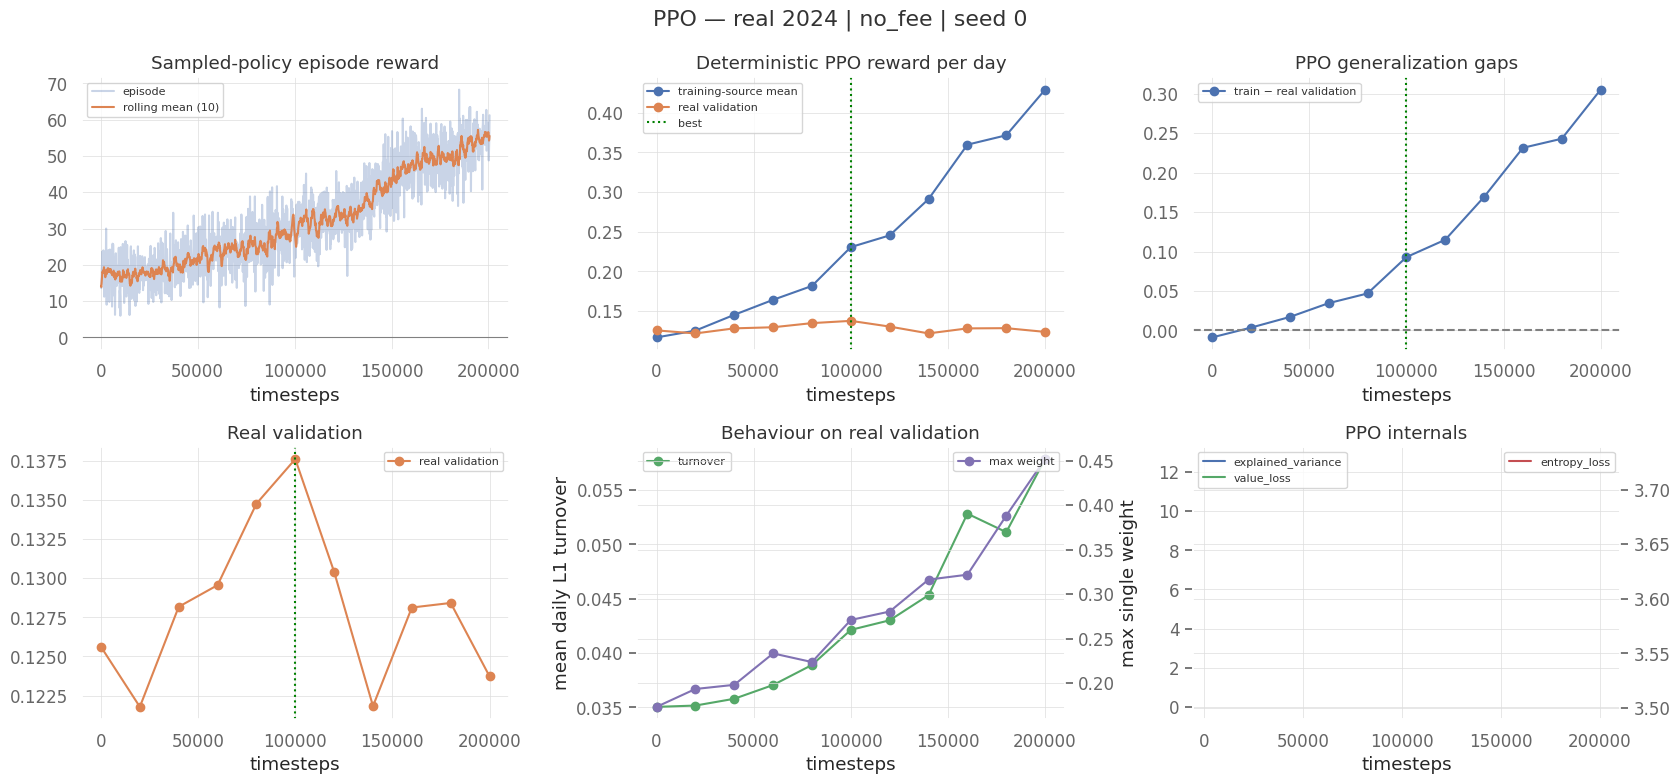

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/real_trained_e3add3a6__no_fee__seed_0__c5525d13e16e/learning_curves.png


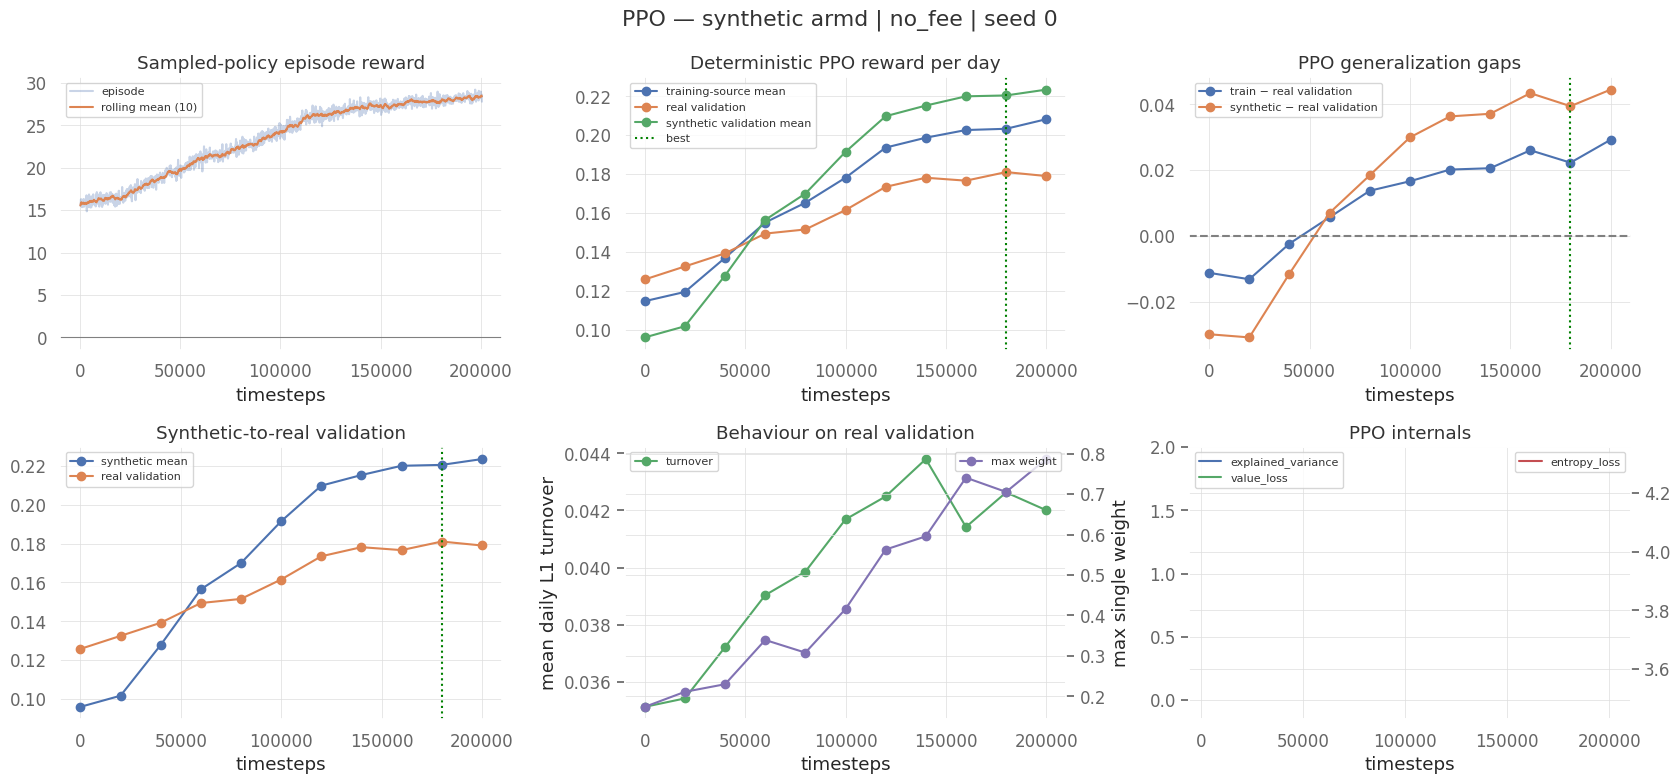

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_armd_30e33431__no_fee__seed_0__afc88cc489a8/learning_curves.png


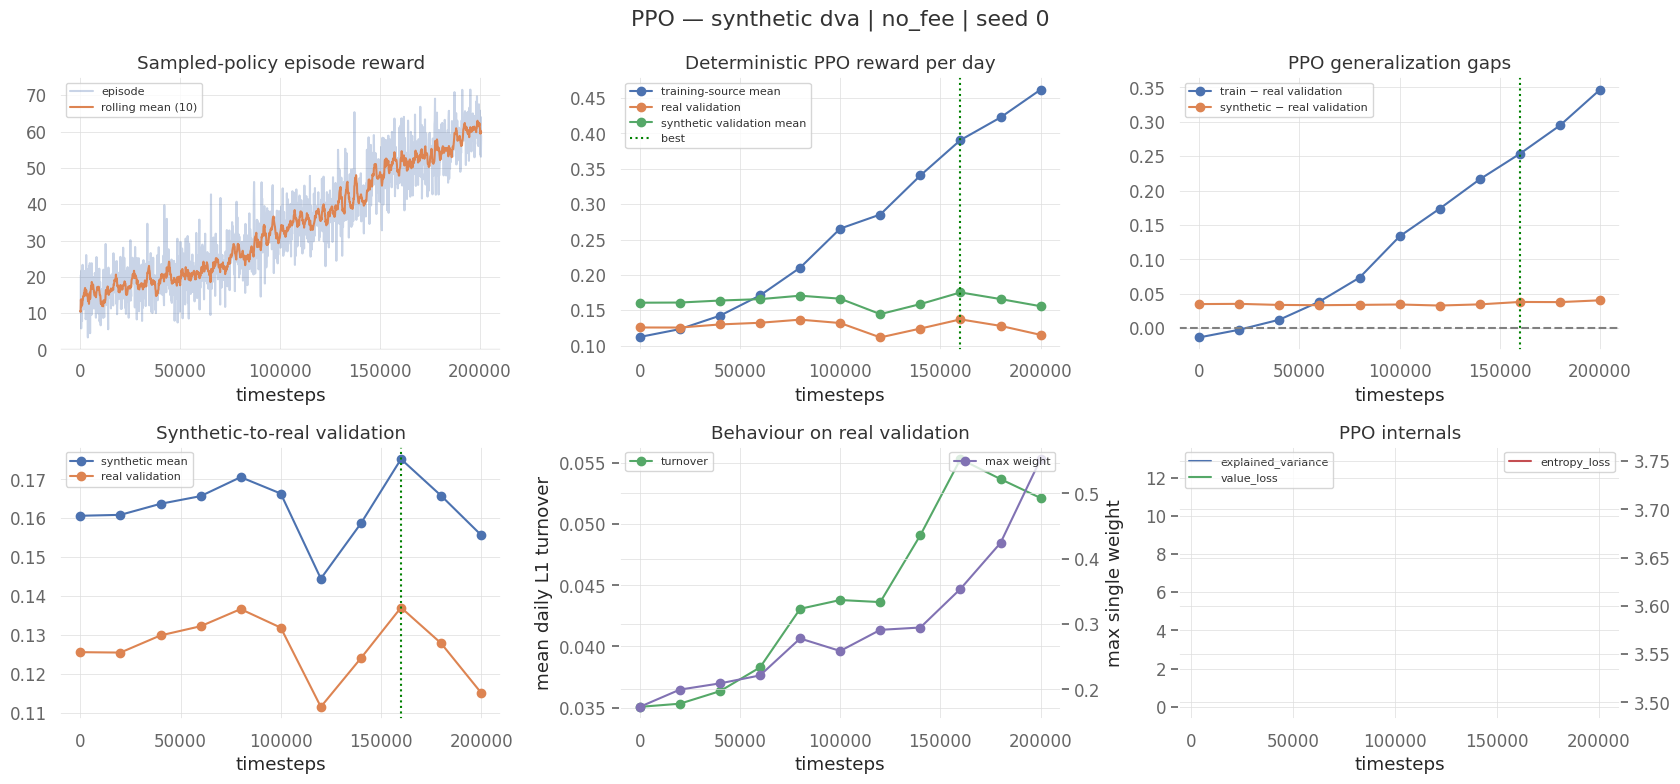

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_c3a3276b__no_fee__seed_0__78d116f787be/learning_curves.png


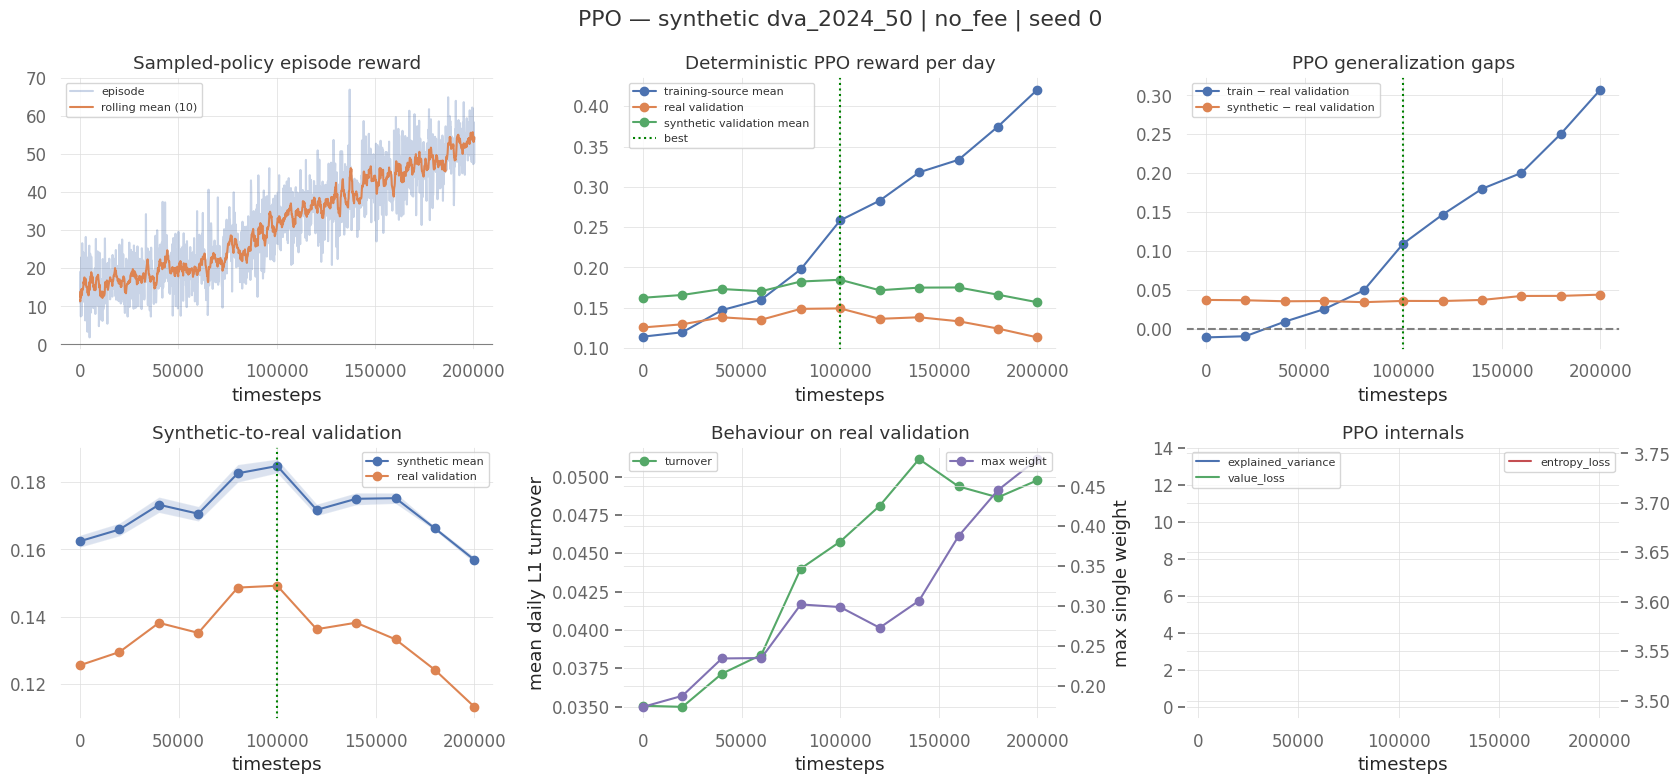

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_2024_50_ca9cca6a__no_fee__seed_0__710dfdce5983/learning_curves.png


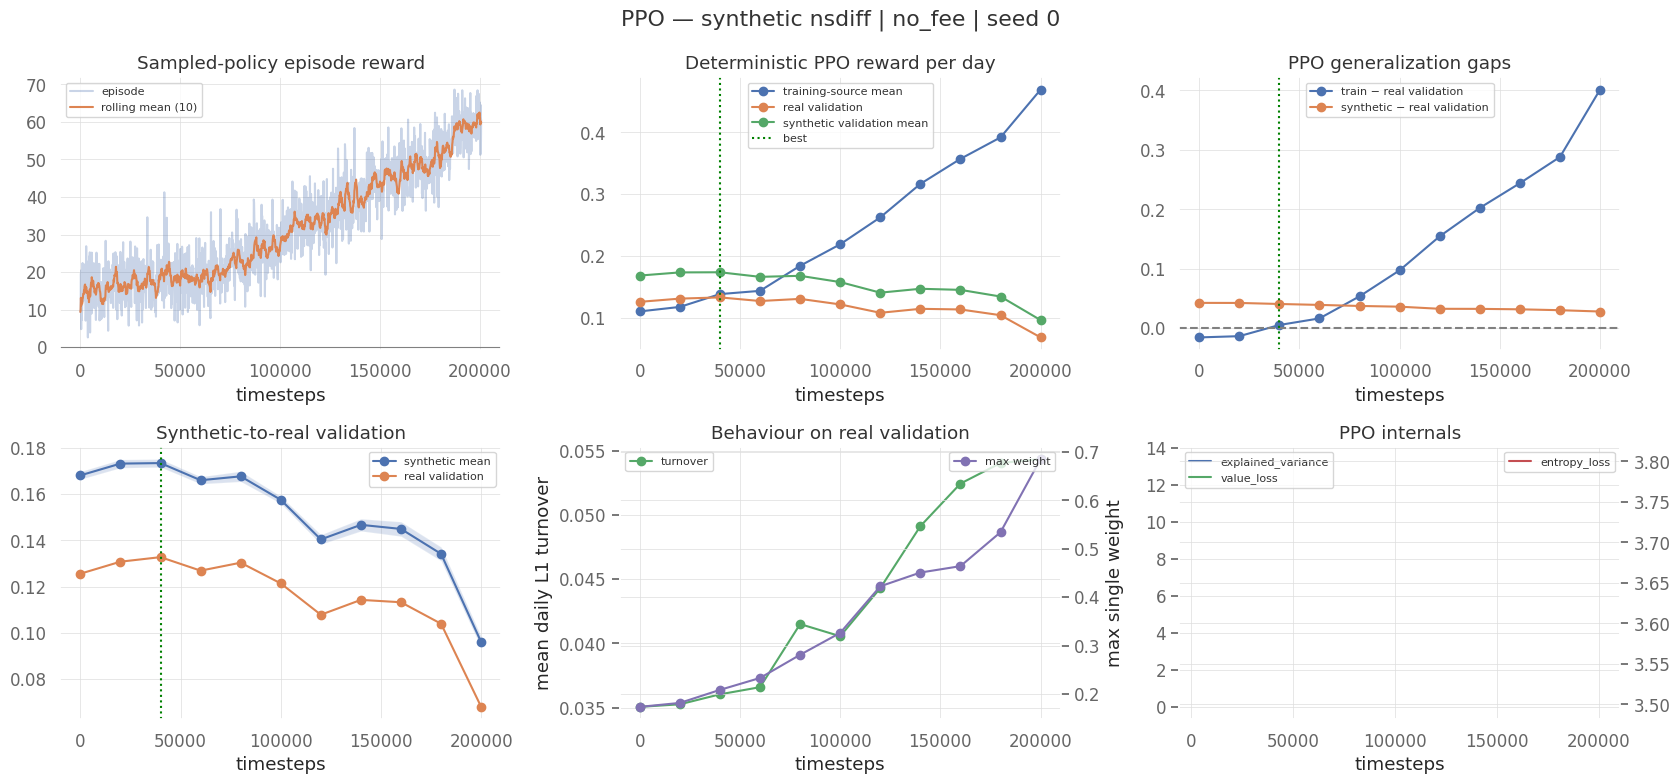

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_nsdiff_210a1b8a__no_fee__seed_0__9fe9f5d5dea3/learning_curves.png


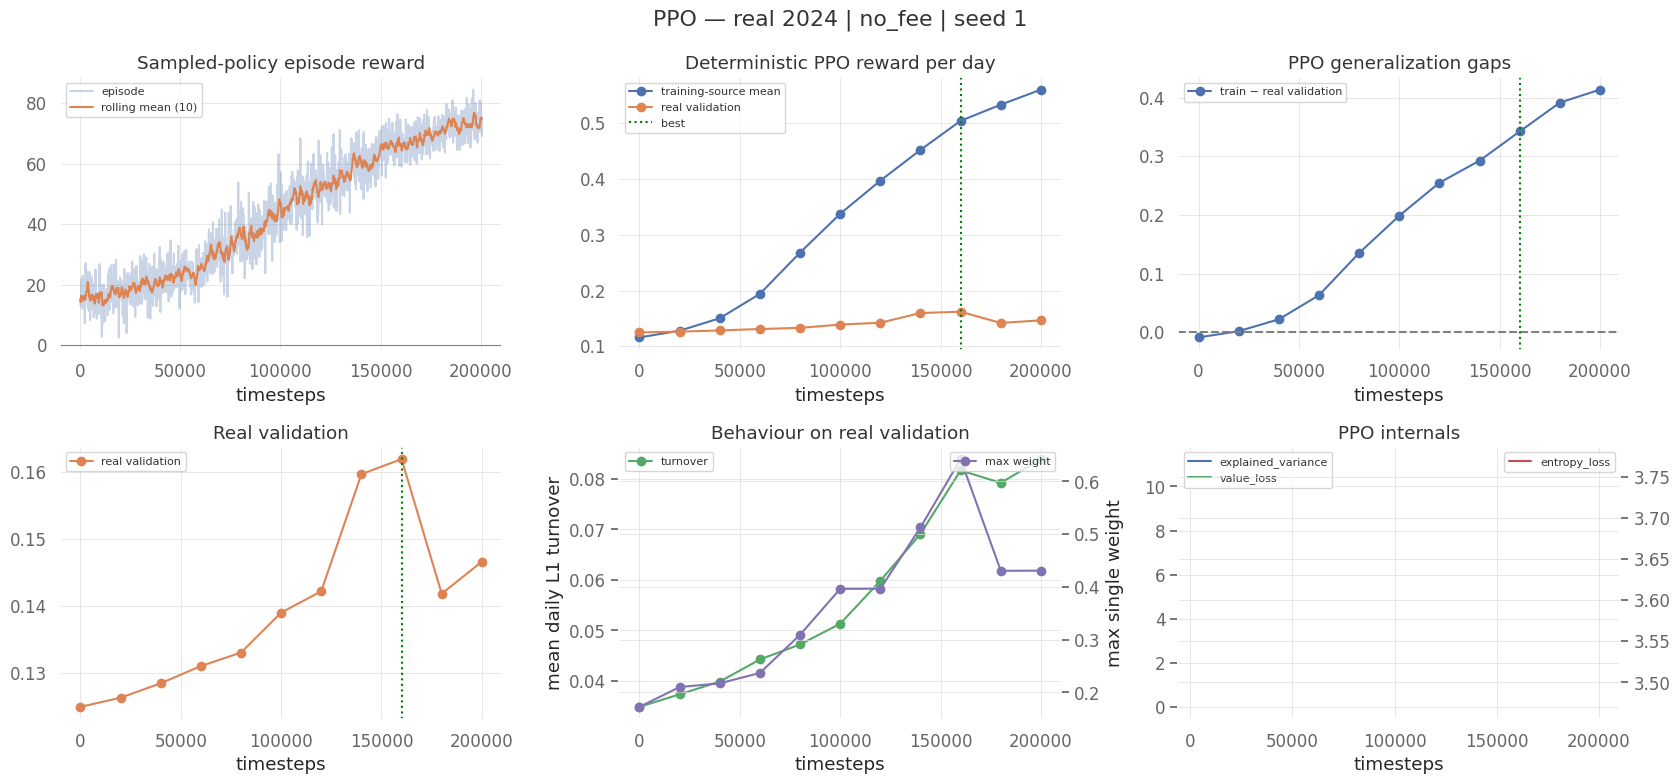

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/real_trained_e3add3a6__no_fee__seed_1__c7682581dbfe/learning_curves.png


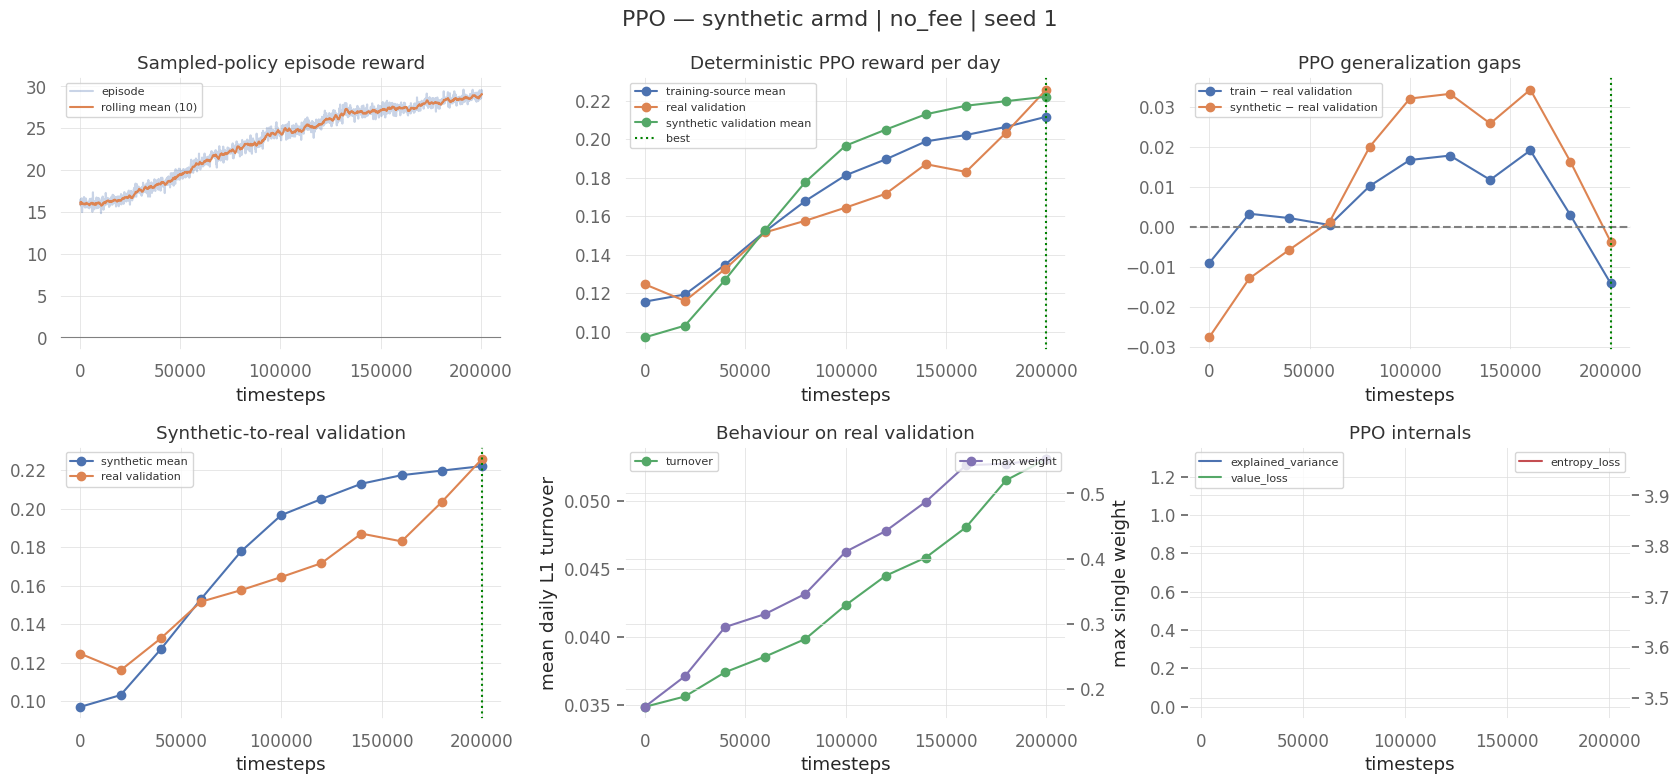

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_armd_30e33431__no_fee__seed_1__b65431352598/learning_curves.png


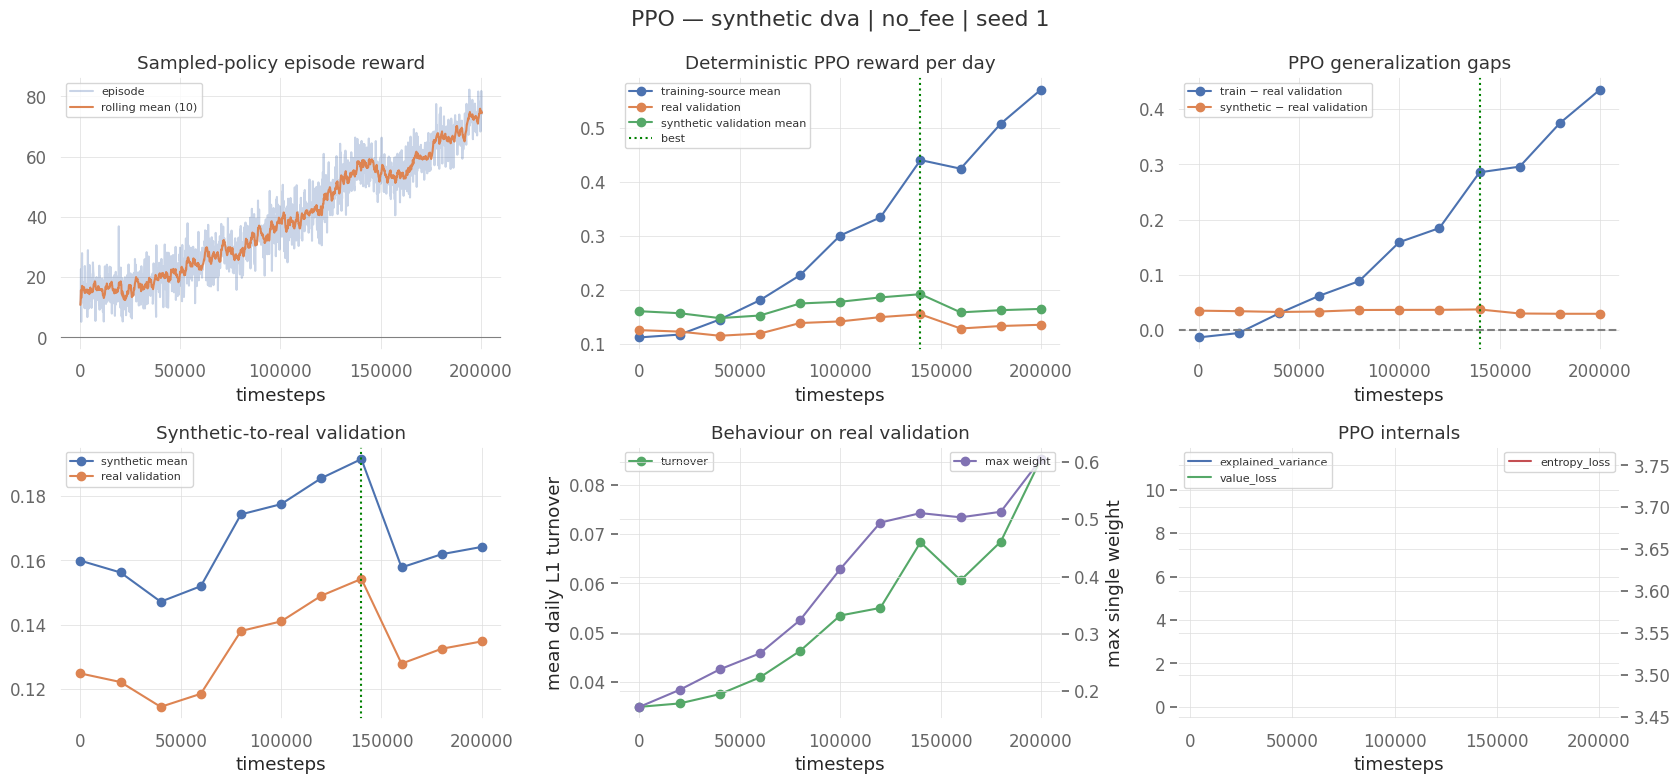

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_c3a3276b__no_fee__seed_1__ea5fafc1d4bb/learning_curves.png


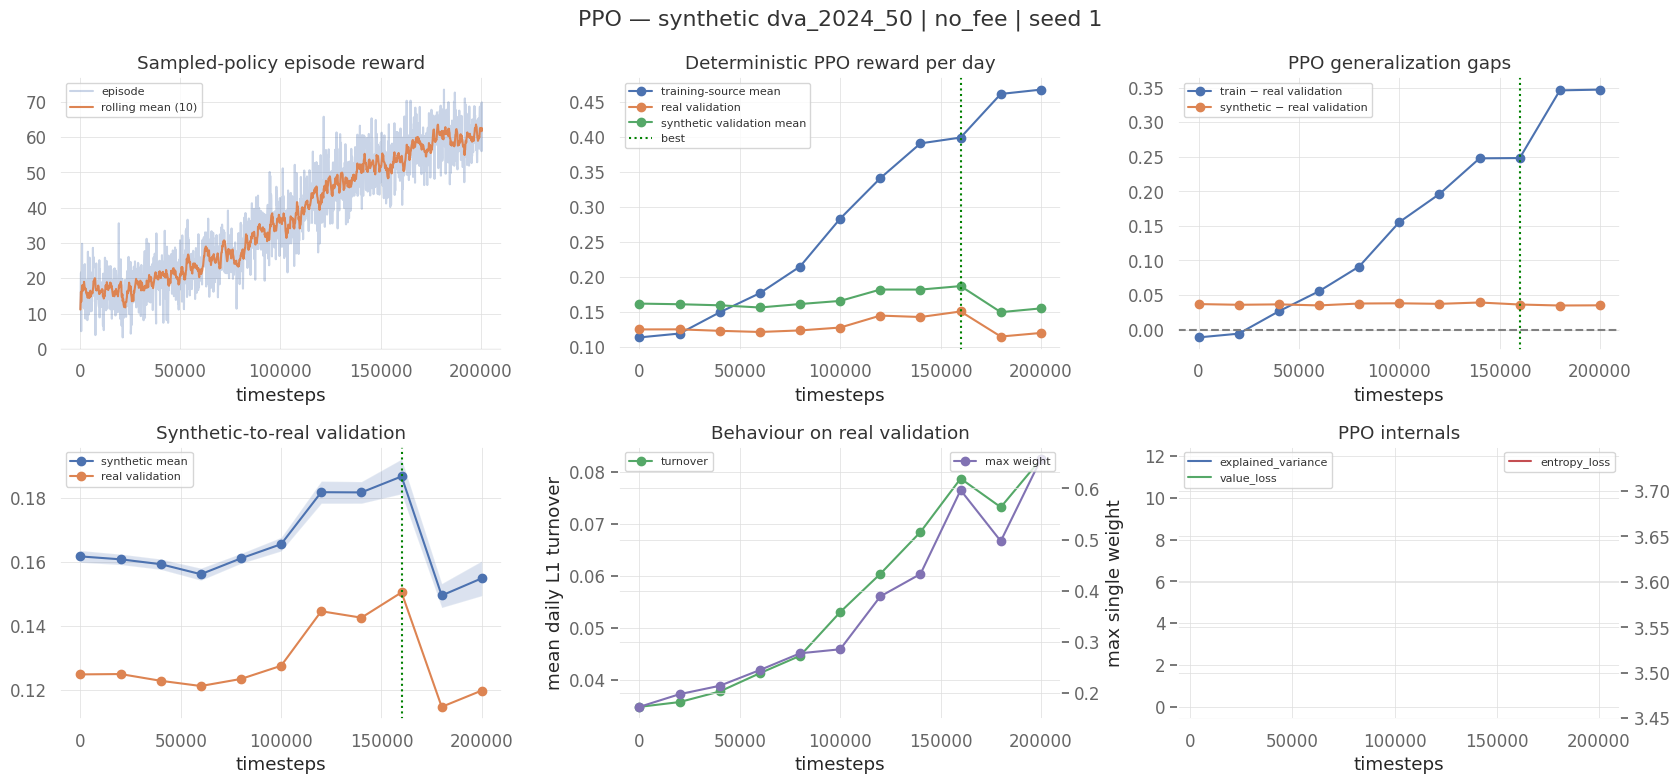

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_2024_50_ca9cca6a__no_fee__seed_1__b851ce7aeb7c/learning_curves.png


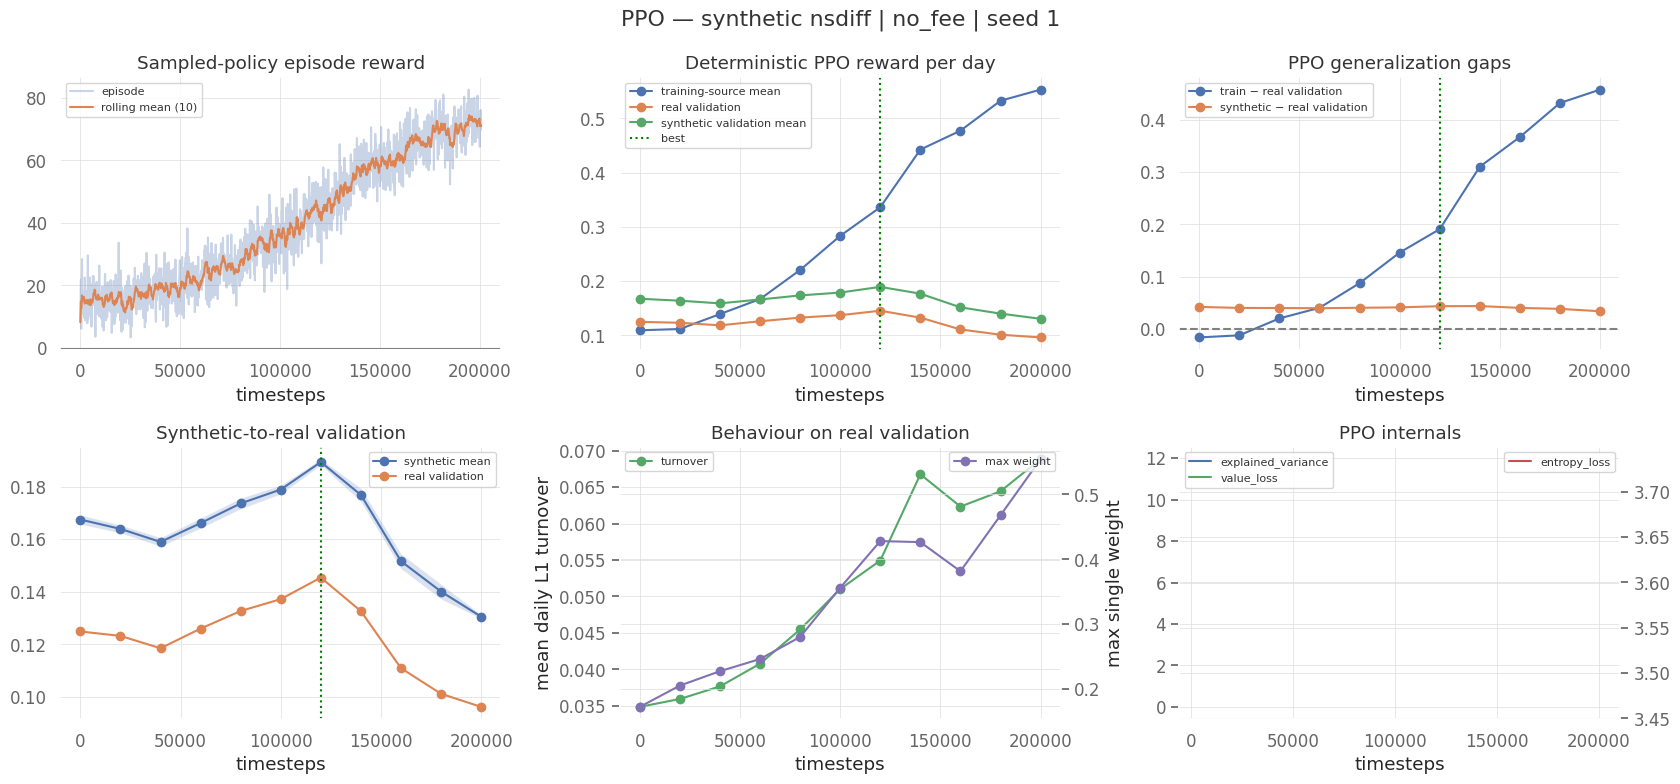

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_nsdiff_210a1b8a__no_fee__seed_1__d6432166a1ca/learning_curves.png


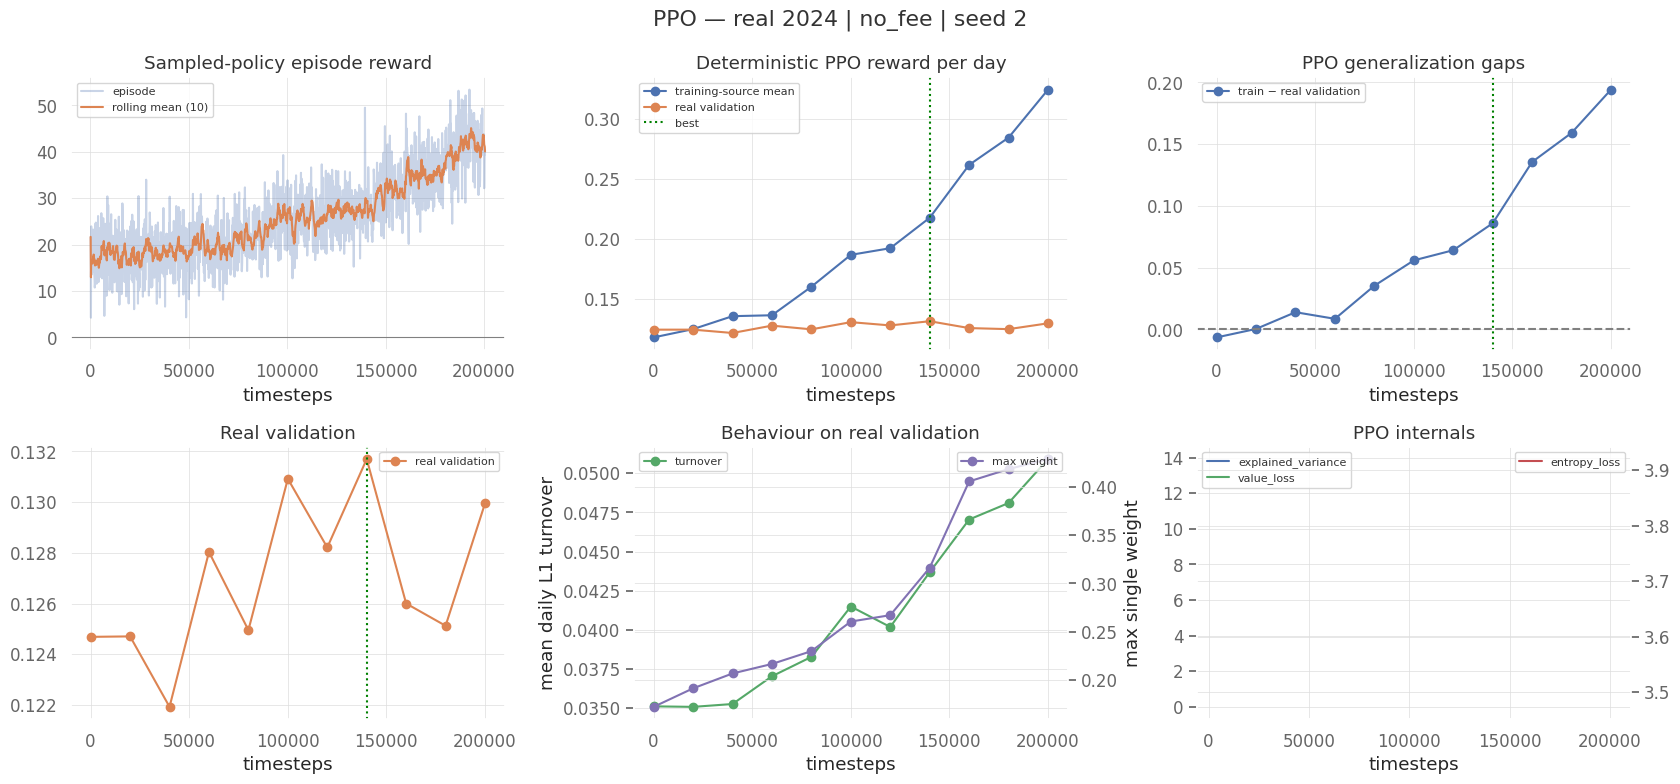

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/real_trained_e3add3a6__no_fee__seed_2__eaa7b2cac0a7/learning_curves.png


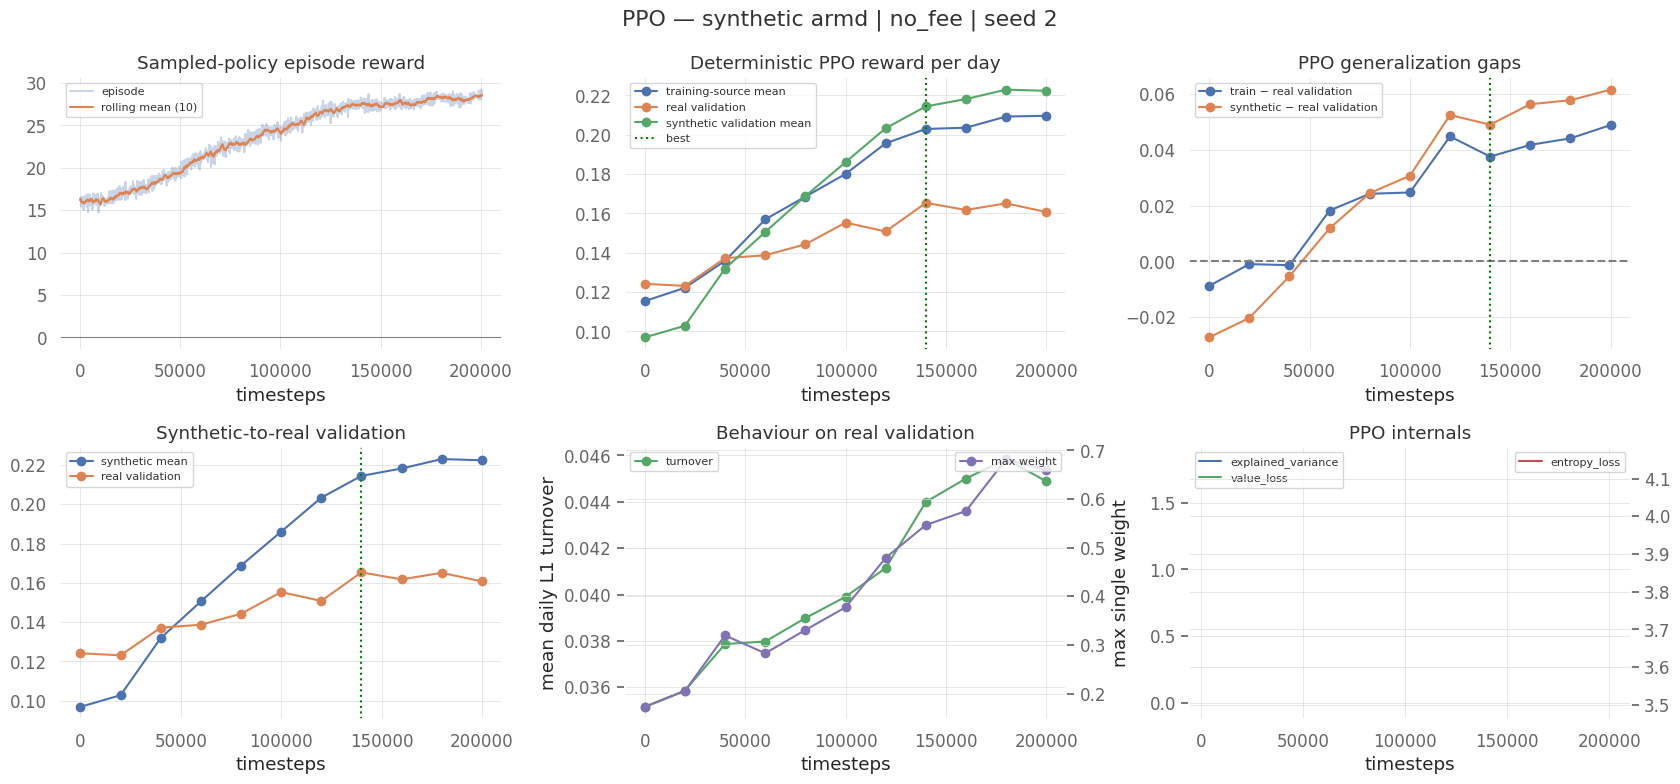

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_armd_30e33431__no_fee__seed_2__a4cf2c01e78b/learning_curves.png


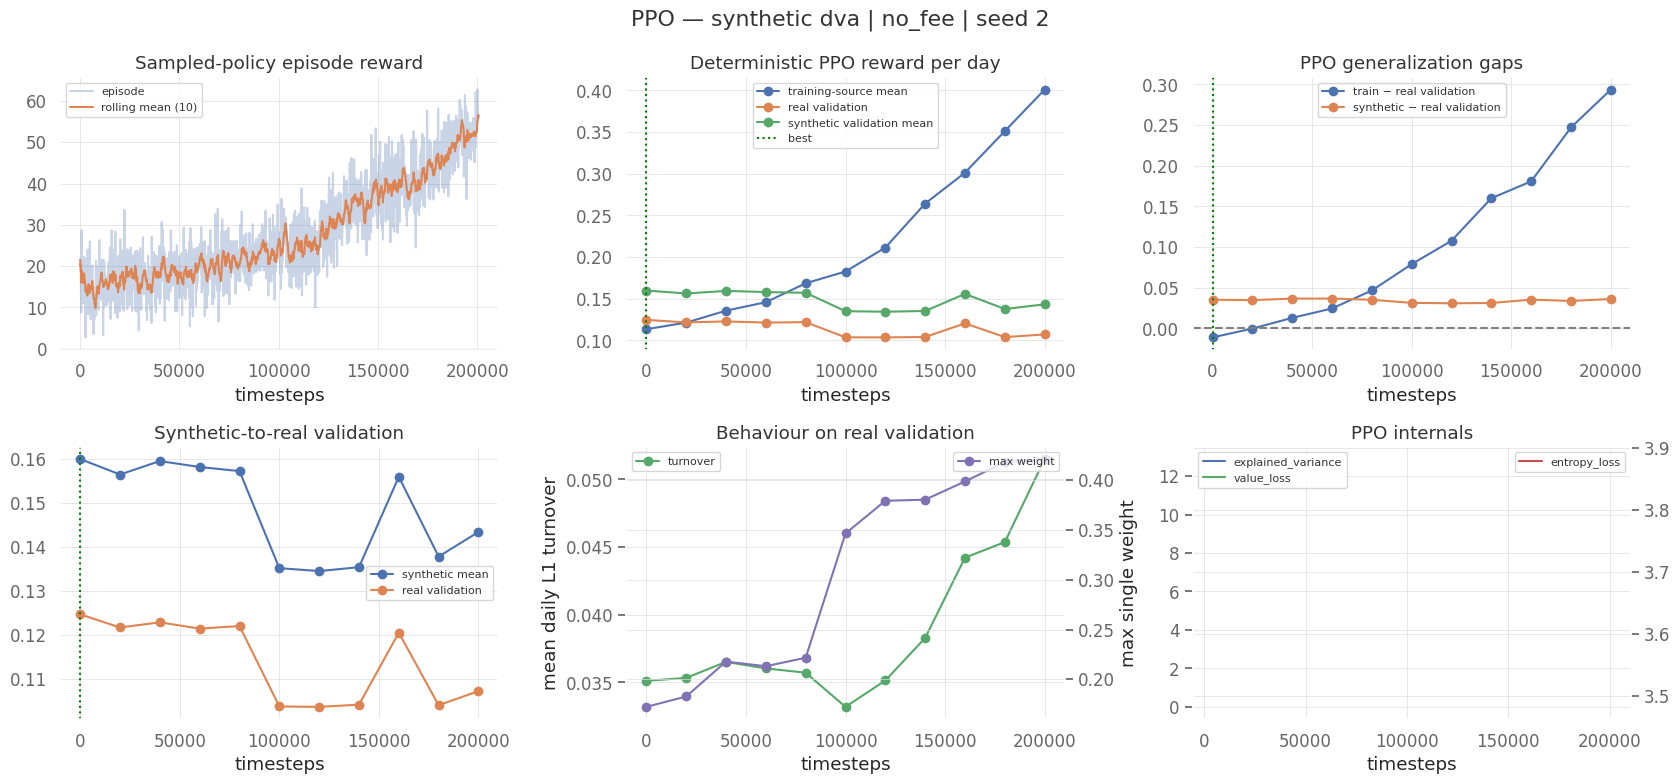

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_c3a3276b__no_fee__seed_2__a04a5d3b7795/learning_curves.png


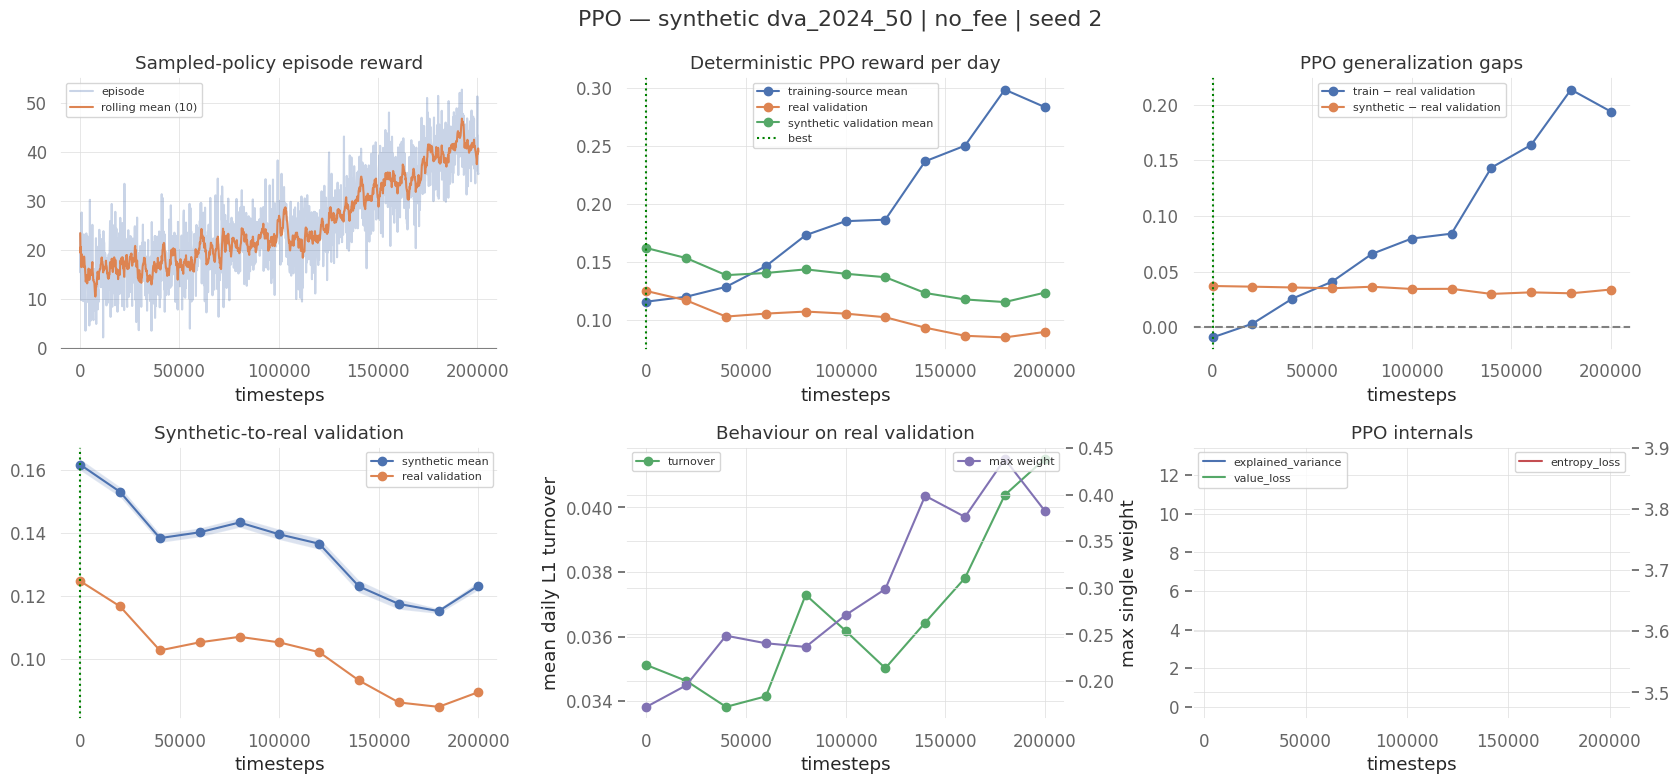

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_2024_50_ca9cca6a__no_fee__seed_2__444b51ed7e22/learning_curves.png


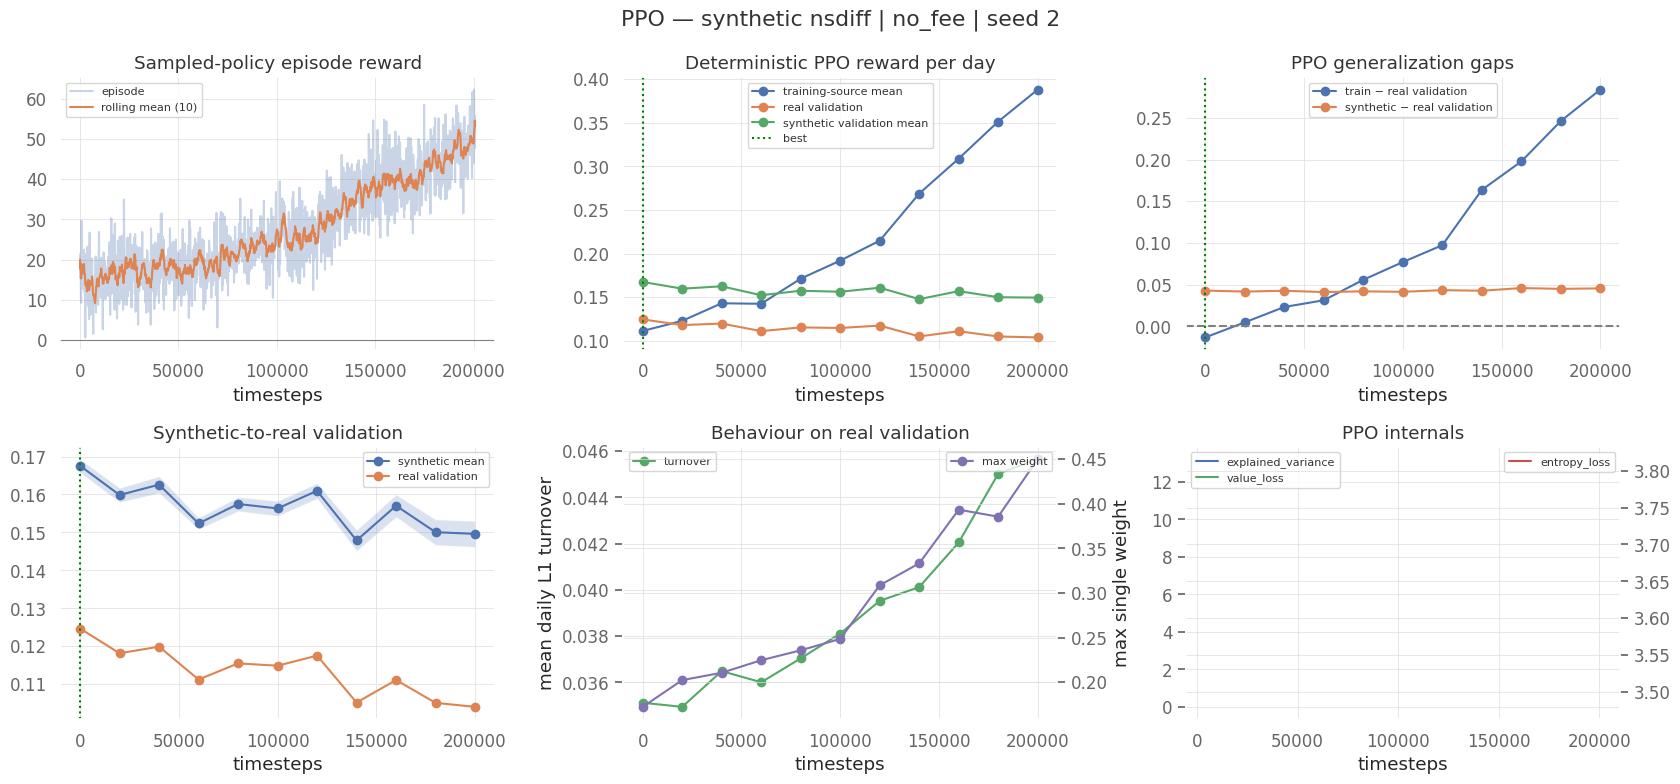

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_nsdiff_210a1b8a__no_fee__seed_2__d412f0fbae2e/learning_curves.png


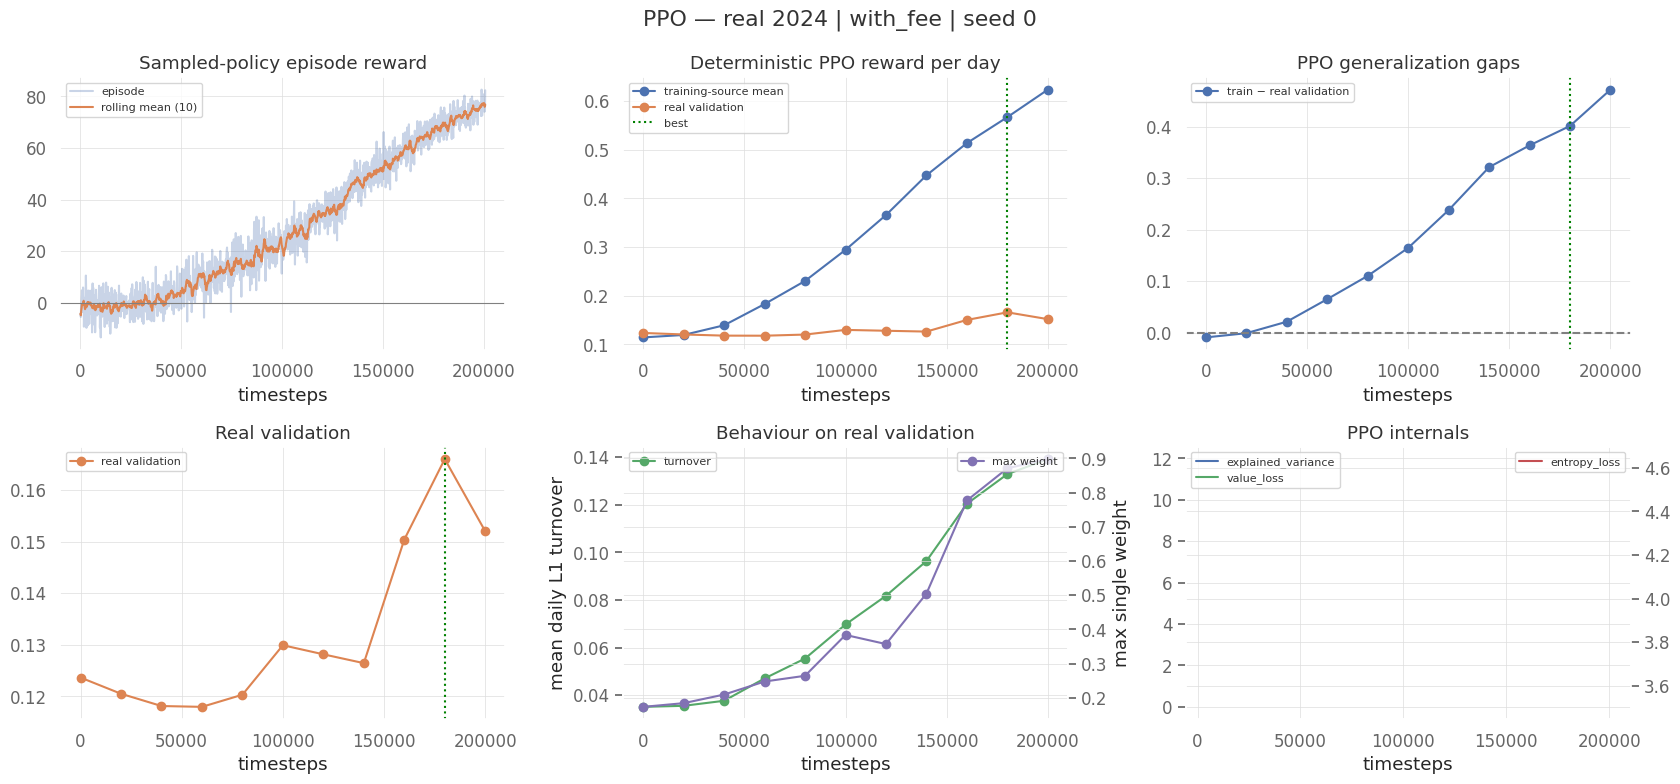

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/real_trained_e3add3a6__with_fee__seed_0__cc0f86d5196a/learning_curves.png


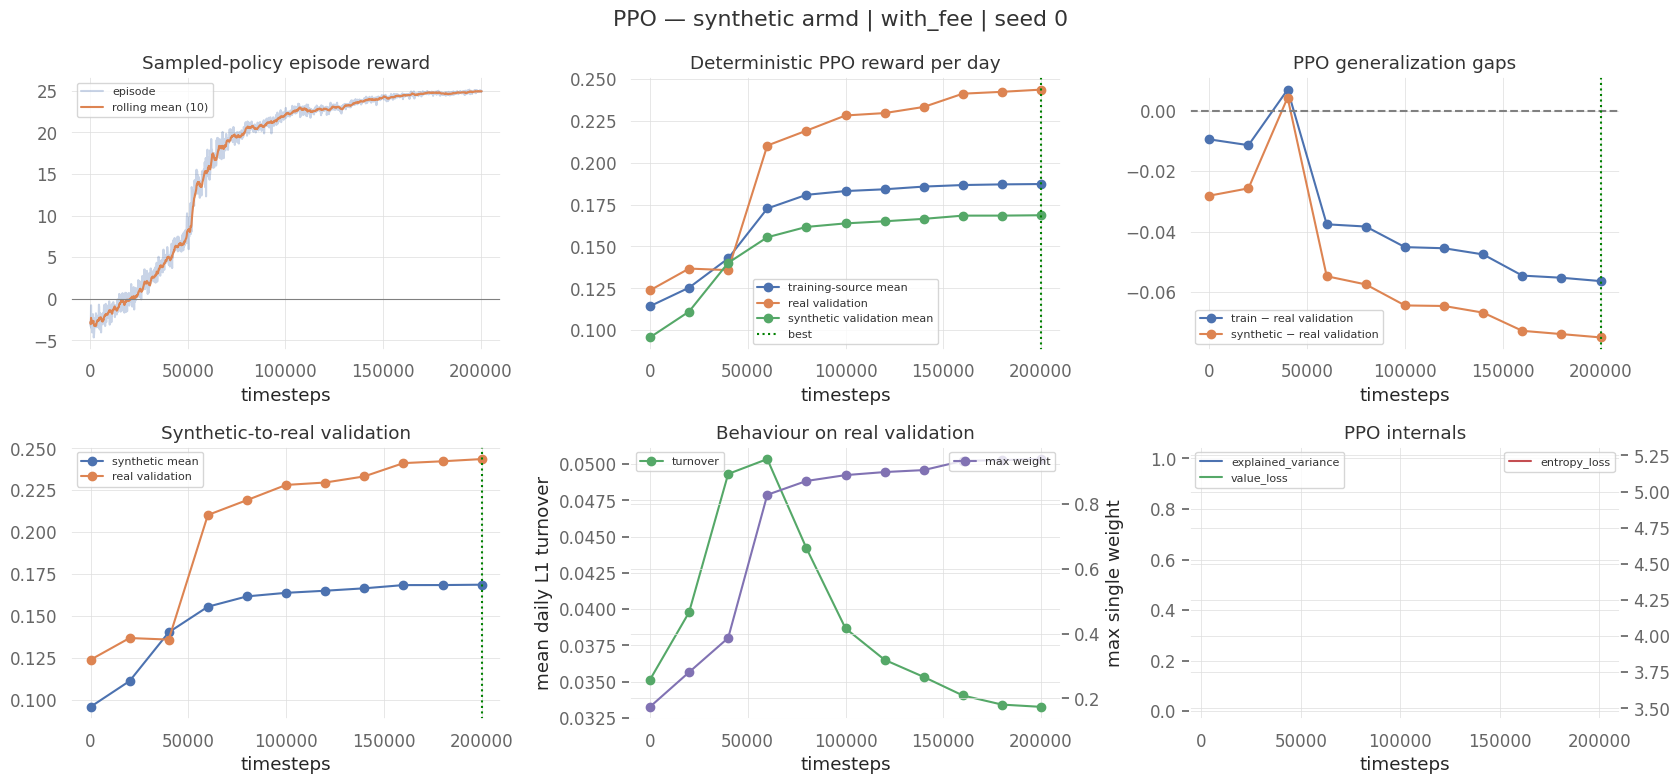

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_armd_30e33431__with_fee__seed_0__bfda73f16b40/learning_curves.png


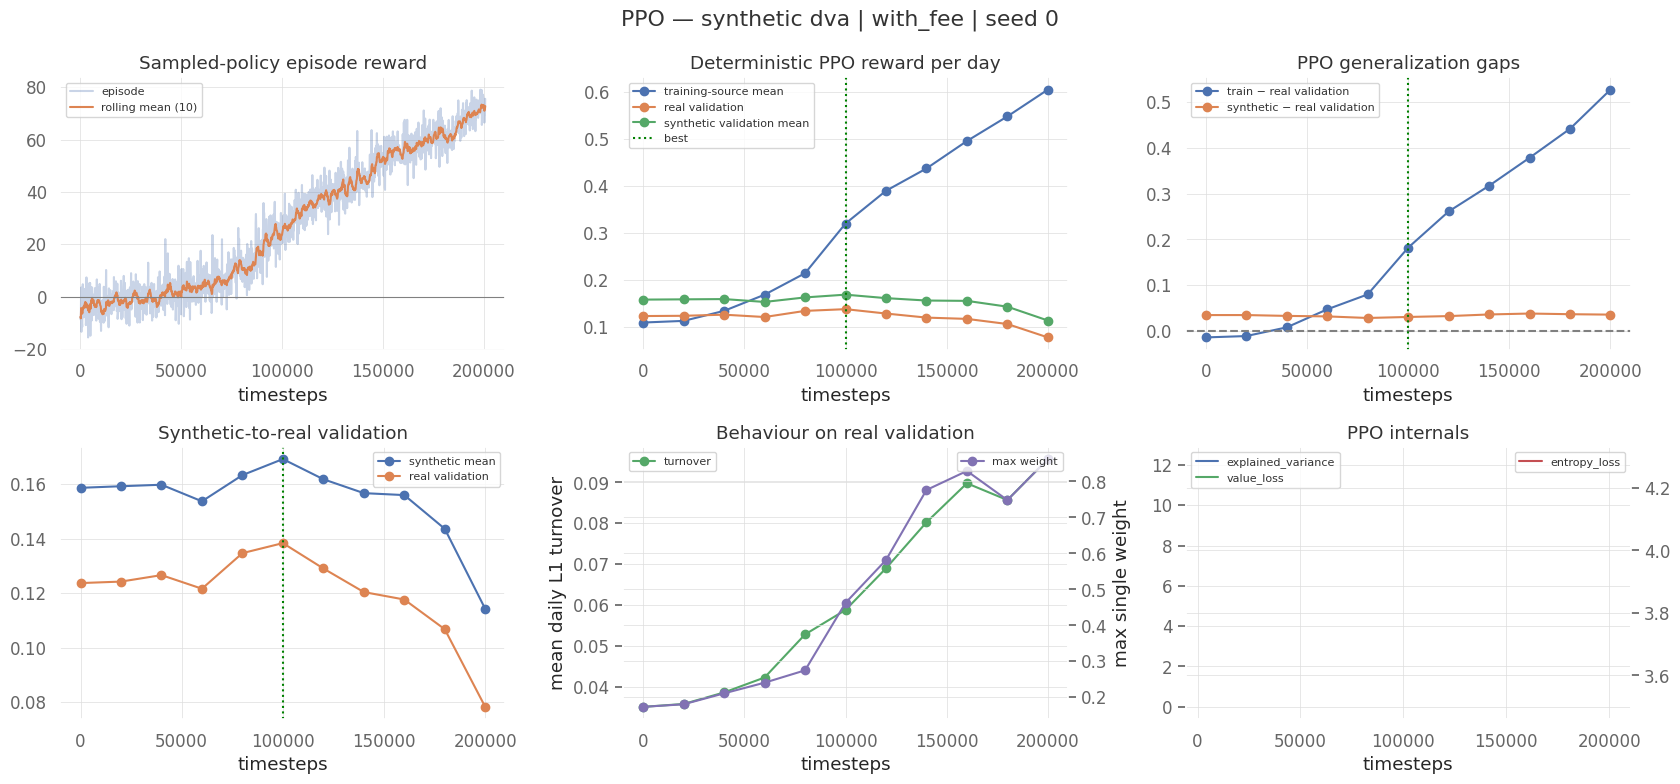

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_c3a3276b__with_fee__seed_0__41c3f00f07f5/learning_curves.png


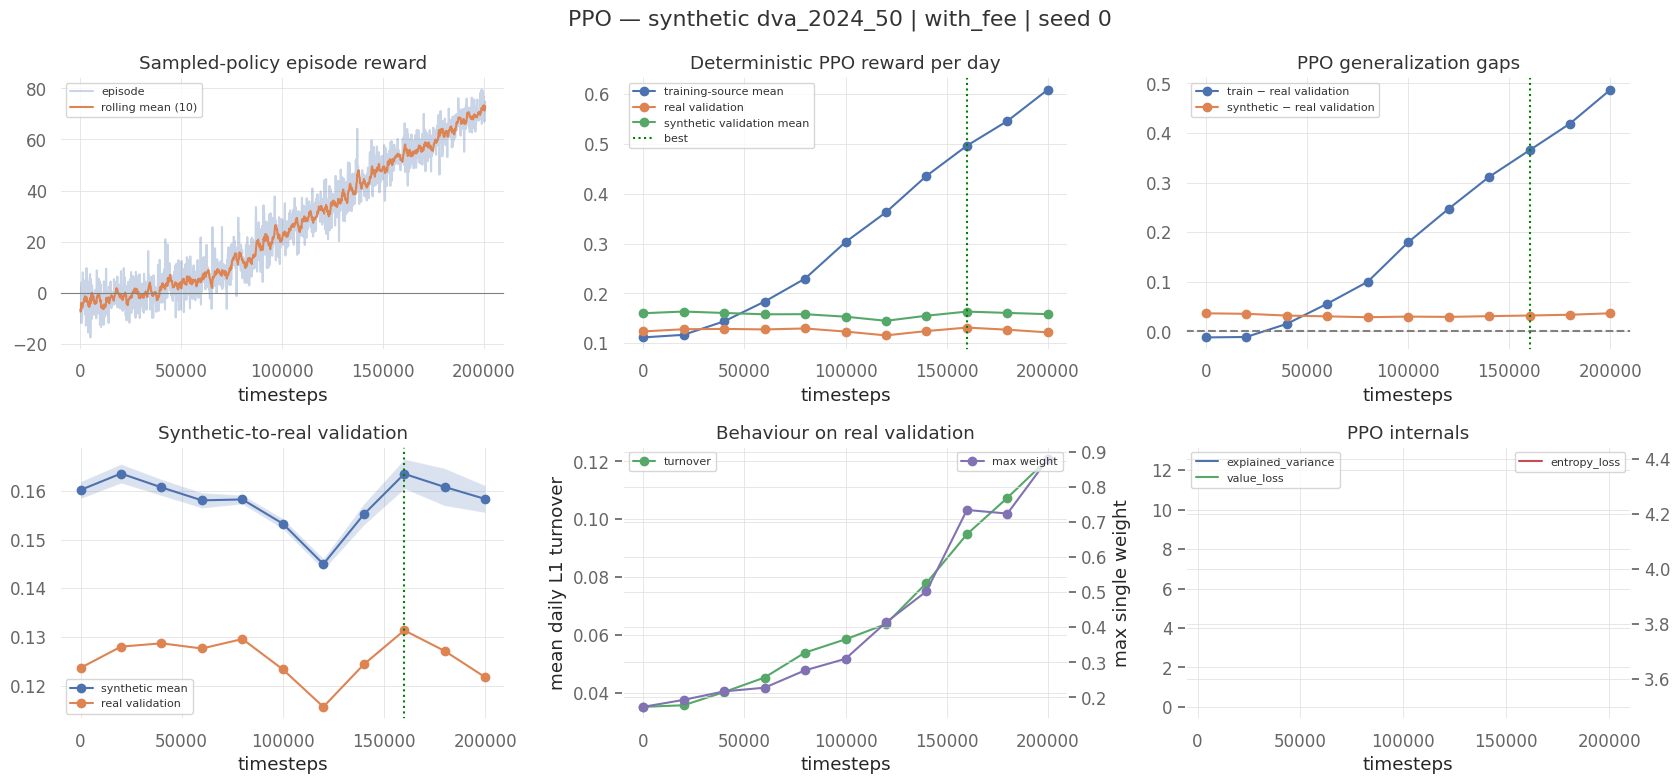

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_2024_50_ca9cca6a__with_fee__seed_0__4d66ba35e50d/learning_curves.png


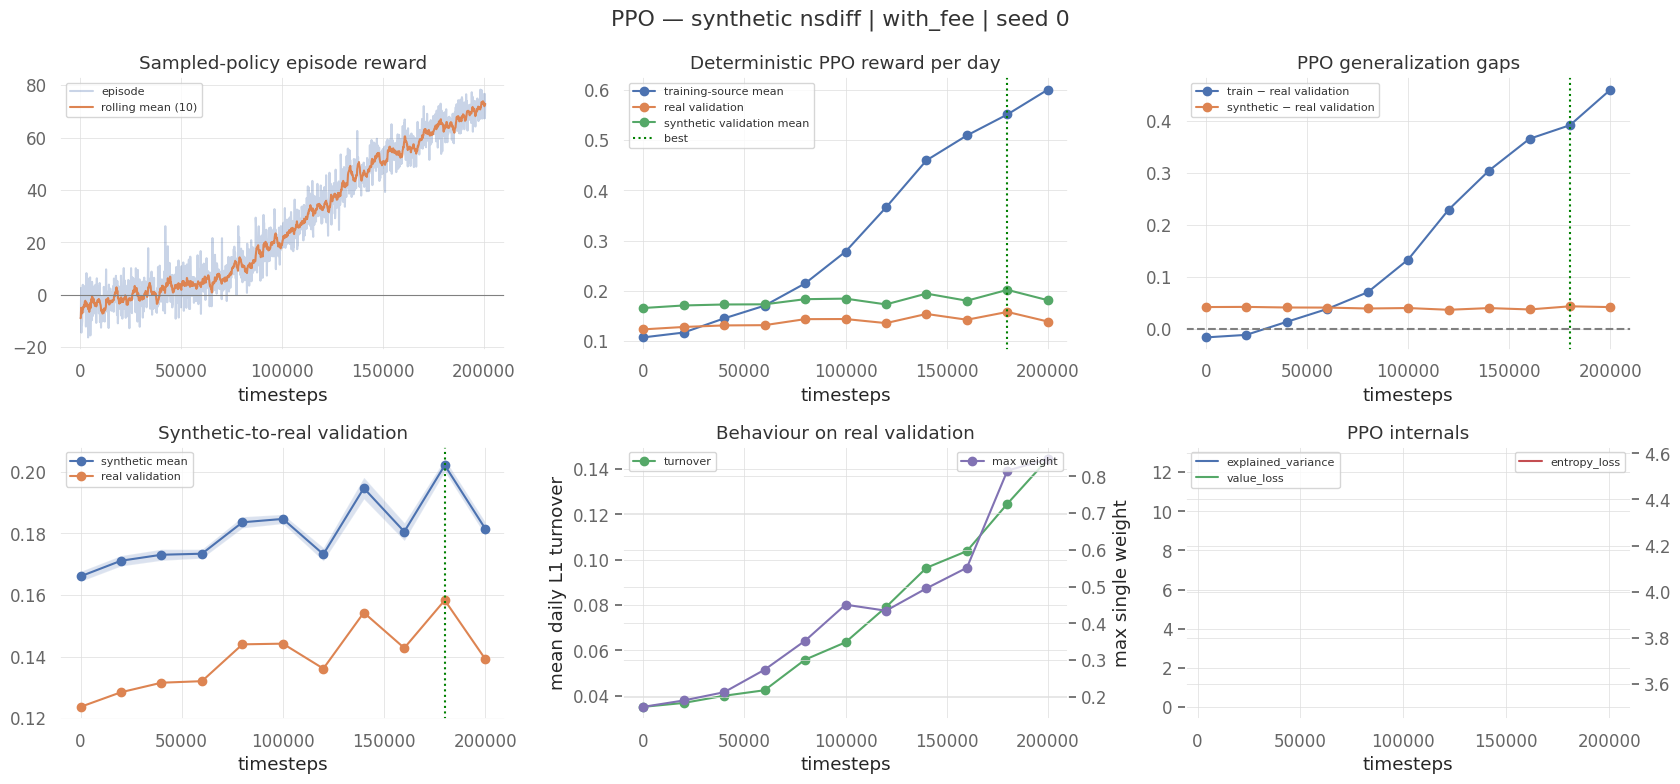

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_nsdiff_210a1b8a__with_fee__seed_0__877c2cd7a2b9/learning_curves.png


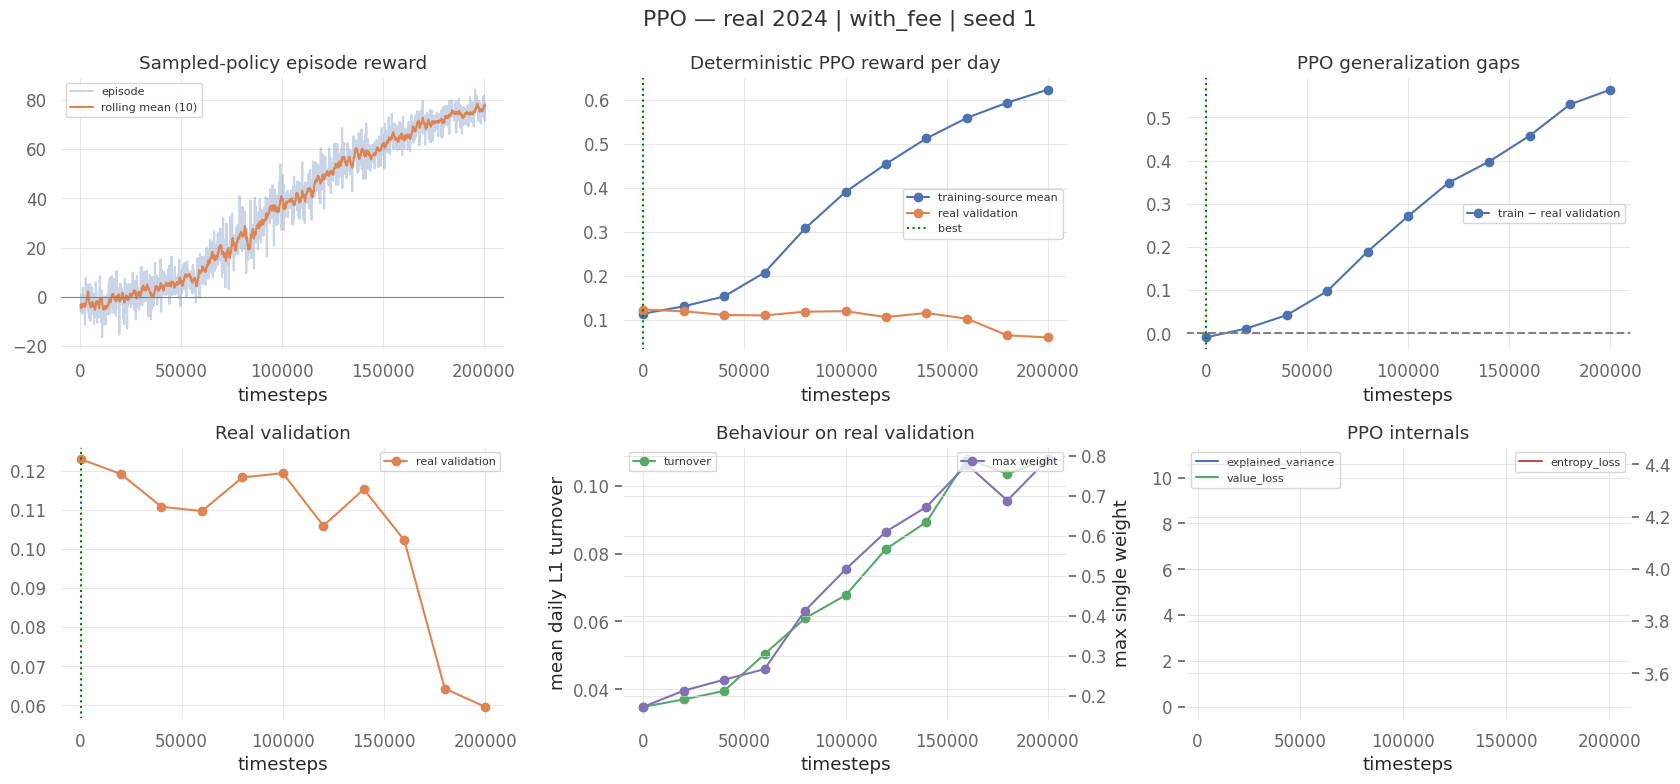

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/real_trained_e3add3a6__with_fee__seed_1__5fb005e89bc4/learning_curves.png


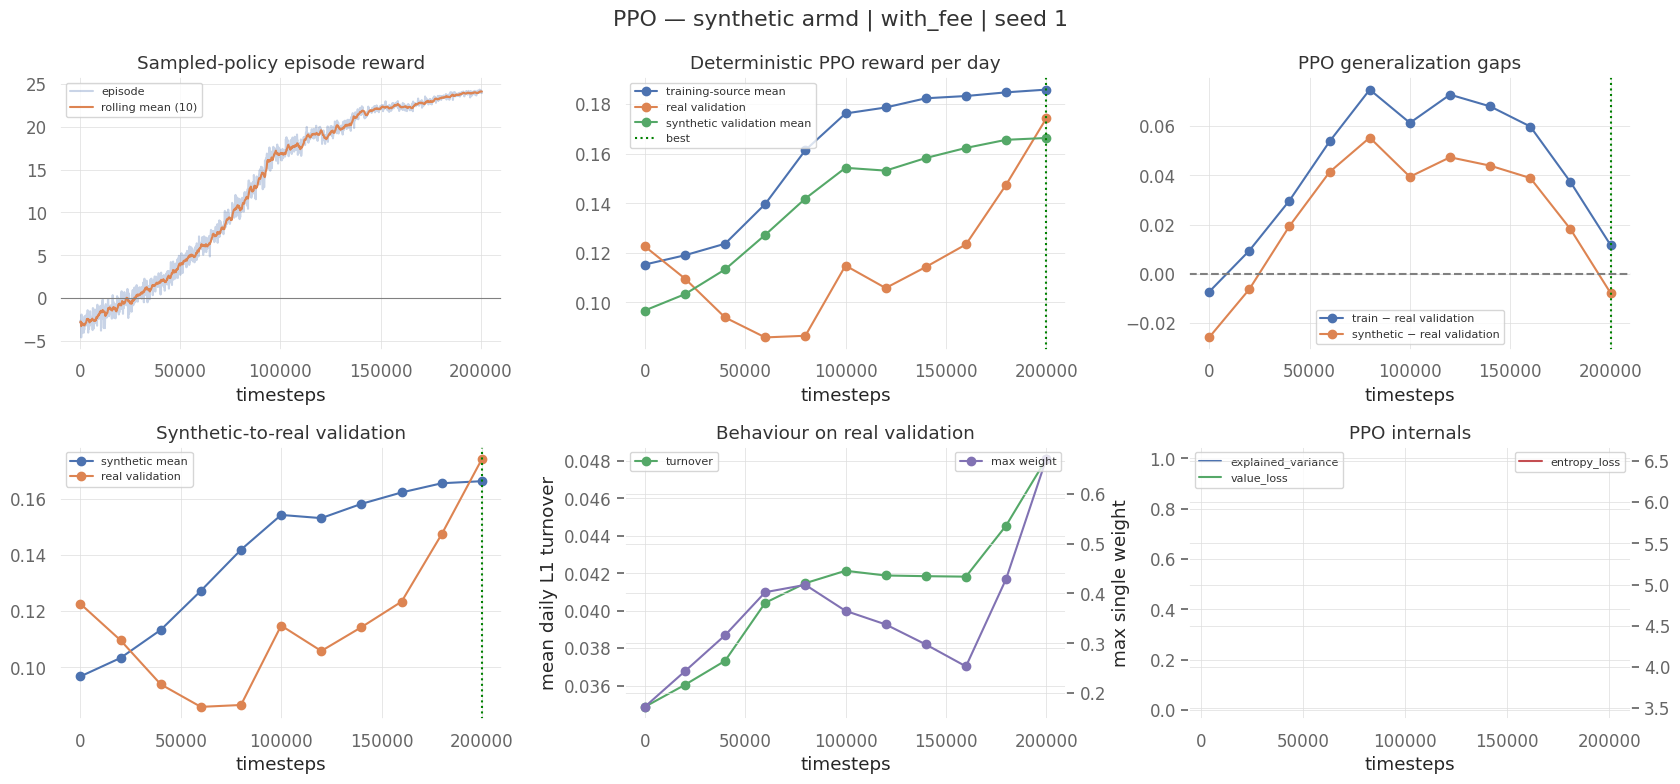

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_armd_30e33431__with_fee__seed_1__f43a787ba0c0/learning_curves.png


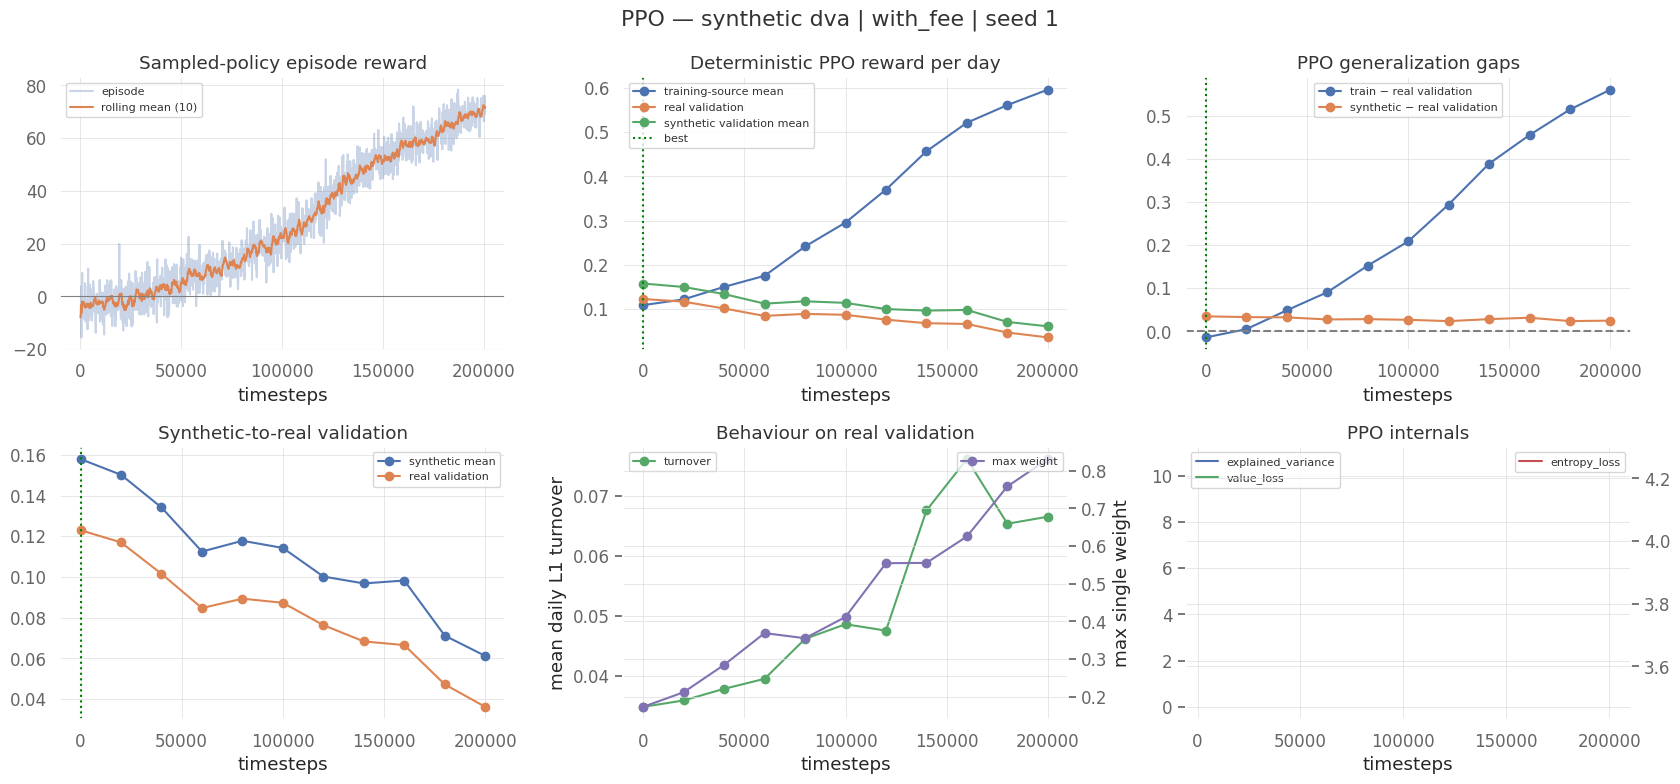

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_c3a3276b__with_fee__seed_1__4b8cc84e6a2f/learning_curves.png


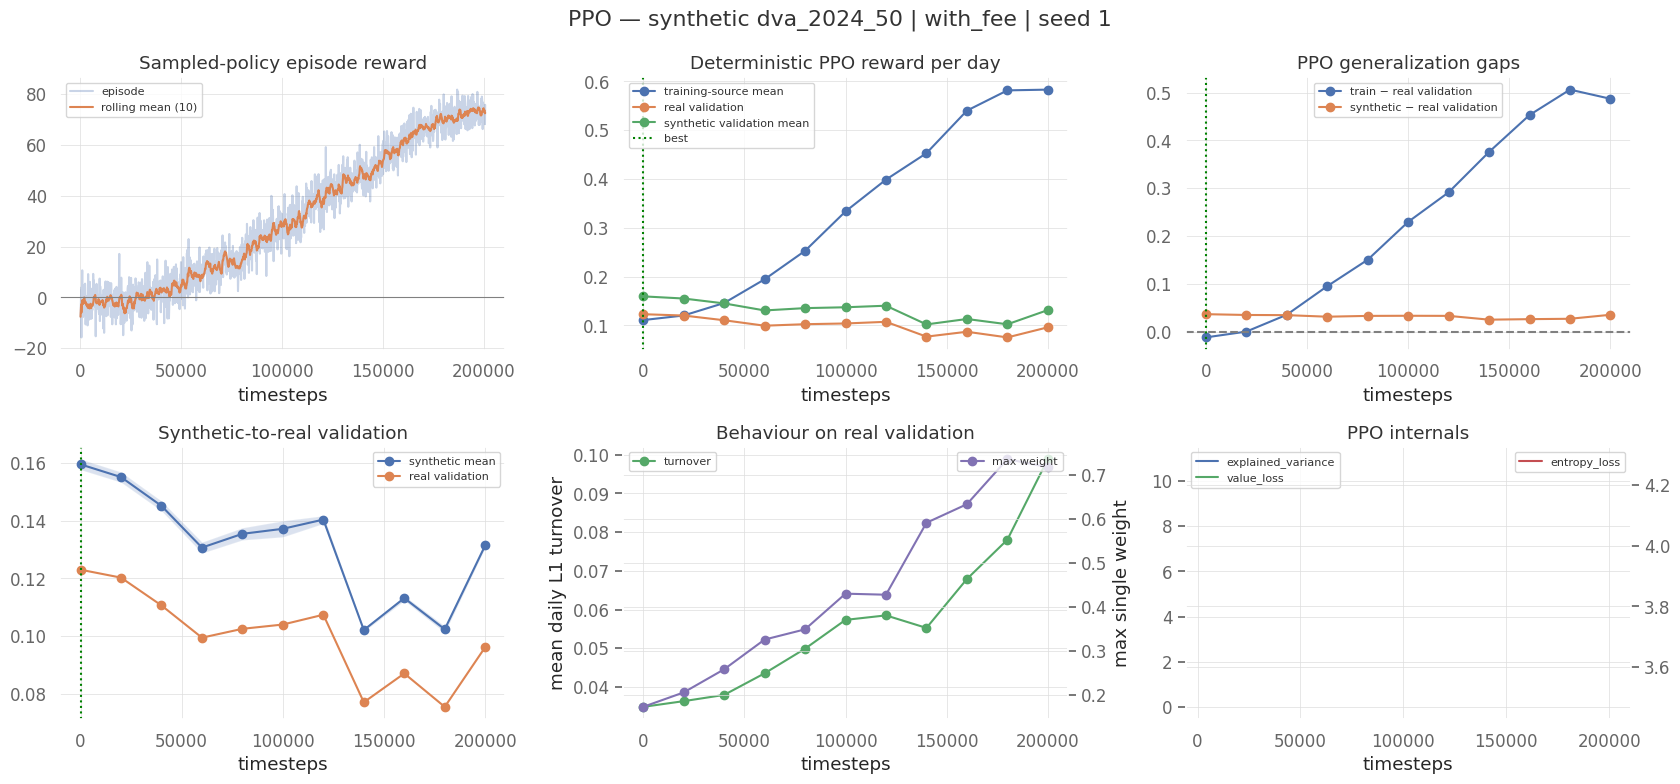

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_2024_50_ca9cca6a__with_fee__seed_1__0147c633a3af/learning_curves.png


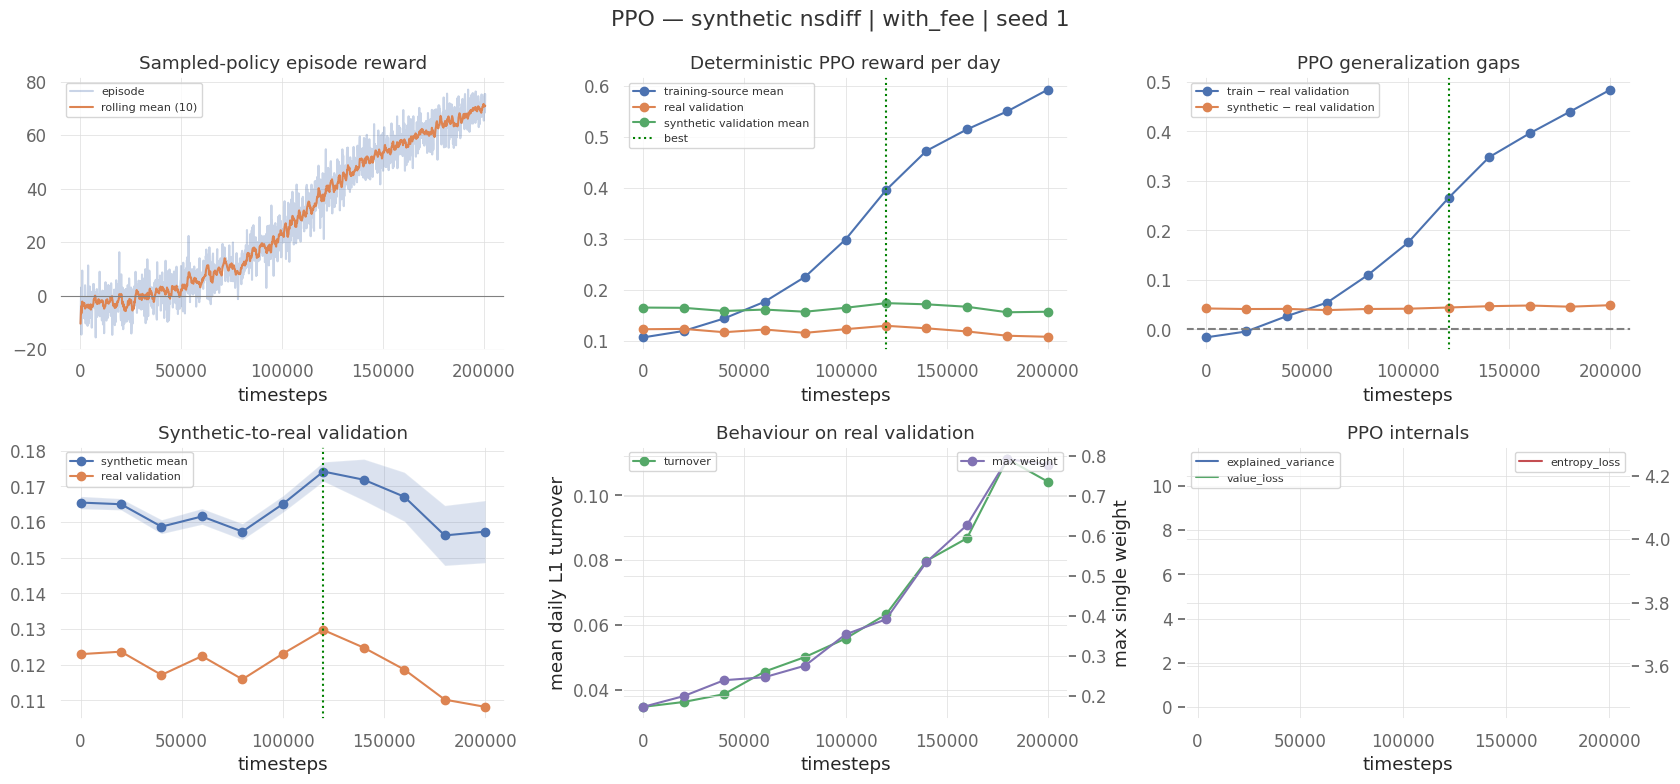

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_nsdiff_210a1b8a__with_fee__seed_1__53c6f355c532/learning_curves.png


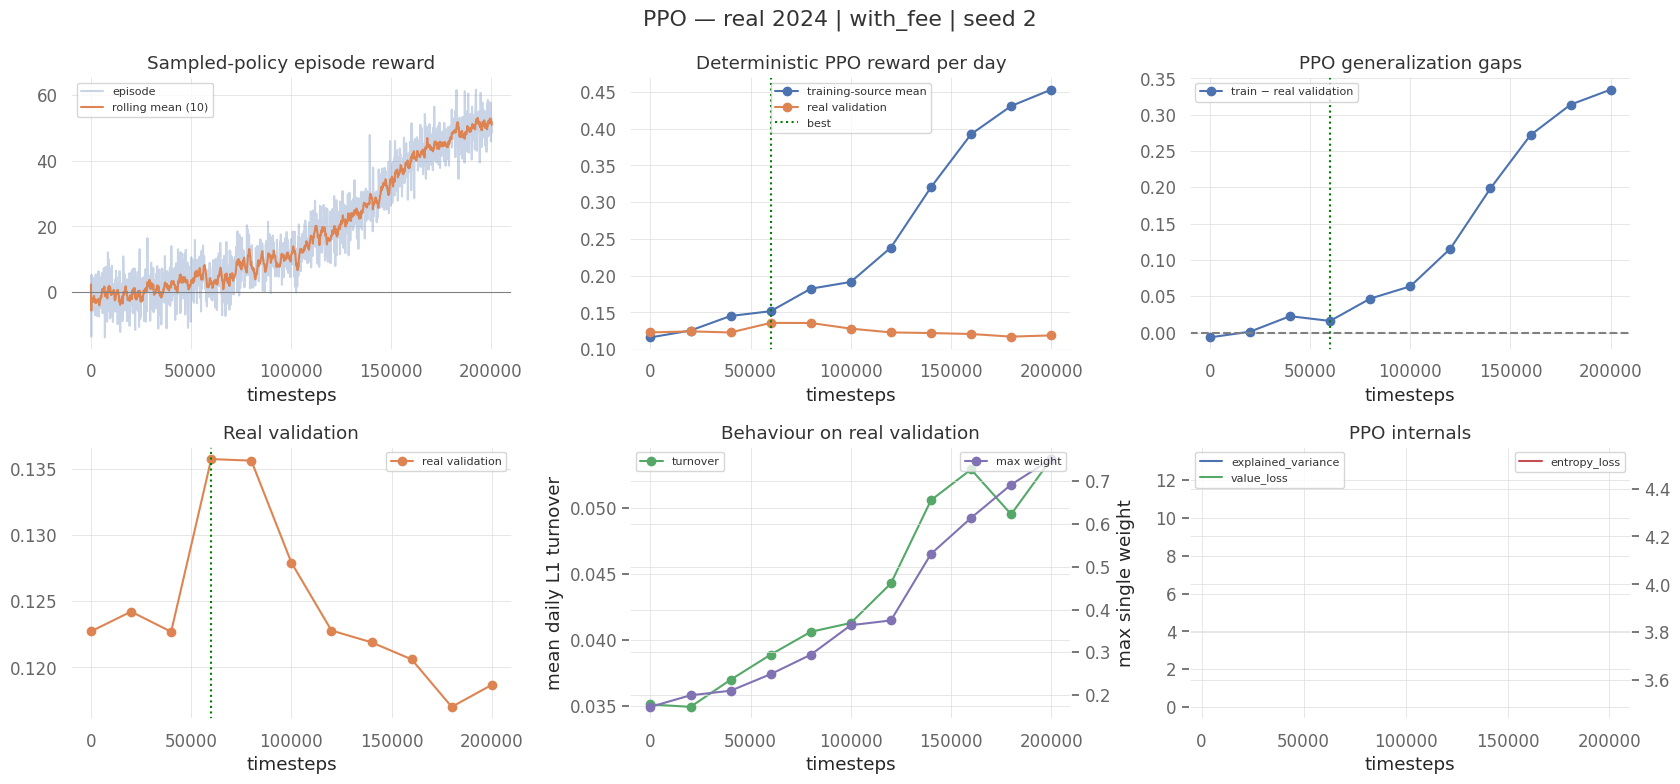

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/real_trained_e3add3a6__with_fee__seed_2__b1bf1bbecc25/learning_curves.png


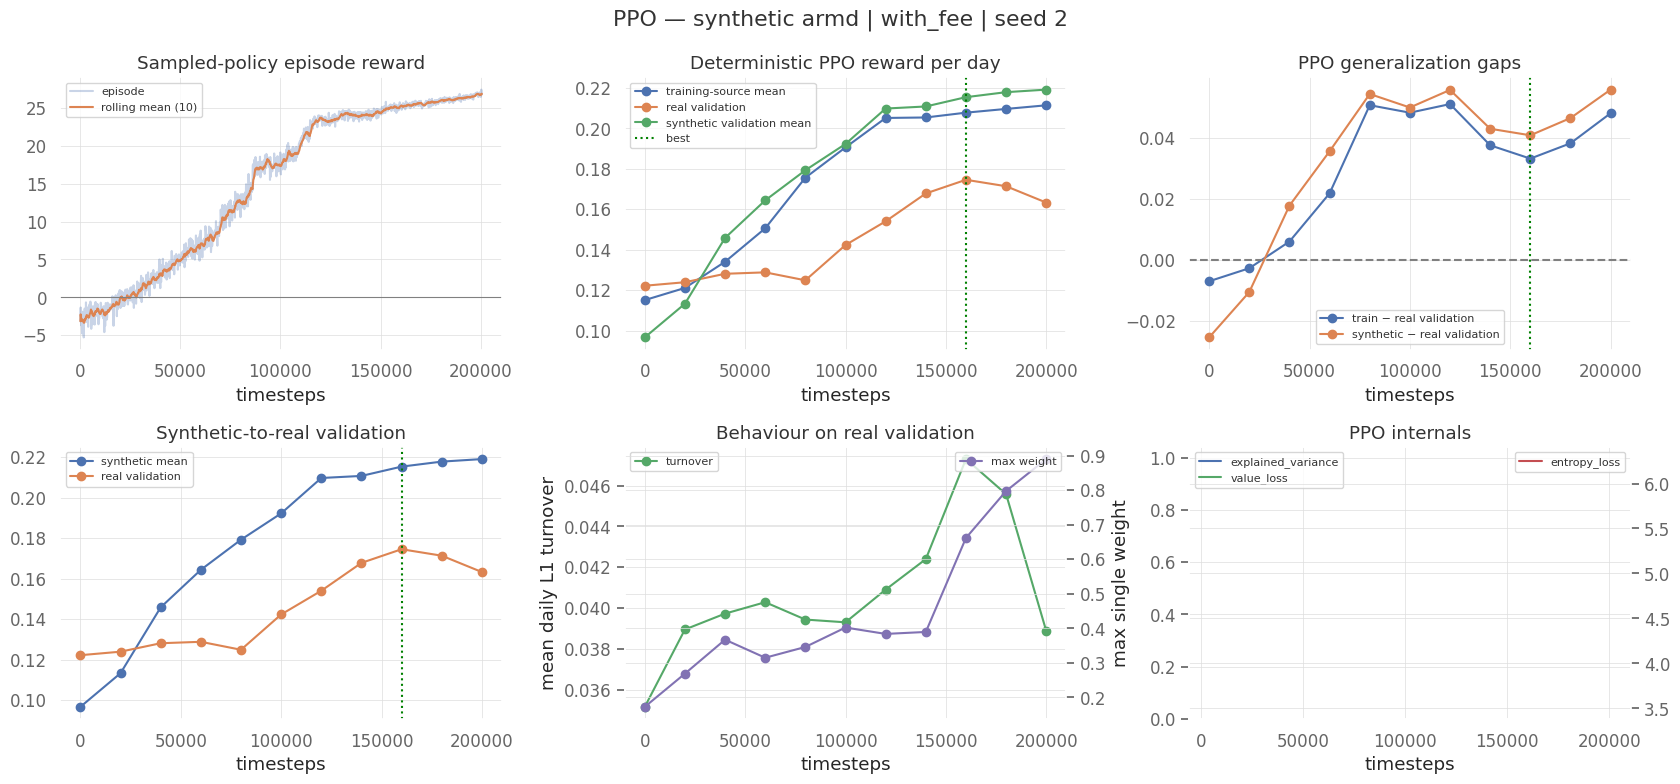

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_armd_30e33431__with_fee__seed_2__18d65a150ac0/learning_curves.png


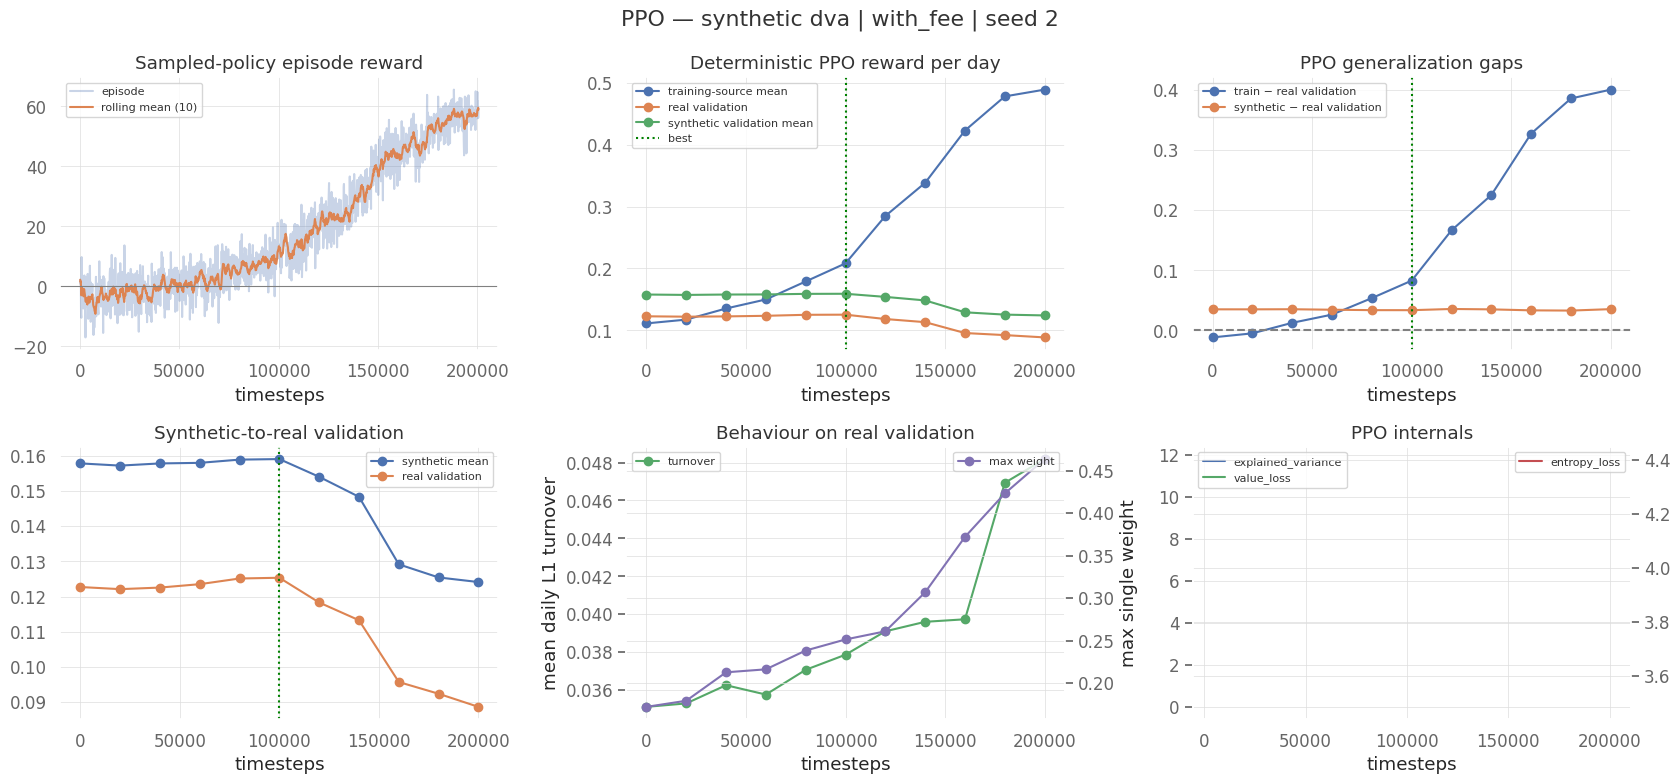

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_c3a3276b__with_fee__seed_2__1fe9e1fef76b/learning_curves.png


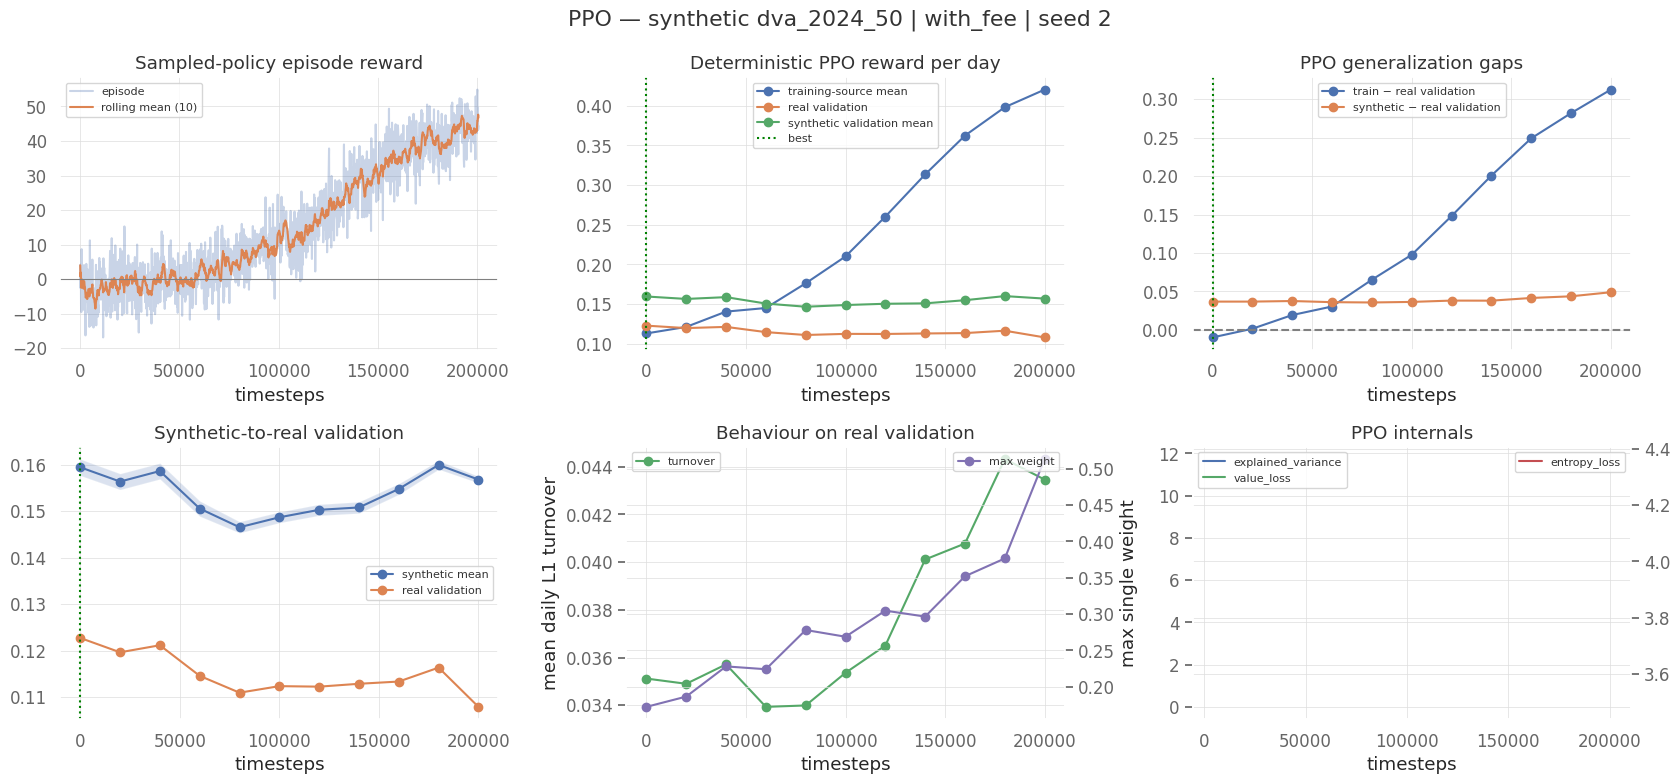

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_dva_2024_50_ca9cca6a__with_fee__seed_2__e496a8d65b2a/learning_curves.png


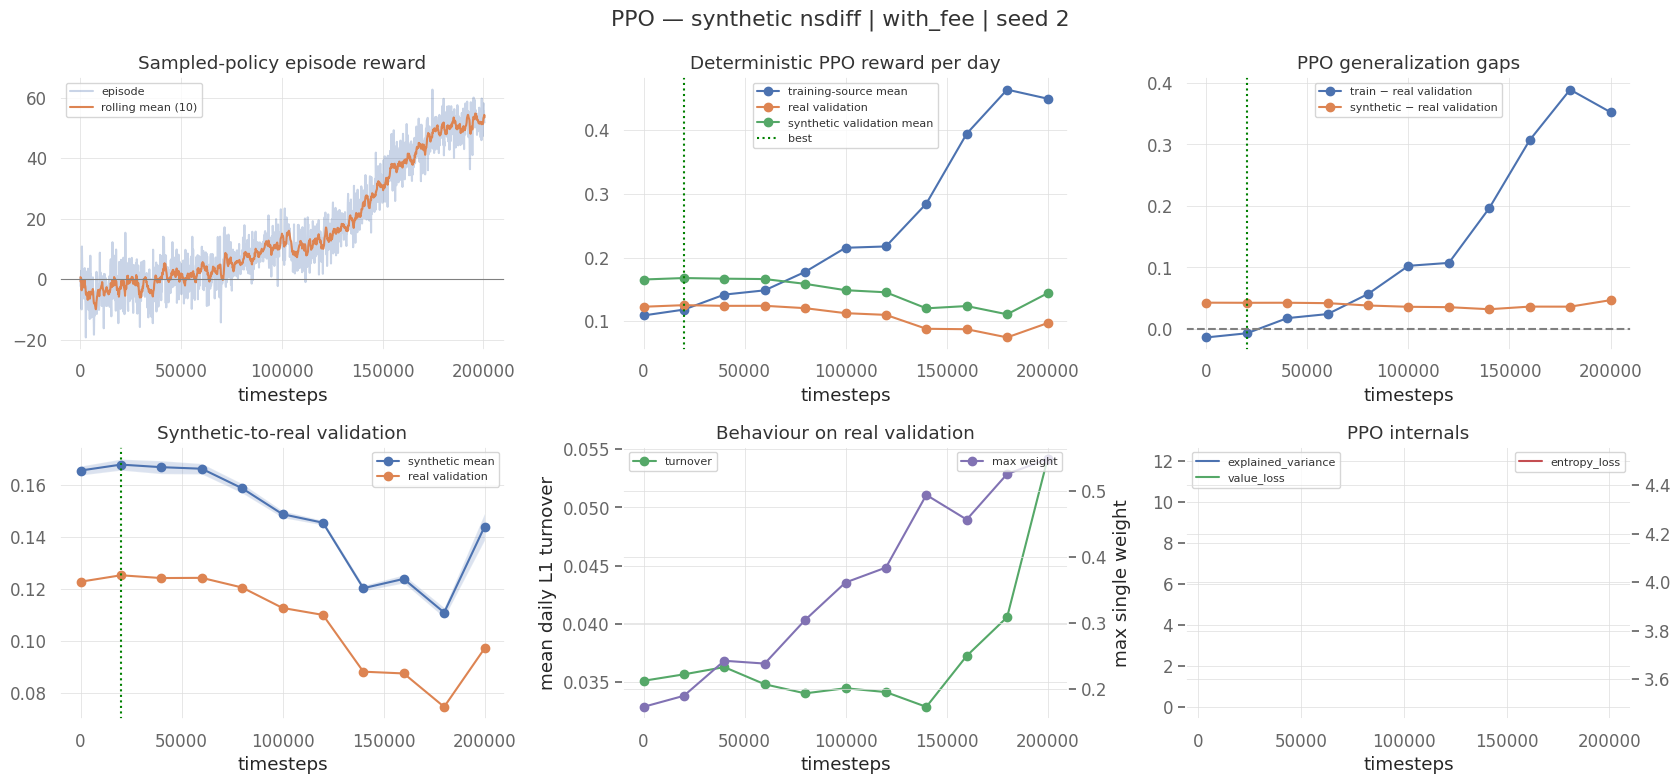

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache/synthetic_nsdiff_210a1b8a__with_fee__seed_2__defe485dfdad/learning_curves.png


In [11]:
GROUP_LABELS = {
    "real_trained": "PPO — real 2024",
    **{
        synthetic_group(name): f"PPO — synthetic {name}"
        for name in SYNTHETIC_MODEL_NAMES
    },
}


def load_run_logs(record: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_dir = Path(record["best_model_path"]).parent
    return (
        pd.read_csv(run_dir / "training_log.csv"),
        pd.read_csv(run_dir / "validation_log.csv"),
    )


def plot_learning_curves(record: dict) -> None:
    train_log, valid_log = load_run_logs(record)
    run_dir = Path(record["best_model_path"]).parent
    label = GROUP_LABELS[record["group"]]
    best_timestep = int(record["best_timestep"])
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))

    axis = axes[0, 0]
    if not train_log.empty:
        axis.plot(
            train_log["timesteps"],
            train_log["episode_reward"],
            alpha=0.3,
            label="episode",
        )
        axis.plot(
            train_log["timesteps"],
            train_log["episode_reward"].rolling(10, min_periods=1).mean(),
            label="rolling mean (10)",
        )
    axis.axhline(0, color="grey", linewidth=0.8)
    axis.set_title("Sampled-policy episode reward")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[0, 1]
    axis.plot(
        valid_log["timesteps"],
        valid_log["train_reward_mean"],
        "o-",
        label="training-source mean",
    )
    axis.plot(
        valid_log["timesteps"],
        valid_log["real_valid_reward"],
        "o-",
        label="real validation",
    )
    if valid_log["synthetic_valid_reward_mean"].notna().any():
        axis.plot(
            valid_log["timesteps"],
            valid_log["synthetic_valid_reward_mean"],
            "o-",
            label="synthetic validation mean",
        )
    axis.axvline(best_timestep, color="green", linestyle=":", label="best")
    axis.set_title("Deterministic PPO reward per day")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[0, 2]
    axis.plot(
        valid_log["timesteps"],
        valid_log["train_reward_mean"] - valid_log["real_valid_reward"],
        "o-",
        label="train − real validation",
    )
    if valid_log["synthetic_valid_reward_mean"].notna().any():
        axis.plot(
            valid_log["timesteps"],
            valid_log["synthetic_valid_reward_mean"]
            - valid_log["real_valid_reward"],
            "o-",
            label="synthetic − real validation",
        )
    axis.axhline(0, color="grey", linestyle="--")
    axis.axvline(best_timestep, color="green", linestyle=":")
    axis.set_title("PPO generalization gaps")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[1, 0]
    if valid_log["synthetic_valid_reward_mean"].notna().any():
        mean = valid_log["synthetic_valid_reward_mean"]
        std = valid_log["synthetic_valid_reward_std"].fillna(0)
        axis.plot(valid_log["timesteps"], mean, "o-", label="synthetic mean")
        axis.fill_between(valid_log["timesteps"], mean - std, mean + std, alpha=0.2)
        axis.plot(
            valid_log["timesteps"],
            valid_log["real_valid_reward"],
            "o-",
            label="real validation",
        )
        axis.set_title("Synthetic-to-real validation")
    else:
        axis.plot(
            valid_log["timesteps"],
            valid_log["real_valid_reward"],
            "o-",
            color="C1",
            label="real validation",
        )
        axis.set_title("Real validation")
    axis.axvline(best_timestep, color="green", linestyle=":")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[1, 1]
    axis.plot(
        valid_log["timesteps"],
        valid_log["real_valid_turnover"],
        "o-",
        color="C2",
        label="turnover",
    )
    axis.set_ylabel("mean daily L1 turnover")
    axis.set_xlabel("timesteps")
    twin = axis.twinx()
    twin.plot(
        valid_log["timesteps"],
        valid_log["real_valid_max_weight"],
        "o-",
        color="C4",
        label="max weight",
    )
    twin.set_ylabel("max single weight")
    axis.set_title("Behaviour on real validation")
    axis.legend(loc="upper left", fontsize=8)
    twin.legend(loc="upper right", fontsize=8)

    axis = axes[1, 2]
    for column, color in [("explained_variance", "C0"), ("value_loss", "C2")]:
        if column in train_log and train_log[column].notna().any():
            axis.plot(train_log["timesteps"], train_log[column], color=color, label=column)
    axis.set_xlabel("timesteps")
    twin = axis.twinx()
    if "entropy_loss" in train_log and train_log["entropy_loss"].notna().any():
        twin.plot(
            train_log["timesteps"],
            train_log["entropy_loss"],
            color="C3",
            label="entropy_loss",
        )
    axis.set_title("PPO internals")
    axis.legend(loc="upper left", fontsize=8)
    twin.legend(loc="upper right", fontsize=8)

    fig.suptitle(
        f"{label} | {record['commission_name']} | seed {record['seed']}"
    )
    fig.tight_layout()
    figure_path = run_dir / "learning_curves.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("saved:", figure_path)


for record in run_records:
    plot_learning_curves(record)


### How to read these

- The deterministic reward panel shows whether training-source reward keeps improving
  while common real-validation reward stalls or falls.
- A widening positive generalization gap is evidence of source-specific overfitting.
- For synthetic runs, divergence between synthetic and real validation suggests a
  distribution mismatch.
- Rising turnover without a real-validation improvement suggests noise trading;
  maximum weight near one indicates concentration in a single asset.
- As in the Demo notebook, sampled-policy episode reward is a training diagnostic,
  not deterministic investment performance.


## 8. Backtest

Following the Demo notebook, this section loads each best validation checkpoint—not
the final model—and evaluates it separately on the common real train, validation,
and test periods. Each period restarts from the initial capital, while the test period
remains continuous within 2025. Every PPO uses its source-fitted scaler. A common
uniform buy-and-hold baseline is evaluated on the same real dates.


In [12]:
REAL_BACKTEST_PERIODS = {
    "train": {"real": "train", "synthetic": "real_train"},
    "validation": {"real": "real_valid", "synthetic": "real_valid"},
    "test": {"real": "real_test", "synthetic": "real_test"},
}

ppo_period_rows = []
benchmark_rows = []
equity_rows = []

for record in run_records:
    group = record["group"]
    model_name = record["model_name"]
    commission_name = record["commission_name"]
    commission = float(record["commission"])
    seed = int(record["seed"])
    model = PPO.load(record["best_model_path"], device=DEVICE)

    for period, keys in REAL_BACKTEST_PERIODS.items():
        period_frame = (
            real_pipeline[keys["real"]]
            if group == "real_trained"
            else synthetic_pipelines[model_name][keys["synthetic"]]
        )
        result = rollout(period_frame, model, env_kwargs(commission), seed)
        ppo_period_rows.append(
            {
                "run_id": record["run_id"],
                "period": period,
                "agent": GROUP_LABELS[group],
                "agent_type": "PPO",
                "group": group,
                "model_name": model_name,
                "commission_name": commission_name,
                "commission": commission,
                "seed": seed,
                "best_timestep": int(record["best_timestep"]),
                **performance_metrics(result),
            }
        )
        normalized_values = result["values"] / result["values"][0]
        for date, value in zip(result["dates"], normalized_values):
            equity_rows.append(
                {
                    "date": pd.Timestamp(date),
                    "period": period,
                    "agent": GROUP_LABELS[group],
                    "agent_type": "PPO",
                    "group": group,
                    "model_name": model_name,
                    "commission_name": commission_name,
                    "seed": seed,
                    "growth_of_one": float(value),
                }
            )

# Buy-and-hold is deterministic, so evaluate it once per period and fee.
for period, keys in REAL_BACKTEST_PERIODS.items():
    for commission_name, commission in COMMISSION_CONFIGS.items():
        result = rollout(
            real_pipeline[keys["real"]],
            model=None,
            kwargs=env_kwargs(commission),
            seed=SEEDS[0],
        )
        benchmark_rows.append(
            {
                "run_id": f"buy_and_hold__{period}__{commission_name}",
                "period": period,
                "agent": "Buy & Hold",
                "agent_type": "Buy & Hold",
                "group": "buy_and_hold",
                "model_name": None,
                "commission_name": commission_name,
                "commission": commission,
                "seed": pd.NA,
                "best_timestep": np.nan,
                **performance_metrics(result),
            }
        )
        normalized_values = result["values"] / result["values"][0]
        for date, value in zip(result["dates"], normalized_values):
            equity_rows.append(
                {
                    "date": pd.Timestamp(date),
                    "period": period,
                    "agent": "Buy & Hold",
                    "agent_type": "Buy & Hold",
                    "group": "buy_and_hold",
                    "model_name": None,
                    "commission_name": commission_name,
                    "seed": pd.NA,
                    "growth_of_one": float(value),
                }
            )

ppo_period_results = pd.DataFrame(ppo_period_rows)
test_results = ppo_period_results.loc[
    ppo_period_results["period"] == "test"
].reset_index(drop=True)
benchmark_results = pd.DataFrame(benchmark_rows)
backtest_results = pd.concat(
    [ppo_period_results, benchmark_results], ignore_index=True
)
equity_curves = pd.DataFrame(equity_rows)
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
ppo_period_results.to_csv(
    EXPERIMENT_ROOT / "ppo_period_metrics.csv", index=False
)
test_results.to_csv(EXPERIMENT_ROOT / "test_metrics.csv", index=False)
benchmark_results.to_csv(
    EXPERIMENT_ROOT / "buy_and_hold_metrics.csv", index=False
)
backtest_results.to_csv(
    EXPERIMENT_ROOT / "backtest_results.csv", index=False
)
equity_curves.to_csv(EXPERIMENT_ROOT / "equity_curves.csv", index=False)

# PPO-only data: show each training source separately across all periods.
PPO_RESULT_COLUMNS = [
    "period",
    "commission_name",
    "seed",
    "best_timestep",
    "cumulative_return",
    "cagr",
    "sharpe",
    "annualized_volatility",
    "max_drawdown",
    "turnover",
]
for group in TRAINING_GROUPS:
    print(GROUP_LABELS[group])
    period_table = ppo_period_results.loc[
        ppo_period_results["group"] == group, PPO_RESULT_COLUMNS
    ].copy()
    period_table["period"] = pd.Categorical(
        period_table["period"],
        categories=list(REAL_BACKTEST_PERIODS),
        ordered=True,
    )
    display(
        period_table.sort_values(
            ["period", "commission_name", "seed"]
        ).reset_index(drop=True)
    )


PPO — real 2024


,period,commission_name,seed,best_timestep,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover
0,train,no_fee,0,100000,0.374619,0.787859,2.528372,0.241505,-0.154283,0.036778
1,train,no_fee,1,160000,1.005265,2.562803,3.756394,0.355573,-0.168602,0.088998
2,train,no_fee,2,140000,0.350307,0.730537,2.550380,0.225142,-0.151625,0.040494
3,train,with_fee,0,180000,1.187390,3.175753,4.577910,0.324317,-0.125620,0.120566
4,train,with_fee,1,0,0.169814,0.331641,1.560930,0.195826,-0.146432,0.022516
5,train,with_fee,2,60000,0.232730,0.465321,1.964820,0.205277,-0.149883,0.028318
6,validation,no_fee,0,100000,0.092078,0.414566,2.249403,0.159904,-0.034301,0.042139
7,validation,no_fee,1,160000,0.109213,0.503997,2.419157,0.175081,-0.039674,0.081698
8,validation,no_fee,2,140000,0.087941,0.393584,2.071905,0.166933,-0.033532,0.043678
9,validation,with_fee,0,180000,0.112095,0.519439,2.386250,0.182293,-0.043824,0.132921


PPO — synthetic armd


,period,commission_name,seed,best_timestep,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover
0,train,no_fee,0,180000,0.293775,0.600531,1.275084,0.447099,-0.230499,0.027981
1,train,no_fee,1,200000,0.201275,0.397764,1.187131,0.327462,-0.186773,0.036322
2,train,no_fee,2,140000,0.248131,0.498923,1.280805,0.369180,-0.211136,0.030634
3,train,with_fee,0,200000,0.062751,0.117548,0.551653,0.265526,-0.190806,0.016378
4,train,with_fee,1,200000,0.068923,0.129428,0.628312,0.239212,-0.178018,0.030382
5,train,with_fee,2,160000,0.294239,0.601578,1.302158,0.433877,-0.219081,0.027514
6,validation,no_fee,0,180000,0.122846,0.578103,1.755530,0.282500,-0.066358,0.042633
7,validation,no_fee,1,200000,0.155384,0.765978,2.464426,0.242833,-0.048526,0.053077
8,validation,no_fee,2,140000,0.111633,0.516955,1.778781,0.252065,-0.056433,0.043989
9,validation,with_fee,0,200000,0.168707,0.847530,2.318523,0.281927,-0.075386,0.033250


PPO — synthetic dva


,period,commission_name,seed,best_timestep,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover
0,train,no_fee,0,160000,0.719570,1.690898,3.146781,0.332486,-0.169403,0.067473
1,train,no_fee,1,140000,0.836993,2.035870,3.673615,0.316327,-0.154128,0.078938
2,train,no_fee,2,0,0.177248,0.347135,1.605742,0.197816,-0.146431,0.022577
3,train,with_fee,0,100000,0.559443,1.251019,2.869908,0.298483,-0.156123,0.064695
4,train,with_fee,1,0,0.169808,0.331628,1.560955,0.195816,-0.146424,0.022517
5,train,with_fee,2,100000,0.339531,0.705403,2.608798,0.213499,-0.131065,0.037837
6,validation,no_fee,0,160000,0.091695,0.412615,2.378695,0.149998,-0.032071,0.055327
7,validation,no_fee,1,140000,0.103760,0.475093,2.525973,0.158937,-0.036147,0.068352
8,validation,no_fee,2,0,0.083064,0.369150,1.988194,0.164880,-0.033439,0.035120
9,validation,with_fee,0,100000,0.092554,0.416995,2.267902,0.159306,-0.033533,0.058774


PPO — synthetic dva_2024_50


,period,commission_name,seed,best_timestep,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover
0,train,no_fee,0,100000,0.427037,0.914310,2.582580,0.265268,-0.155926,0.041370
1,train,no_fee,1,160000,0.731815,1.725991,2.711330,0.399594,-0.177596,0.071892
2,train,no_fee,2,0,0.177230,0.347097,1.605618,0.197814,-0.146432,0.022576
3,train,with_fee,0,160000,0.958584,2.412809,3.824985,0.336172,-0.144784,0.098734
4,train,with_fee,1,0,0.169816,0.331645,1.561052,0.195811,-0.146426,0.022517
5,train,with_fee,2,0,0.173523,0.339362,1.576637,0.197790,-0.146795,0.022576
6,validation,no_fee,0,100000,0.100214,0.456518,2.435888,0.159665,-0.031543,0.045760
7,validation,no_fee,1,160000,0.101118,0.461240,2.287708,0.172314,-0.041420,0.078680
8,validation,no_fee,2,0,0.083067,0.369165,1.988246,0.164881,-0.033442,0.035119
9,validation,with_fee,0,160000,0.087699,0.392364,2.128416,0.161662,-0.036546,0.094789


PPO — synthetic nsdiff


,period,commission_name,seed,best_timestep,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover
0,train,no_fee,0,40000,0.217206,0.431800,1.871782,0.202831,-0.145557,0.025358
1,train,no_fee,1,120000,0.588974,1.329469,3.577749,0.245037,-0.136150,0.059305
2,train,no_fee,2,0,0.177254,0.347147,1.605778,0.197817,-0.146431,0.022577
3,train,with_fee,0,180000,1.119984,2.943770,5.042093,0.280485,-0.077188,0.128096
4,train,with_fee,1,120000,0.722220,1.698476,3.780579,0.272757,-0.135869,0.075281
5,train,with_fee,2,20000,0.188353,0.370431,1.625929,0.207061,-0.149059,0.024330
6,validation,no_fee,0,40000,0.088698,0.397406,2.167680,0.160326,-0.034241,0.036032
7,validation,no_fee,1,120000,0.097536,0.442608,2.416464,0.156773,-0.033951,0.054926
8,validation,no_fee,2,0,0.083067,0.369164,1.988261,0.164880,-0.033437,0.035121
9,validation,with_fee,0,180000,0.106626,0.490228,2.691306,0.152601,-0.035381,0.124692


### Aggregate backtest tables

PPO-only aggregate results and paired deltas are displayed one training source at a
time. Formal aggregate and paired-delta conclusions still use only the untouched test
period. The final test table includes every PPO source and buy-and-hold together. With
only three full-mode seeds, do not interpret the output as a significance test.


In [13]:
METRIC_COLUMNS = [
    "cumulative_return",
    "cagr",
    "sharpe",
    "annualized_volatility",
    "max_drawdown",
    "turnover",
    "best_timestep",
]

aggregate_summary = test_results.groupby(
    ["commission_name", "group"]
)[METRIC_COLUMNS].agg(["mean", "std"])
aggregate_summary.columns = [
    f"{metric}_{stat}" for metric, stat in aggregate_summary.columns
]
aggregate_summary = aggregate_summary.reset_index()
aggregate_summary["agent"] = aggregate_summary["group"].map(GROUP_LABELS)
aggregate_summary.to_csv(
    EXPERIMENT_ROOT / "aggregate_summary.csv", index=False
)

paired_rows = []
for commission_name in COMMISSION_CONFIGS:
    subset = test_results[
        test_results["commission_name"] == commission_name
    ]
    for seed in SEEDS:
        pair = subset[subset["seed"] == seed].set_index("group")
        if "real_trained" not in pair.index:
            continue
        for model_name in SYNTHETIC_MODEL_NAMES:
            group = synthetic_group(model_name)
            if group not in pair.index:
                continue
            row = {
                "commission_name": commission_name,
                "seed": seed,
                "model_name": model_name,
                "synthetic_group": group,
            }
            for metric in METRIC_COLUMNS:
                row[f"delta_{metric}"] = float(
                    pair.loc[group, metric]
                    - pair.loc["real_trained", metric]
                )
            paired_rows.append(row)

paired_deltas = pd.DataFrame(paired_rows)
paired_deltas.to_csv(EXPERIMENT_ROOT / "paired_deltas.csv", index=False)

# PPO-only data: keep each source in its own table.
for group in TRAINING_GROUPS:
    print(GROUP_LABELS[group])
    display(
        aggregate_summary.loc[aggregate_summary["group"] == group]
        .drop(columns=["group", "agent"])
        .reset_index(drop=True)
    )

for model_name in SYNTHETIC_MODEL_NAMES:
    print(f"Paired delta: synthetic {model_name} − real-trained PPO")
    display(
        paired_deltas.loc[paired_deltas["model_name"] == model_name]
        .reset_index(drop=True)
    )

# Comparison data: all PPO models and buy-and-hold appear together.
COMPARISON_METRICS = [metric for metric in METRIC_COLUMNS if metric != "best_timestep"]
ppo_comparison = aggregate_summary[
    ["commission_name", "agent"]
    + [
        f"{metric}_{stat}"
        for metric in COMPARISON_METRICS
        for stat in ["mean", "std"]
    ]
].copy()

benchmark_comparison_rows = []
test_benchmark_results = benchmark_results.loc[
    benchmark_results["period"] == "test"
]
for _, row in test_benchmark_results.iterrows():
    output = {
        "commission_name": row["commission_name"],
        "agent": row["agent"],
    }
    for metric in COMPARISON_METRICS:
        output[f"{metric}_mean"] = row[metric]
        output[f"{metric}_std"] = np.nan
    benchmark_comparison_rows.append(output)

comparison_summary = pd.concat(
    [ppo_comparison, pd.DataFrame(benchmark_comparison_rows)],
    ignore_index=True,
)
comparison_summary.to_csv(
    EXPERIMENT_ROOT / "ppo_vs_buy_and_hold_summary.csv", index=False
)
for commission_name in COMMISSION_CONFIGS:
    print(f"All PPO models vs Buy & Hold — {commission_name}")
    display(
        comparison_summary.loc[
            comparison_summary["commission_name"] == commission_name
        ].reset_index(drop=True)
    )


PPO — real 2024


,commission_name,cumulative_return_mean,cumulative_return_std,cagr_mean,cagr_std,sharpe_mean,sharpe_std,annualized_volatility_mean,annualized_volatility_std,max_drawdown_mean,max_drawdown_std,turnover_mean,turnover_std,best_timestep_mean,best_timestep_std
0,no_fee,0.236700,0.024568,0.238805,0.024806,0.893031,0.153148,0.301675,0.087597,-0.259194,0.056250,0.036641,0.018502,133333.333333,30550.504633
1,with_fee,0.197237,0.051080,0.198968,0.051558,0.838002,0.260694,0.282462,0.079242,-0.254991,0.048189,0.046238,0.047410,80000.000000,91651.513899


PPO — synthetic armd


,commission_name,cumulative_return_mean,cumulative_return_std,cagr_mean,cagr_std,sharpe_mean,sharpe_std,annualized_volatility_mean,annualized_volatility_std,max_drawdown_mean,max_drawdown_std,turnover_mean,turnover_std,best_timestep_mean,best_timestep_std
0,no_fee,0.310322,0.030264,0.313160,0.030574,0.978313,0.012123,0.335551,0.032318,-0.282621,0.018286,0.023123,0.003639,173333.333333,30550.504633
1,with_fee,0.198321,0.130175,0.200094,0.131408,0.740546,0.338910,0.306468,0.038555,-0.275348,0.022488,0.019930,0.008239,186666.666667,23094.010768


PPO — synthetic dva


...

,commission_name,seed,model_name,synthetic_group,delta_cumulative_return,delta_cagr,delta_sharpe,delta_annualized_volatility,delta_max_drawdown,delta_turnover,delta_best_timestep
0,no_fee,0,nsdiff,synthetic::nsdiff,-0.019369,-0.019558,-0.007851,-0.016911,0.008064,-0.005434,-60000.0
1,no_fee,1,nsdiff,synthetic::nsdiff,0.034266,0.034604,0.307747,-0.134721,0.103602,-0.016734,-40000.0
2,no_fee,2,nsdiff,synthetic::nsdiff,0.030211,0.030502,0.178571,-0.025393,0.002597,-0.011105,-140000.0
3,with_fee,0,nsdiff,synthetic::nsdiff,0.041969,0.042354,0.160454,-0.067229,0.085386,0.009552,0.0
4,with_fee,1,nsdiff,synthetic::nsdiff,-0.050867,-0.051349,-0.296719,0.053785,-0.024832,0.039073,120000.0
5,with_fee,2,nsdiff,synthetic::nsdiff,-0.001711,-0.001727,0.016100,-0.007352,0.001222,-0.003850,-40000.0


All PPO models vs Buy & Hold — no_fee


,commission_name,agent,cumulative_return_mean,cumulative_return_std,cagr_mean,cagr_std,sharpe_mean,sharpe_std,annualized_volatility_mean,annualized_volatility_std,max_drawdown_mean,max_drawdown_std,turnover_mean,turnover_std
0,no_fee,PPO — real 2024,0.236700,0.024568,0.238805,0.024806,0.893031,0.153148,0.301675,0.087597,-0.259194,0.056250,0.036641,0.018502
1,no_fee,PPO — synthetic armd,0.310322,0.030264,0.313160,0.030574,0.978313,0.012123,0.335551,0.032318,-0.282621,0.018286,0.023123,0.003639
2,no_fee,PPO — synthetic dva,0.262953,0.027657,0.265316,0.027931,0.971956,0.109762,0.288963,0.054638,-0.239010,0.026673,0.038403,0.019029
3,no_fee,PPO — synthetic dva_2024_50,0.249539,0.019322,0.251769,0.019512,0.942081,0.120365,0.293096,0.085116,-0.255923,0.047524,0.028805,0.013446
4,no_fee,PPO — synthetic nsdiff,0.251736,0.023128,0.253987,0.023356,1.052520,0.006000,0.242667,0.021945,-0.221106,0.002363,0.025550,0.013560
5,no_fee,Buy & Hold,0.283046,NaN,0.285607,NaN,1.054186,NaN,0.273240,NaN,-0.261542,NaN,0.018132,NaN


All PPO models vs Buy & Hold — with_fee


,commission_name,agent,cumulative_return_mean,cumulative_return_std,cagr_mean,cagr_std,sharpe_mean,sharpe_std,annualized_volatility_mean,annualized_volatility_std,max_drawdown_mean,max_drawdown_std,turnover_mean,turnover_std
0,with_fee,PPO — real 2024,0.197237,0.051080,0.198968,0.051558,0.838002,0.260694,0.282462,0.079242,-0.254991,0.048189,0.046238,0.047410
1,with_fee,PPO — synthetic armd,0.198321,0.130175,0.200094,0.131408,0.740546,0.338910,0.306468,0.038555,-0.275348,0.022488,0.019930,0.008239
2,with_fee,PPO — synthetic dva,0.245357,0.018666,0.247546,0.018849,0.994981,0.070791,0.258101,0.045785,-0.226685,0.010775,0.031459,0.019356
3,with_fee,PPO — synthetic dva_2024_50,0.216638,0.023451,0.218550,0.023675,0.908219,0.202218,0.269961,0.071086,-0.242848,0.032599,0.038205,0.037261
4,with_fee,PPO — synthetic nsdiff,0.193701,0.026637,0.195394,0.026890,0.797947,0.152439,0.275530,0.034339,-0.234399,0.012098,0.061163,0.046824
5,with_fee,Buy & Hold,0.274938,NaN,0.277418,NaN,1.030812,NaN,0.273230,NaN,-0.262938,NaN,0.018132,NaN


## 9. Plots

As in the Demo notebook, train, validation, and test are plotted separately. Within
each real-data period, the two commission panels overlay every PPO training source
with buy-and-hold. Shaded bands show ±1 standard deviation across PPO seeds;
buy-and-hold is deterministic and therefore has no band.


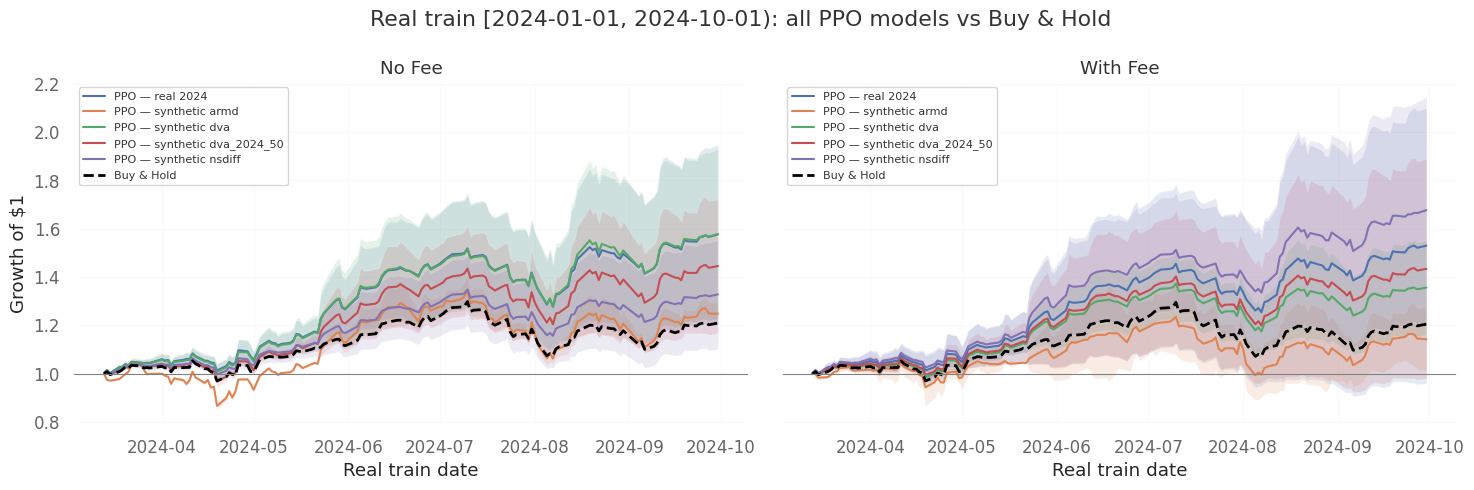

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/full/781e1b547281/ppo_vs_buy_and_hold_train_equity_curves.png


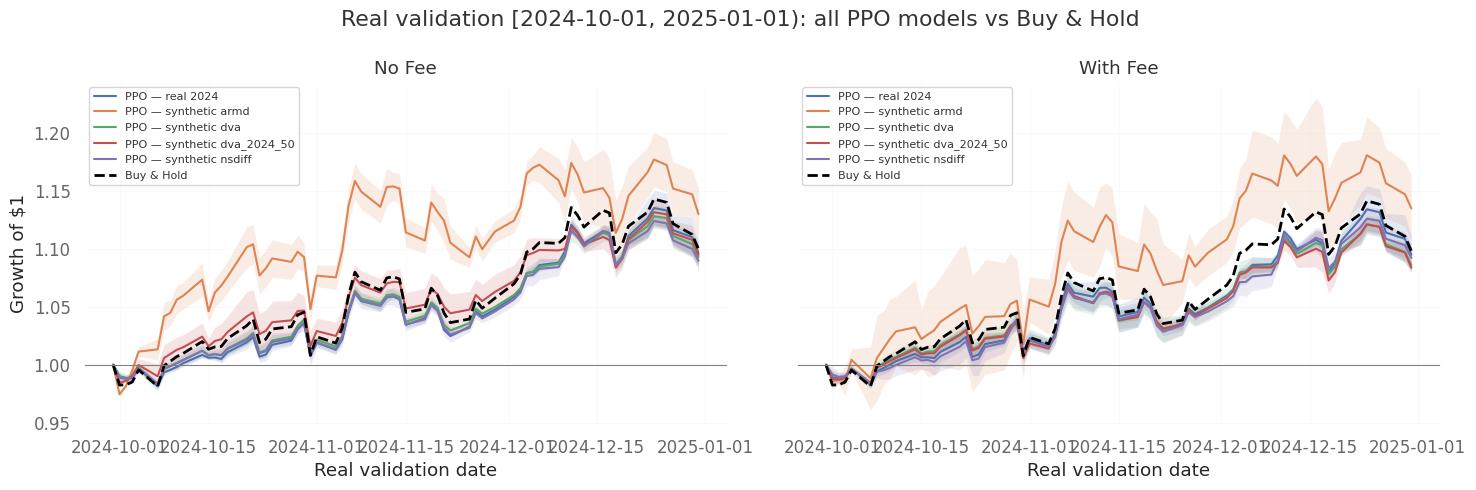

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/full/781e1b547281/ppo_vs_buy_and_hold_validation_equity_curves.png


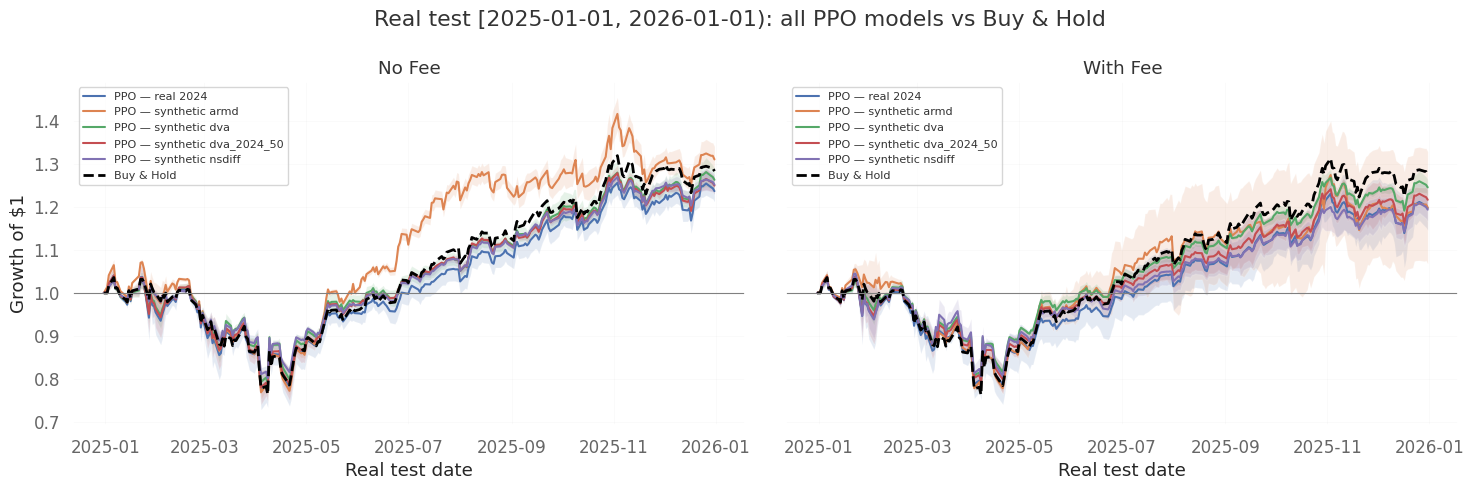

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/full/781e1b547281/ppo_vs_buy_and_hold_test_equity_curves.png


In [14]:
PERIOD_TITLES = {
    "train": f"Real train [{TRAIN_START}, {TRAIN_END})",
    "validation": f"Real validation [{VAL_START}, {VAL_END})",
    "test": f"Real test [{TEST_START}, {TEST_END})",
}
figure_paths = {}

for period in REAL_BACKTEST_PERIODS:
    fig, axes = plt.subplots(
        1,
        len(COMMISSION_CONFIGS),
        figsize=(15, 5),
        sharey=True,
        squeeze=False,
    )
    for axis, commission_name in zip(axes.ravel(), COMMISSION_CONFIGS):
        subset = equity_curves.loc[
            (equity_curves["period"] == period)
            & (equity_curves["commission_name"] == commission_name)
        ]
        for group, label in GROUP_LABELS.items():
            group_data = subset[subset["group"] == group].copy()
            group_data["seed"] = pd.to_numeric(group_data["seed"])
            pivot = group_data.pivot(
                index="date", columns="seed", values="growth_of_one"
            ).sort_index()
            mean = pivot.mean(axis=1)
            std = pivot.std(axis=1).fillna(0)
            axis.plot(mean.index, mean, label=label)
            axis.fill_between(
                mean.index,
                mean - std,
                mean + std,
                alpha=0.15,
            )
        benchmark = (
            subset.loc[subset["group"] == "buy_and_hold"]
            .sort_values("date")
        )
        axis.plot(
            benchmark["date"],
            benchmark["growth_of_one"],
            color="black",
            linestyle="--",
            linewidth=2,
            label="Buy & Hold",
        )
        axis.axhline(1.0, color="grey", linewidth=0.8)
        axis.set_title(commission_name.replace("_", " ").title())
        axis.set_xlabel(f"Real {period} date")
        axis.grid(alpha=0.2)
        axis.legend(fontsize=8)

    axes.ravel()[0].set_ylabel("Growth of $1")
    fig.suptitle(f"{PERIOD_TITLES[period]}: all PPO models vs Buy & Hold")
    fig.tight_layout()
    figure_path = (
        EXPERIMENT_ROOT / f"ppo_vs_buy_and_hold_{period}_equity_curves.png"
    )
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    figure_paths[period] = figure_path
    plt.show()
    print("saved:", figure_path)


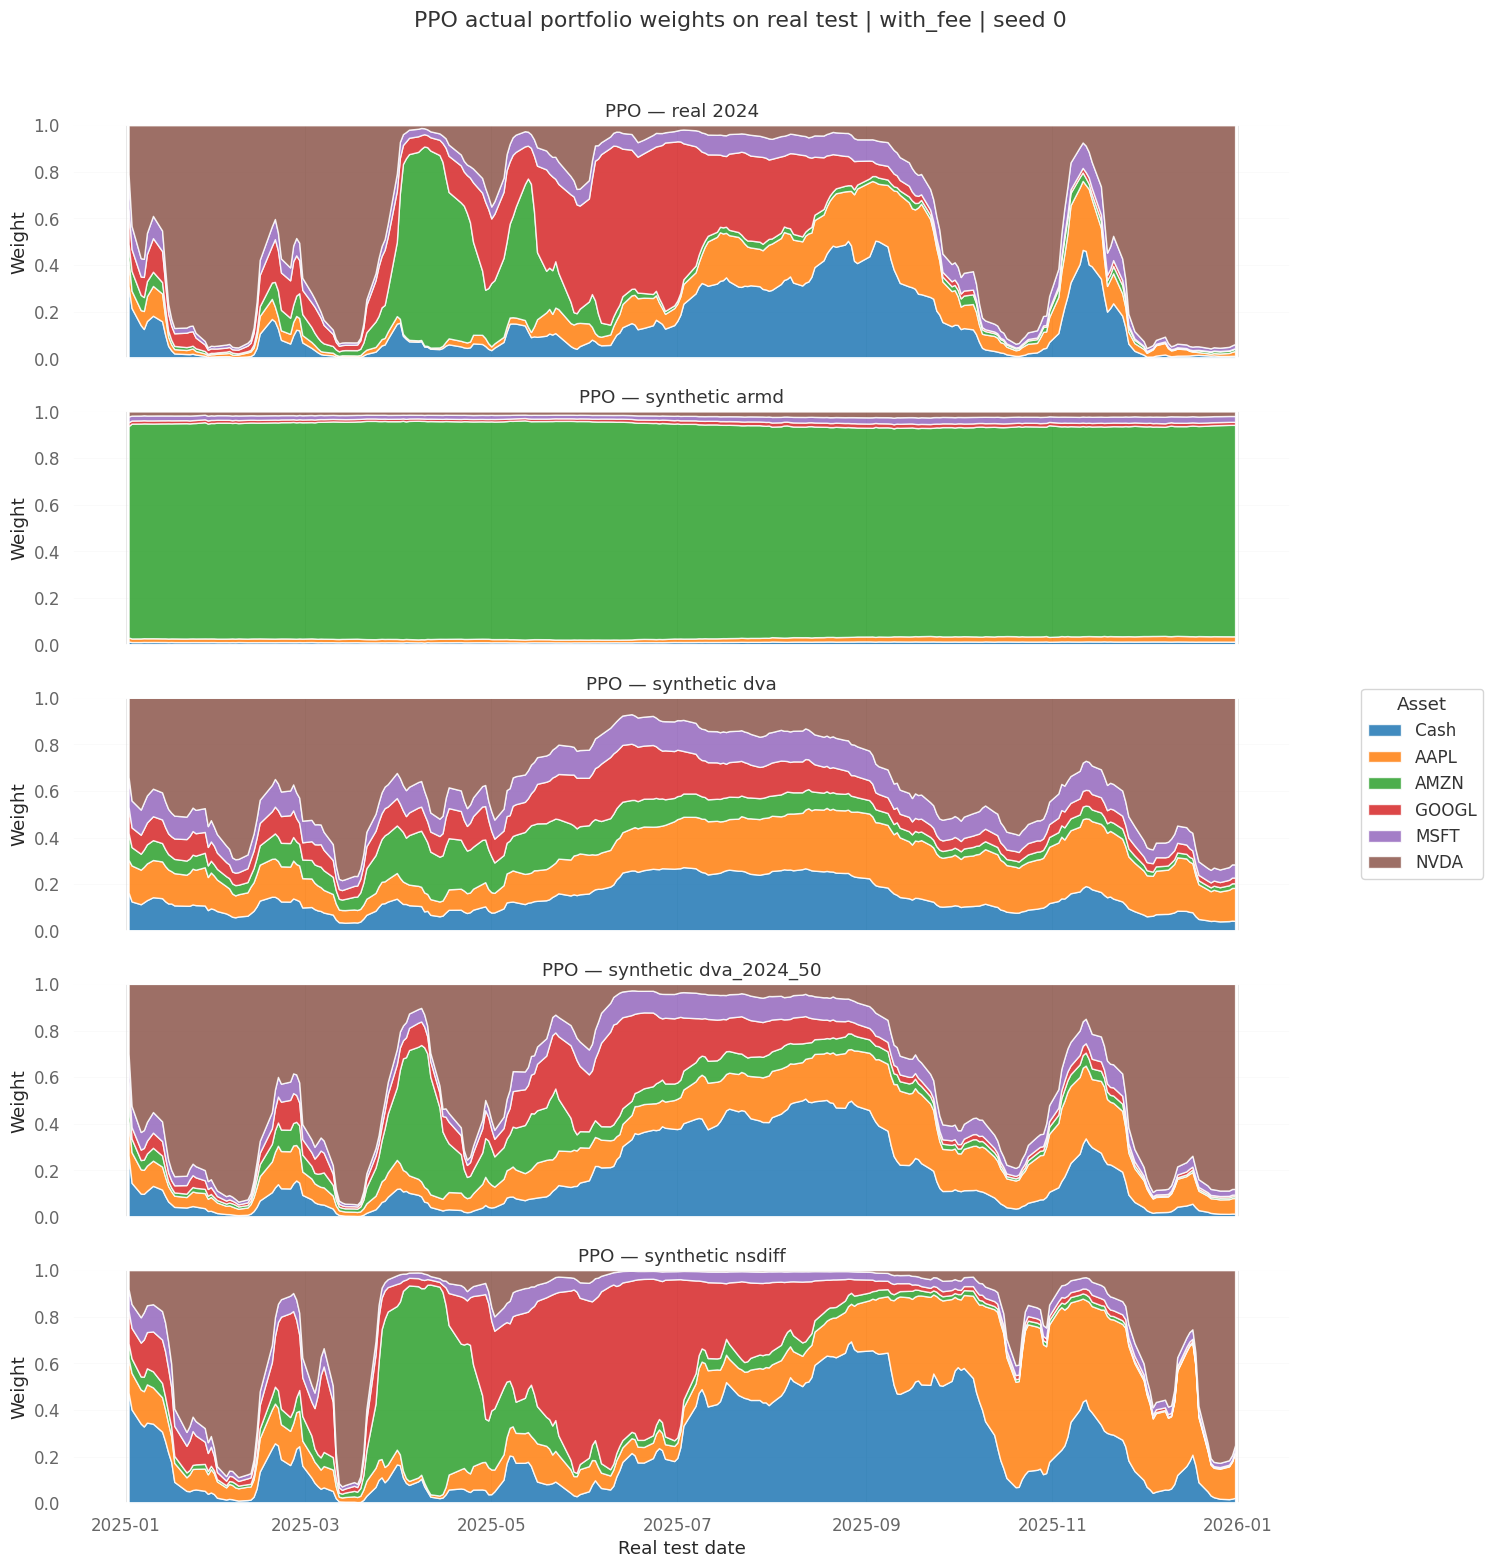

saved: /home/cwei1213/FinRL_Exp/results/ppo_synthetic_vs_real/full/781e1b547281/ppo_real_test_portfolio_weights_with_fee_seed_0.png


In [15]:
# Compare actual end-of-day weights for every PPO training source on real test data.
WEIGHT_COMMISSION_NAME = "with_fee"
WEIGHT_SEED = SEEDS[0]
if WEIGHT_COMMISSION_NAME not in COMMISSION_CONFIGS:
    raise ValueError(f"Unknown commission setting: {WEIGHT_COMMISSION_NAME}")
if WEIGHT_SEED not in SEEDS:
    raise ValueError(f"WEIGHT_SEED must be one of {SEEDS}")

weight_colors = plt.get_cmap("tab10").colors[: len(EXPECTED_TICKERS) + 1]
fig, axes = plt.subplots(
    len(TRAINING_GROUPS),
    1,
    figsize=(15, max(4, 3.2 * len(TRAINING_GROUPS))),
    sharex=True,
    sharey=True,
    squeeze=False,
)

weight_labels = None
for axis, group in zip(axes.ravel(), TRAINING_GROUPS):
    record = next(
        (
            item
            for item in run_records
            if item["group"] == group
            and item["commission_name"] == WEIGHT_COMMISSION_NAME
            and int(item["seed"]) == WEIGHT_SEED
        ),
        None,
    )
    if record is None:
        raise RuntimeError(
            f"No completed run for {group}, {WEIGHT_COMMISSION_NAME}, seed {WEIGHT_SEED}"
        )

    model_name = model_from_group(group)
    test_frame = (
        real_pipeline["real_test"]
        if group == "real_trained"
        else synthetic_pipelines[model_name]["real_test"]
    )
    model = PPO.load(record["best_model_path"], device=DEVICE)
    environment = PortfolioOptimizationGymnasiumEnv(
        test_frame,
        **env_kwargs(float(record["commission"])),
    )
    observation, _ = environment.reset(seed=WEIGHT_SEED)
    done = False
    while not done:
        action, _ = model.predict(observation, deterministic=True)
        observation, _, terminated, truncated, _ = environment.step(action)
        done = terminated or truncated

    weight_dates = pd.to_datetime(environment._date_memory[1:])
    actual_weights = np.asarray(environment._final_weights[1:], dtype=float)
    labels = ["Cash", *environment._tic_list.tolist()]
    if weight_labels is None:
        weight_labels = labels
    elif labels != weight_labels:
        raise ValueError(f"Asset order differs across training groups: {labels}")
    if not np.allclose(actual_weights.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError(f"Portfolio weights do not sum to one for {group}")

    axis.stackplot(
        weight_dates,
        actual_weights.T,
        labels=labels,
        colors=weight_colors,
        alpha=0.85,
    )
    axis.set_title(GROUP_LABELS[group])
    axis.set_ylabel("Weight")
    axis.set_ylim(0, 1)
    axis.grid(axis="y", alpha=0.2)

axes.ravel()[-1].set_xlabel("Real test date")
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Asset", loc="center right")
fig.suptitle(
    "PPO actual portfolio weights on real test "
    f"| {WEIGHT_COMMISSION_NAME} | seed {WEIGHT_SEED}"
)
fig.tight_layout(rect=(0, 0, 0.88, 0.96))
weight_figure_path = EXPERIMENT_ROOT / (
    f"ppo_real_test_portfolio_weights_{WEIGHT_COMMISSION_NAME}_seed_{WEIGHT_SEED}.png"
)
fig.savefig(weight_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("saved:", weight_figure_path)

## 10. Interpretation checklist

Before claiming that a generation model helps:

- Compare each model's paired delta against the real control for the same seed and fee.
- Require the advantage to appear across seeds, not only in the mean.
- Check whether return improvements come with worse drawdown or turnover.
- Compare each model's synthetic-validation and real-validation curves for
  distribution mismatch.
- Treat smoke-mode numbers only as an execution check.

A positive synthetic-validation score alone is not evidence of real-market transfer;
the common real test is the controlling result.


## Next steps

- Keep one adjusted OHLCV CSV per ticker under `data/real/`.
- Add real 2025 rows before running the configured test period.
- Put each generation model under
  `data/synthetic/<model_name>/path_*.csv`.
- Run once in smoke mode and review model discovery, data, and scaling summaries.
- Confirm repeated runs report `training cache hit`; use
  `FINRL_FORCE_RETRAIN=1` only when a deliberate rebuild is required.
- Set `RUN_MODE="full"` and execute all cells for the formal comparison.
